=== Launching finetune ===
Running: finetune
CWD: /users/eleves-b/2023/benjamin.wilhelm/side-tuning
PYTHON: /users/eleves-b/2023/benjamin.wilhelm/side-tuning/.venv/bin/python
CMD: /users/eleves-b/2023/benjamin.wilhelm/side-tuning/.venv/bin/python -m scripts.train_lifelong /users/eleves-b/2023/benjamin.wilhelm/side-tuning/runs/finetune train with cifar_hp icifar_data model_lifelong_finetune_cifar cfg.training.dataloader_fn_kwargs.data_path=/users/eleves-b/2023/benjamin.wilhelm/datasets cfg.learner.model_kwargs.base_kwargs.base_weights_path=/users/eleves-b/2023/benjamin.wilhelm/side-tuning/assets/pytorch/resnet44-cifar.pth cfg.learner.model_kwargs.base_kwargs.side_weights_path=/users/eleves-b/2023/benjamin.wilhelm/side-tuning/assets/pytorch/distillation/fcn4-cifar.pth 

RETURN CODE: 0

STDOUT:
 Using GPU 0
training for 10 epochs
Setting grad True for task 0 and others False. 
	 Alphas: [-1, -1, -1, -1, -1, -1, -1, -1, -1, -1]
Setting grad True for task 1 and others False. 
	 Alphas: [-1,

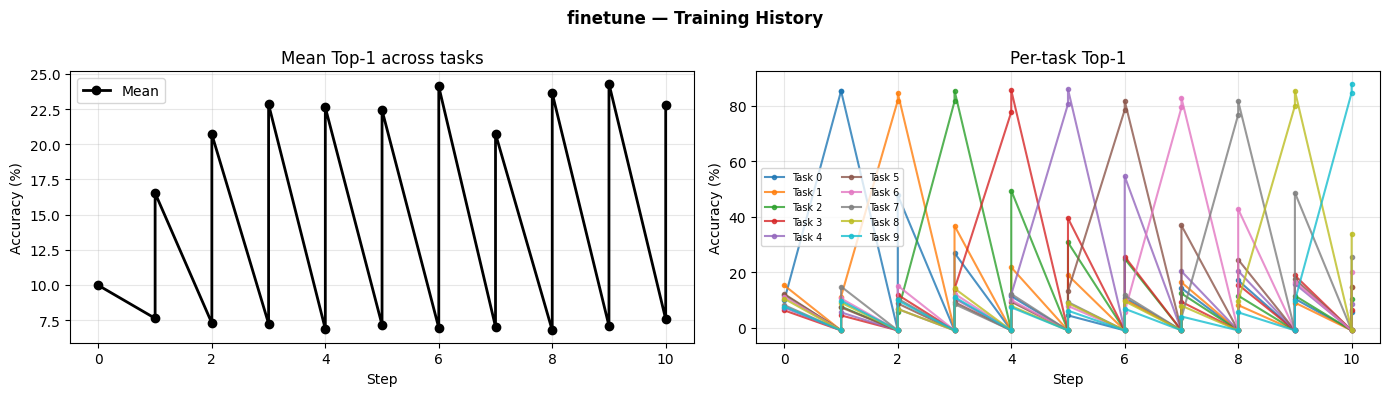

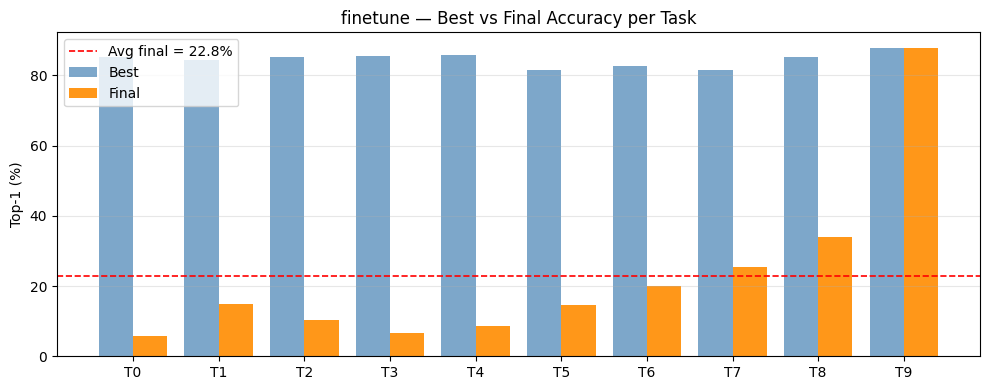

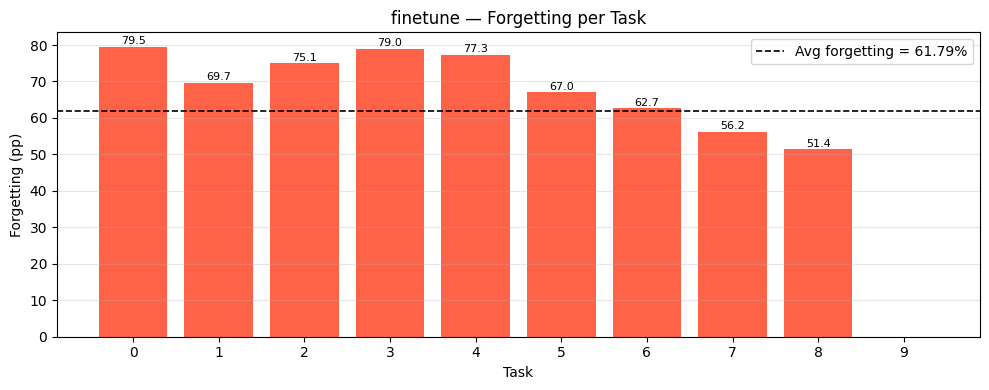


===== FEATURES =====


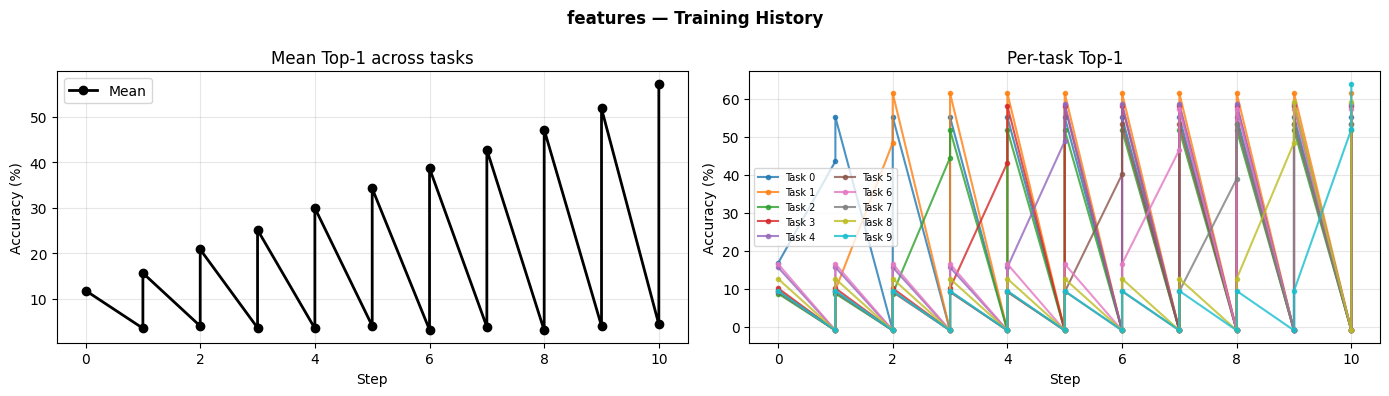

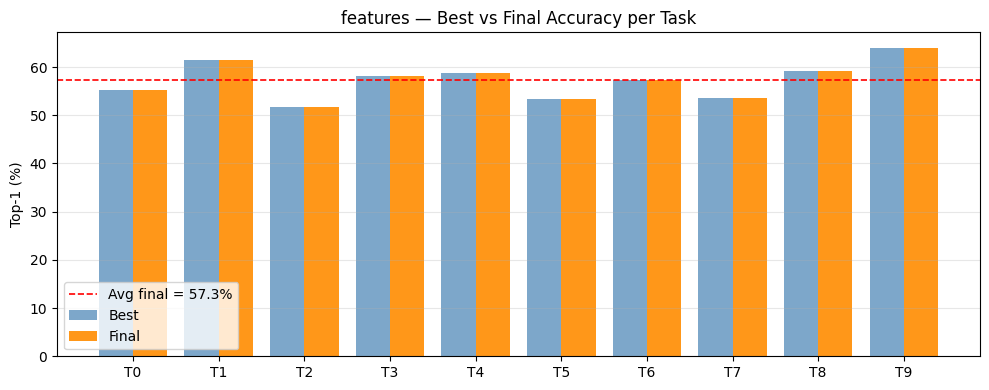

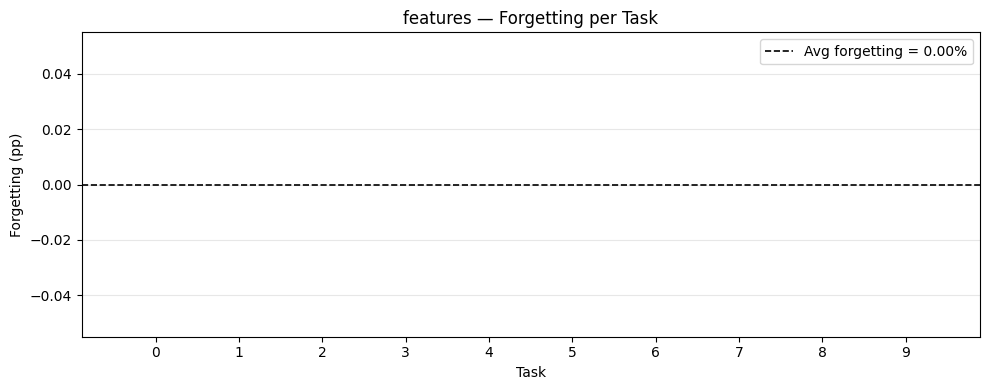


===== SIDETUNE =====


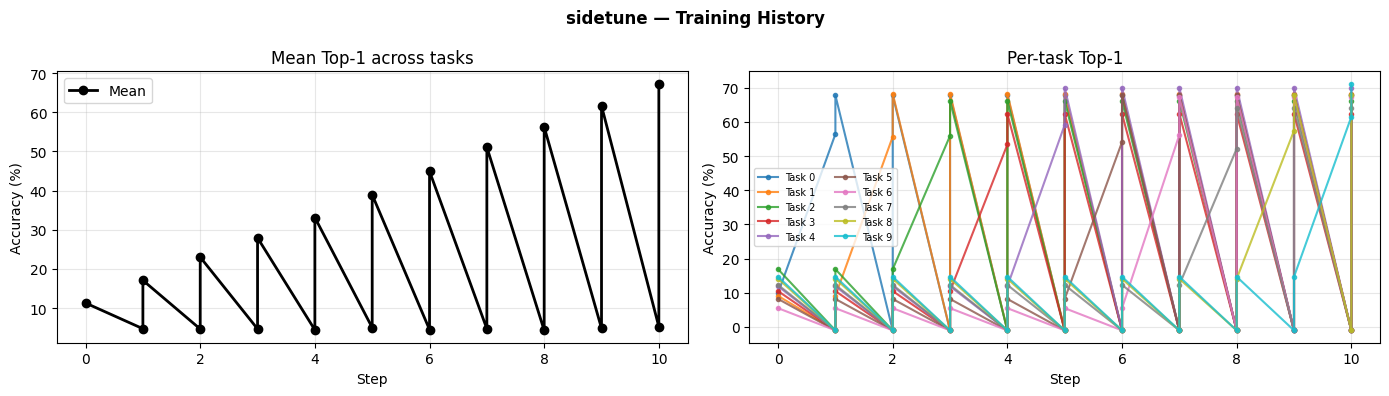

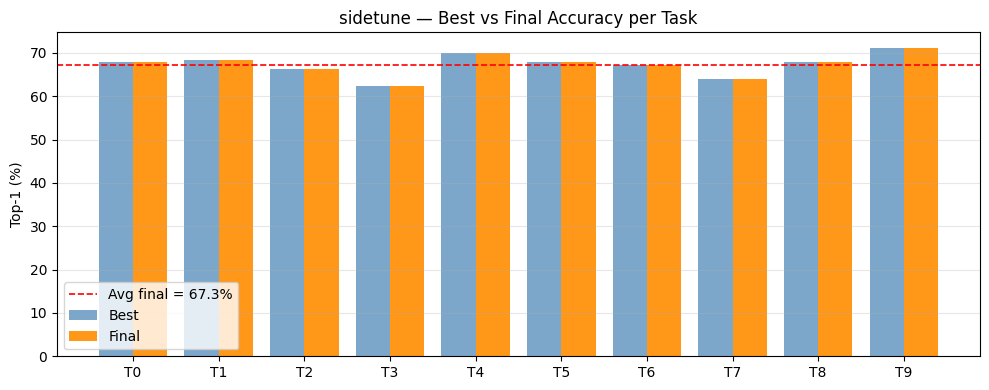

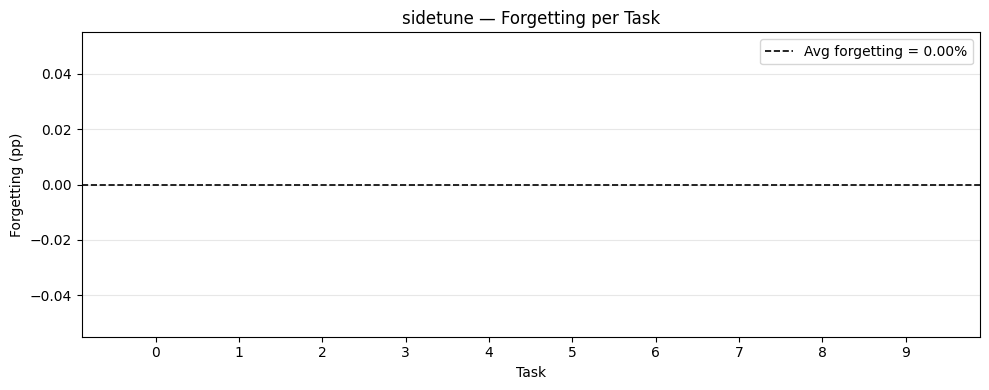


===== INDEPENDENT =====


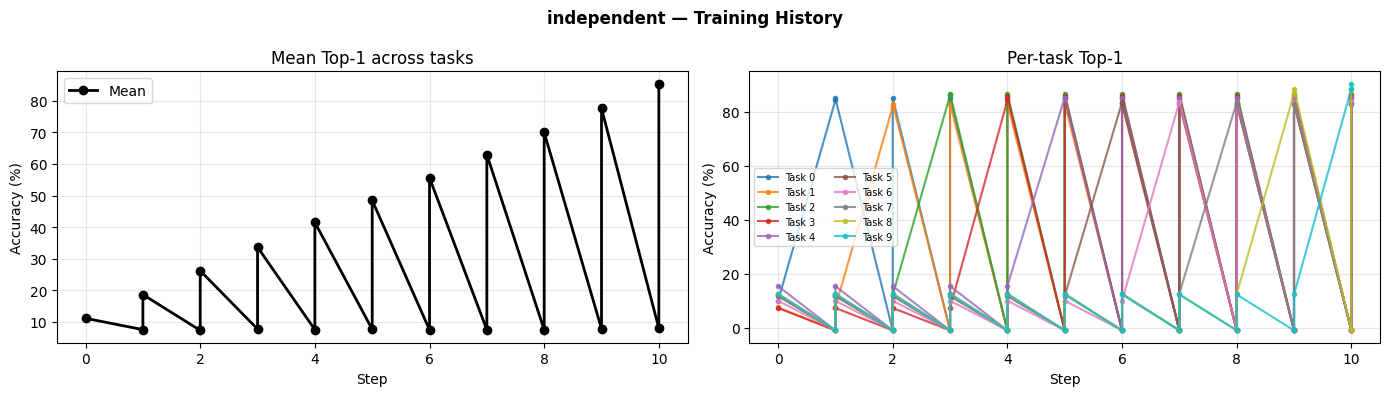

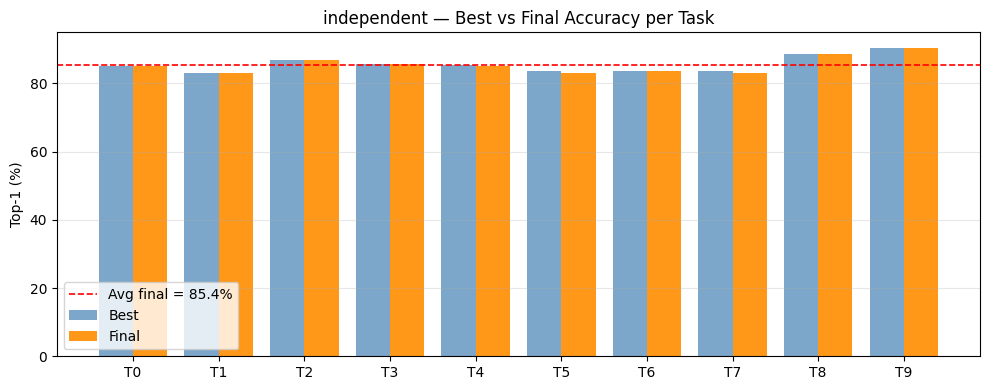

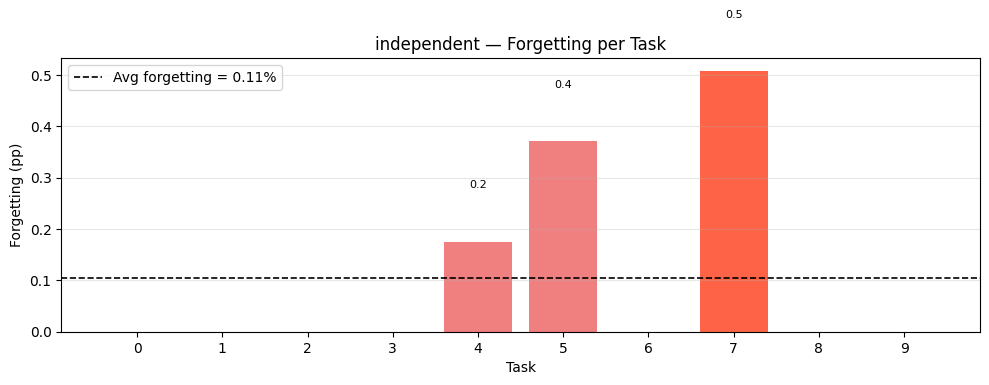

<Axes: title={'center': 'Comparaison des méthodes (iCIFAR-100)'}, xlabel='method'>

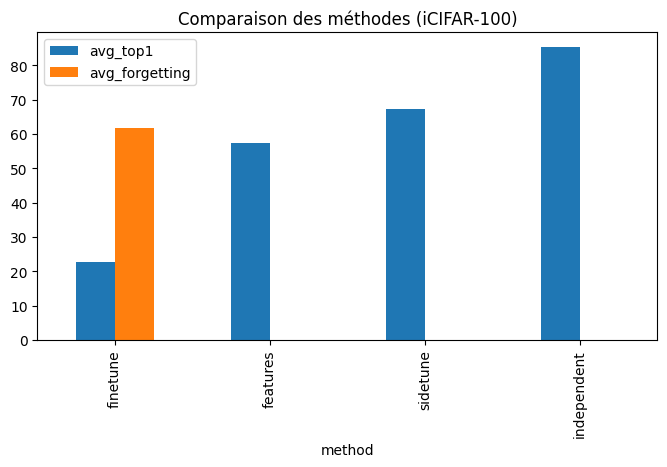

In [ ]:
import pandas as pd
import importlib
import os
import sys
from pathlib import Path 

HOME = os.environ["HOME"]
REPO = f"{HOME}/side-tuning"

if REPO not in sys.path:
    sys.path.insert(0, REPO)

import analysis.runner
import analysis.parser
import analysis.visualizer

importlib.reload(analysis.runner)
importlib.reload(analysis.parser)
importlib.reload(analysis.visualizer)

from analysis.runner import ExperimentRunner
from analysis.parser import ResultExtractor
from analysis.visualizer import Visualizer



runner = ExperimentRunner(repo_root=REPO, run_root="runs")
viz = Visualizer()

experiments = {
    "finetune": {
        "output": "runs/finetune",
        "configs": [
            "cifar_hp",
            "icifar_data",
            "model_lifelong_finetune_cifar",
        ],
        "overrides": {
            "cfg.training.dataloader_fn_kwargs.data_path": f"{HOME}/datasets",
            "cfg.learner.model_kwargs.base_kwargs.base_weights_path": f"{REPO}/assets/pytorch/resnet44-cifar.pth",
            "cfg.learner.model_kwargs.base_kwargs.side_weights_path": f"{REPO}/assets/pytorch/distillation/fcn4-cifar.pth",
        },
    },

    "features": {
        "output": "runs/features",
        "configs": [
            "cifar_hp",
            "icifar_data",
            "model_lifelong_features_cifar",
        ],
        "overrides": {
            "cfg.training.dataloader_fn_kwargs.data_path": f"{HOME}/datasets",
            "cfg.learner.model_kwargs.base_weights_path": f"{REPO}/assets/pytorch/resnet44-cifar.pth",
        },
    },

    "sidetune": {
        "output": "runs/sidetune",
        "configs": [
            "cifar_hp",
            "icifar_data",
            "model_lifelong_sidetune_cifar",
        ],
        "overrides": {
            "cfg.training.dataloader_fn_kwargs.data_path": f"{HOME}/datasets",
            "cfg.learner.model_kwargs.base_weights_path": f"{REPO}/assets/pytorch/resnet44-cifar.pth",
            "cfg.learner.model_kwargs.side_weights_path": f"{REPO}/assets/pytorch/distillation/fcn4-cifar.pth",
        },
    },

    "independent": {
        "output": "runs/independent",
        "configs": [
            "cifar_hp",
            "icifar_data",
            "model_lifelong_independent_cifar",
        ],
        "overrides": {
            "cfg.training.dataloader_fn_kwargs.data_path": f"{HOME}/datasets",
            "cfg.learner.model_kwargs.side_kwargs.base_weights_path": f"{REPO}/assets/pytorch/resnet44-cifar.pth",
            "cfg.learner.model_kwargs.side_kwargs.side_weights_path": f"{REPO}/assets/pytorch/distillation/fcn4-cifar.pth",
        },
    },
}

for name, exp in experiments.items():
    print(f"=== Launching {name} ===")
    runner.run(
        name,
        exp["configs"],
        exp["overrides"],
        output_dir=exp["output"]
    )

summaries = {}

for name, exp in experiments.items():
    result_file = runner.find_result(exp["output"])
    summaries[name] = ResultExtractor(result_file).load().extract()

summaries

for name, summary in summaries.items():
    print(f"\n===== {name.upper()} =====")
    viz.plot_history(summary)
    viz.plot_task_final(summary)
    viz.plot_forgetting(summary)

df = pd.DataFrame([
    {
        "method": name,
        "avg_top1": s.avg_top1,
        "avg_forgetting": s.avg_forgetting
    }
    for name, s in summaries.items()
])

df

df.plot(
    x="method",
    y=["avg_top1", "avg_forgetting"],
    kind="bar",
    figsize=(8,4),
    title="Comparaison des méthodes (iCIFAR-100)")

## Partie 2 : Influence des méthodes de Side-Tuning

### 2.1 : Influence de l'optimiseur

In [ ]:
# ============================================================
# Influence de l'optimiseur & HP 
# ============================================================
import importlib
import sys
import os

HOME = os.environ["HOME"]
REPO = f"{HOME}/side-tuning"
if REPO not in sys.path:
    sys.path.insert(0, REPO)
    
import analysis.runner
import analysis.parser
import analysis.visualizer

importlib.reload(analysis.runner)
importlib.reload(analysis.parser)
importlib.reload(analysis.visualizer)

from analysis.runner import ExperimentRunner
from analysis.parser import ResultExtractor
from analysis.visualizer import Visualizer

base_paths = {
    "cfg.training.dataloader_fn_kwargs.data_path": f"{HOME}/datasets",
    "cfg.learner.model_kwargs.base_weights_path":  f"{REPO}/assets/pytorch/resnet44-cifar.pth",
    "cfg.learner.model_kwargs.side_weights_path":  f"{REPO}/assets/pytorch/distillation/fcn4-cifar.pth",
}

BASE_CONFIGS = ["cifar_hp", "icifar_data", "model_lifelong_sidetune_cifar"]

def adam_exp(lr, wd=0.0):
    """optimizer_kwargs passé en entier pour éviter la fusion Sacred."""
    return {
        "configs": BASE_CONFIGS,
        "overrides": {
            **base_paths,
            "cfg.learner.optimizer_class":   "optim.Adam",
            "cfg.learner.lr":                lr,
            # Dict complet — écrase optimizer_kwargs sans fusion partielle
            "cfg.learner.optimizer_kwargs":  {"weight_decay": wd},
        }
    }

def adamw_exp(lr, wd=1e-2):
    return {
        "configs": BASE_CONFIGS,
        "overrides": {
            **base_paths,
            "cfg.learner.optimizer_class":  "optim.AdamW",
            "cfg.learner.lr":               lr,
            "cfg.learner.optimizer_kwargs": {"weight_decay": wd},
        }
    }

def sgd_exp(lr, momentum=0.9, wd=1e-4):
    """SGD a besoin de momentum — dict séparé propre."""
    return {
        "configs": BASE_CONFIGS,
        "overrides": {
            **base_paths,
            "cfg.learner.optimizer_class":  "optim.SGD",
            "cfg.learner.lr":               lr,
            # momentum inclus ici, jamais passé aux runs Adam/AdamW
            "cfg.learner.optimizer_kwargs": {"weight_decay": wd, "momentum": momentum},
        }
    }

experiments_optim = {
    # ── Adam – sweep LR ────────────────────────────────────
    "adam_lr1e2":        adam_exp(lr=1e-2),
    "adam_lr1e3":        adam_exp(lr=1e-3),        # baseline cifar_hp
    "adam_lr1e4":        adam_exp(lr=1e-4),

    # ── Adam + weight decay ────────────────────────────────
    "adam_lr1e3_wd1e4":  adam_exp(lr=1e-3, wd=1e-4),
    "adam_lr1e3_wd1e5":  adam_exp(lr=1e-3, wd=1e-5),

    # ── AdamW ──────────────────────────────────────────────
    "adamw_lr1e3":       adamw_exp(lr=1e-3, wd=1e-2),
    "adamw_lr1e4":       adamw_exp(lr=1e-4, wd=1e-2),
    "adamw_lr1e3_wd1e3": adamw_exp(lr=1e-3, wd=1e-3),

    # ── SGD + momentum ─────────────────────────────────────
    "sgd_lr1e1":         sgd_exp(lr=1e-1),
    "sgd_lr1e2":         sgd_exp(lr=1e-2),
    "sgd_lr1e3":         sgd_exp(lr=1e-3),
}

# ── Résumé ──────────────────────────────────────────────────
print(f"{len(experiments_optim)} expériences :\n")
print(f"  {'Nom':<22} {'Optim':<12} {'LR':<8} {'optimizer_kwargs'}")
print(f"  {'-'*65}")
for name, exp in experiments_optim.items():
    ov = exp["overrides"]
    print(
        f"  {name:<22}"
        f" {ov['cfg.learner.optimizer_class'].replace('optim.',''):<12}"
        f" {str(ov['cfg.learner.lr']):<8}"
        f" {ov['cfg.learner.optimizer_kwargs']}"
    )
runner = ExperimentRunner(repo_root=REPO, run_root="runs")

11 expériences :

  Nom                    Optim        LR       optimizer_kwargs
  -----------------------------------------------------------------
  adam_lr1e2             Adam         0.01     {'weight_decay': 0.0}
  adam_lr1e3             Adam         0.001    {'weight_decay': 0.0}
  adam_lr1e4             Adam         0.0001   {'weight_decay': 0.0}
  adam_lr1e3_wd1e4       Adam         0.001    {'weight_decay': 0.0001}
  adam_lr1e3_wd1e5       Adam         0.001    {'weight_decay': 1e-05}
  adamw_lr1e3            AdamW        0.001    {'weight_decay': 0.01}
  adamw_lr1e4            AdamW        0.0001   {'weight_decay': 0.01}
  adamw_lr1e3_wd1e3      AdamW        0.001    {'weight_decay': 0.001}
  sgd_lr1e1              SGD          0.1      {'weight_decay': 0.0001, 'momentum': 0.9}
  sgd_lr1e2              SGD          0.01     {'weight_decay': 0.0001, 'momentum': 0.9}
  sgd_lr1e3              SGD          0.001    {'weight_decay': 0.0001, 'momentum': 0.9}


In [ ]:
# ============================================================
# Lancement séquentiel des expériences optimiseur
# ============================================================
failed = []

for name, exp in experiments_optim.items():
    try:
        runner.run(
            name,
            exp["configs"],
            exp["overrides"],
            output_dir=f"runs/optim/{name}",
        )
    except RuntimeError as e:
        print(f"{name} a échoué : {e}")
        failed.append(name)

print(f"\n{'='*40}")
print(f"Réussies : {len(experiments_optim) - len(failed)}/{len(experiments_optim)}")
if failed:
    print(f"Échouées : {failed}")


  Experiment : adam_lr1e2
  Output     : /users/eleves-b/2023/benjamin.wilhelm/side-tuning/runs/optim/adam_lr1e2
  CMD        : /users/eleves-b/2023/benjamin.wilhelm/side-tuning/.venv/bin/python -m scripts.train_lifelong /users/eleves-b/2023/benjamin.wilhelm/side-tuning/runs/optim/adam_lr1e2 train with cifar_hp icifar_data model_lifelong_sidetune_cifar cfg.training.dataloader_fn_kwargs.data_path=/users/eleves-b/2023/benjamin.wilhelm/datasets cfg.learner.model_kwargs.base_weights_path=/users/eleves-b/2023/benjamin.wilhelm/side-tuning/assets/pytorch/resnet44-cifar.pth cfg.learner.model_kwargs.side_weights_path=/users/eleves-b/2023/benjamin.wilhelm/side-tuning/assets/pytorch/distillation/fcn4-cifar.pth cfg.learner.optimizer_class=optim.Adam cfg.learner.lr=0.01 cfg.learner.optimizer_kwargs={'weight_decay': 0.0}

RETURN CODE: 0

STDOUT (dernières lignes):
 	 Alphas: [0.6166091561317444, 0.6406004428863525, 0.6498693823814392, 0.644494891166687, 0.6694720387458801, 0.6345345973968506, 0.613

In [ ]:
# ============================================================
# Extraction des résultats optimiseur
# ============================================================
summaries_optim = {}

for name in experiments_optim:
    try:
        result_file = runner.find_result(f"runs/optim/{name}")
        summaries_optim[name] = ResultExtractor(result_file).load().extract()
        print(f" {name}")
    except FileNotFoundError:
        print(f" {name} — result_log.pkl introuvable (run échouée ?)")

print(f"\n{len(summaries_optim)} résultats chargés.")

 adam_lr1e2
 adam_lr1e3
 adam_lr1e4
 adam_lr1e3_wd1e4
 adam_lr1e3_wd1e5
 adamw_lr1e3
 adamw_lr1e4
 adamw_lr1e3_wd1e3
 sgd_lr1e1
 sgd_lr1e2
 sgd_lr1e3

11 résultats chargés.


In [ ]:
# ============================================================
# Tableau comparatif optimiseurs
# ============================================================
import pandas as pd
rows = []
for name, s in summaries_optim.items():
    ov  = experiments_optim[name]["overrides"]
    opt_kwargs = ov.get("cfg.learner.optimizer_kwargs", {})
    rows.append({
        "experiment":         name,
        "optimizer":          ov.get("cfg.learner.optimizer_class", "?").replace("optim.", ""),
        "lr":                 ov.get("cfg.learner.lr"),
        "weight_decay":       opt_kwargs.get("weight_decay", 0.0),
        "momentum":           opt_kwargs.get("momentum", "-"),
        "avg_top1 (%)":       round(s.avg_top1, 2),
        "avg_forgetting (%)": round(s.avg_forgetting, 2),
    })

df_optim = pd.DataFrame(rows).sort_values("avg_top1 (%)", ascending=False)
print(df_optim.to_string(index=False))
df_optim

       experiment optimizer     lr  weight_decay momentum  avg_top1 (%)  avg_forgetting (%)
       adam_lr1e2      Adam 0.0100       0.00000        -         71.63                 0.0
        sgd_lr1e1       SGD 0.1000       0.00010      0.9         71.52                 0.0
        sgd_lr1e2       SGD 0.0100       0.00010      0.9         69.01                 0.0
      adamw_lr1e3     AdamW 0.0010       0.01000        -         67.44                 0.0
       adam_lr1e3      Adam 0.0010       0.00000        -         67.44                 0.0
 adam_lr1e3_wd1e4      Adam 0.0010       0.00010        -         67.42                 0.0
 adam_lr1e3_wd1e5      Adam 0.0010       0.00001        -         67.32                 0.0
adamw_lr1e3_wd1e3     AdamW 0.0010       0.00100        -         67.27                 0.0
        sgd_lr1e3       SGD 0.0010       0.00010      0.9         53.73                 0.0
      adamw_lr1e4     AdamW 0.0001       0.01000        -         39.97         

,experiment,optimizer,lr,weight_decay,momentum,avg_top1 (%),avg_forgetting (%)
0,adam_lr1e2,Adam,0.0100,0.00000,-,71.63,0.0
8,sgd_lr1e1,SGD,0.1000,0.00010,0.9,71.52,0.0
9,sgd_lr1e2,SGD,0.0100,0.00010,0.9,69.01,0.0
5,adamw_lr1e3,AdamW,0.0010,0.01000,-,67.44,0.0
1,adam_lr1e3,Adam,0.0010,0.00000,-,67.44,0.0
3,adam_lr1e3_wd1e4,Adam,0.0010,0.00010,-,67.42,0.0
4,adam_lr1e3_wd1e5,Adam,0.0010,0.00001,-,67.32,0.0
7,adamw_lr1e3_wd1e3,AdamW,0.0010,0.00100,-,67.27,0.0
10,sgd_lr1e3,SGD,0.0010,0.00010,0.9,53.73,0.0
6,adamw_lr1e4,AdamW,0.0001,0.01000,-,39.97,0.0


/tmp/ipykernel_2747963/3849180149.py:104: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/users/eleves-b/2023/benjamin.wilhelm/side-tuning/.venv/lib64/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


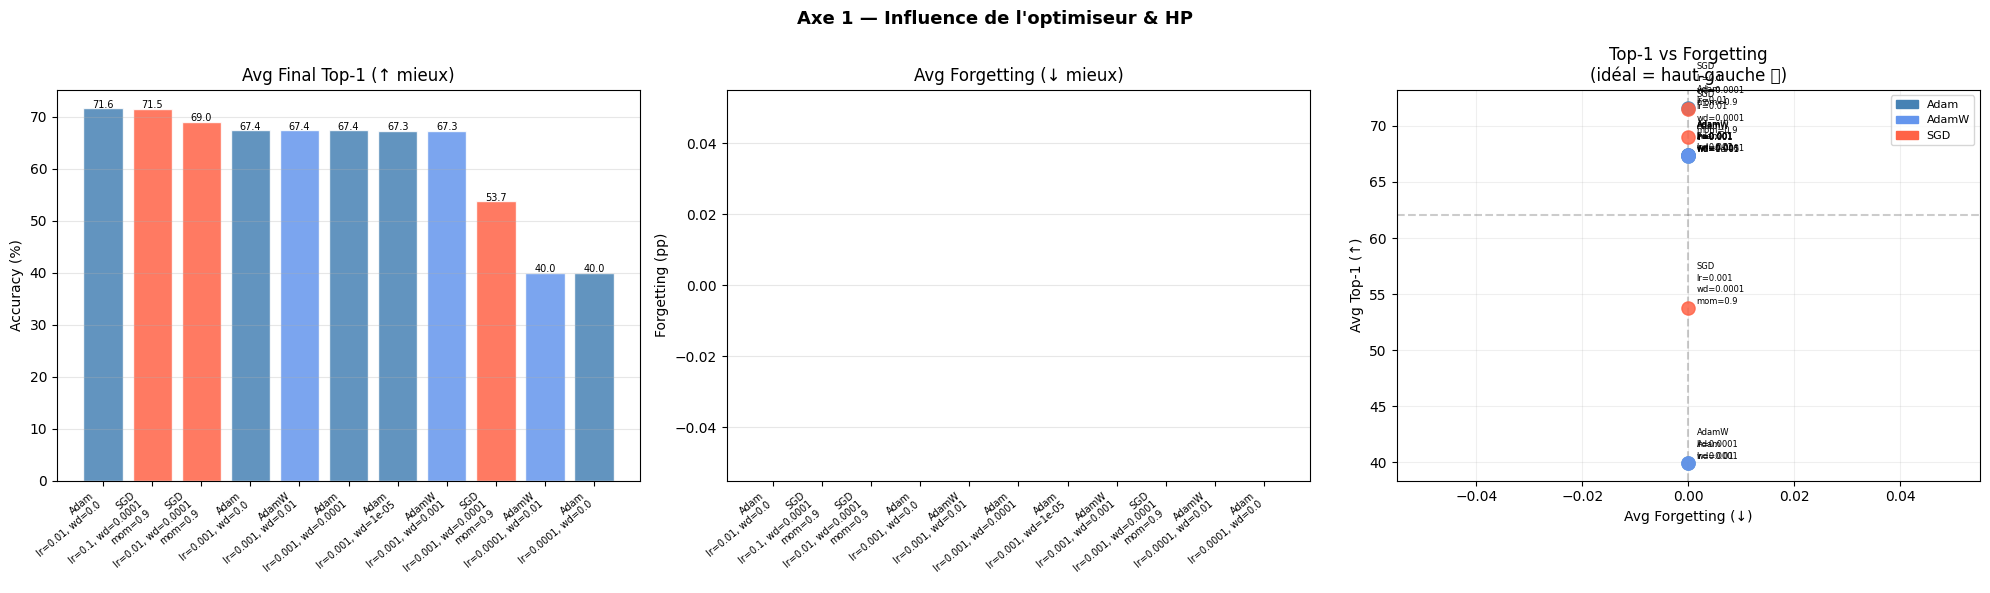

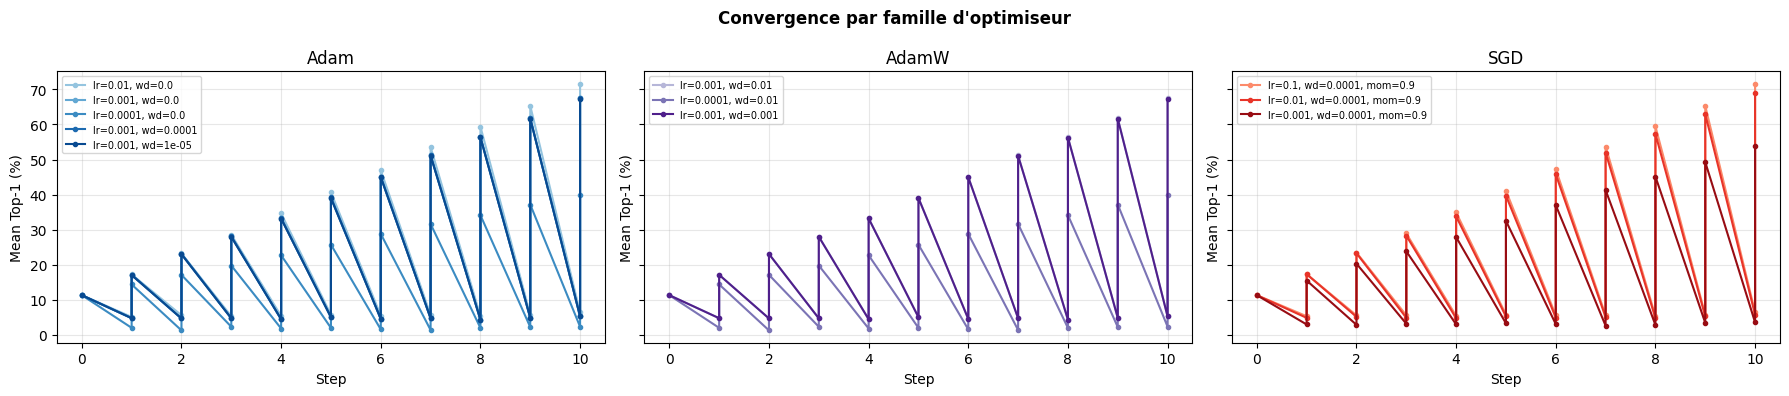


  Method : adam_lr1e2
  Steps  : 21
   Task      Best     Final  Forgetting
  ---------------------------------------------
      0    69.00%    69.00%       0.00%
      1    68.90%    68.90%       0.00%
      2    70.40%    70.40%       0.00%
      3    71.20%    71.20%       0.00%
      4    72.20%    72.20%       0.00%
      5    71.10%    71.10%       0.00%
      6    71.70%    71.70%       0.00%
      7    70.70%    70.70%       0.00%
      8    73.30%    73.30%       0.00%
      9    77.80%    77.80%       0.00%
  ---------------------------------------------
    AVG              71.63%       0.00%


  Method : sgd_lr1e1
  Steps  : 21
   Task      Best     Final  Forgetting
  ---------------------------------------------
      0    69.80%    69.80%       0.00%
      1    70.80%    70.80%       0.00%
      2    71.40%    71.40%       0.00%
      3    70.20%    70.20%       0.00%
      4    73.90%    73.90%       0.00%
      5    69.20%    69.20%       0.00%
      6    70.70%    7

In [ ]:
# ============================================================
# Visualisations comparatives optimiseurs
# ============================================================
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm
import matplotlib.patches as mpatches

viz = Visualizer()

def plot_optim_comparison(summaries_optim, experiments_optim):

    names  = list(summaries_optim.keys())
    top1s  = [summaries_optim[n].avg_top1      for n in names]
    fgs    = [summaries_optim[n].avg_forgetting for n in names]

    def get_label(name):
        ov  = experiments_optim[name]["overrides"]
        opt = ov.get("cfg.learner.optimizer_class", "?").replace("optim.", "")
        lr  = ov.get("cfg.learner.lr")
        kw  = ov.get("cfg.learner.optimizer_kwargs", {})
        wd  = kw.get("weight_decay", 0.0)
        mom = kw.get("momentum", None)
        label = f"{opt}\nlr={lr}, wd={wd}"
        if mom is not None:
            label += f"\nmom={mom}"
        return label

    def get_optim(name):
        return experiments_optim[name]["overrides"] \
                .get("cfg.learner.optimizer_class", "?").replace("optim.", "")

    optims   = [get_optim(n) for n in names]
    labels   = [get_label(n) for n in names]

    color_map = {"Adam": "steelblue", "AdamW": "cornflowerblue", "SGD": "tomato"}
    colors = [color_map.get(o, "gray") for o in optims]

    order    = sorted(range(len(top1s)), key=lambda i: top1s[i], reverse=True)
    labels_s = [labels[i]  for i in order]
    top1s_s  = [top1s[i]   for i in order]
    fgs_s    = [fgs[i]     for i in order]
    colors_s = [colors[i]  for i in order]

    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    fig.suptitle("Axe 1 — Influence de l'optimiseur & HP", fontweight="bold", fontsize=13)

    x = np.arange(len(labels_s))

    # Barplot Top-1 
    bars = axes[0].bar(x, top1s_s, color=colors_s, alpha=0.85, edgecolor="white")
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(labels_s, rotation=40, ha="right", fontsize=7)
    axes[0].set_title("Avg Final Top-1 (↑ mieux)")
    axes[0].set_ylabel("Accuracy (%)")
    axes[0].grid(axis="y", alpha=0.3)
    for bar, v in zip(bars, top1s_s):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                     f"{v:.1f}", ha="center", fontsize=7)

    # Barplot Forgetting
    bars2 = axes[1].bar(x, fgs_s, color=colors_s, alpha=0.85, edgecolor="white")
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(labels_s, rotation=40, ha="right", fontsize=7)
    axes[1].set_title("Avg Forgetting (↓ mieux)")
    axes[1].set_ylabel("Forgetting (pp)")
    axes[1].grid(axis="y", alpha=0.3)
    for bar, v in zip(bars2, fgs_s):
        if v > 0.05:
            axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                         f"{v:.1f}", ha="center", fontsize=7)

    #  Scatter Top-1 vs Forgetting 
    for i, name in enumerate(names):
        o  = optims[i]
        kw = experiments_optim[name]["overrides"].get("cfg.learner.optimizer_kwargs", {})
        wd  = kw.get("weight_decay", 0.0)
        mom = kw.get("momentum", None)
        lr  = experiments_optim[name]["overrides"].get("cfg.learner.lr")

        # Annotation avec tous les HP
        annot = f"{o}\nlr={lr}"
        if wd > 0:
            annot += f"\nwd={wd}"
        if mom is not None:
            annot += f"\nmom={mom}"

        axes[2].scatter(fgs[i], top1s[i], color=color_map.get(o, "gray"),
                        s=90, alpha=0.85, zorder=3)
        axes[2].annotate(annot, (fgs[i], top1s[i]),
                         textcoords="offset points", xytext=(6, 3), fontsize=6,
                         linespacing=1.4)

    axes[2].axvline(np.mean(fgs),   color="gray", linestyle="--", alpha=0.4)
    axes[2].axhline(np.mean(top1s), color="gray", linestyle="--", alpha=0.4)
    axes[2].set_xlabel("Avg Forgetting (↓)")
    axes[2].set_ylabel("Avg Top-1 (↑)")
    axes[2].set_title("Top-1 vs Forgetting\n(idéal = haut-gauche ✅)")
    axes[2].grid(alpha=0.2)

    legend = [mpatches.Patch(color=c, label=k) for k, c in color_map.items()]
    axes[2].legend(handles=legend, fontsize=8)

    plt.tight_layout()
    plt.show()


def plot_optim_histories(summaries_optim, experiments_optim):
    """Courbes de convergence groupées par famille, label = lr + wd + mom."""
    families = {"Adam": [], "AdamW": [], "SGD": []}
    for name, s in summaries_optim.items():
        o = experiments_optim[name]["overrides"] \
              .get("cfg.learner.optimizer_class", "?").replace("optim.", "")
        families.get(o, families.setdefault(o, [])).append((name, s))

    n_fam = sum(1 for v in families.values() if v)
    fig, axes = plt.subplots(1, n_fam, figsize=(6 * n_fam, 4), sharey=True)
    if n_fam == 1:
        axes = [axes]
    fig.suptitle("Convergence par famille d'optimiseur", fontweight="bold")

    fam_colors = {"Adam": cm.Blues, "AdamW": cm.Purples, "SGD": cm.Reds}
    ax_idx = 0

    for fam, members in families.items():
        if not members:
            continue
        ax    = axes[ax_idx]
        cmap  = fam_colors.get(fam, cm.Greys)
        cols  = cmap(np.linspace(0.4, 0.9, len(members)))

        for (name, s), color in zip(members, cols):
            ov  = experiments_optim[name]["overrides"]
            kw  = ov.get("cfg.learner.optimizer_kwargs", {})
            lr  = ov.get("cfg.learner.lr", "?")
            wd  = kw.get("weight_decay", 0.0)
            mom = kw.get("momentum", None)

            # Label complet sur la courbe
            label = f"lr={lr}, wd={wd}"
            if mom is not None:
                label += f", mom={mom}"

            steps = [h["step"] for h in s.history]
            accs  = [h["top1"] for h in s.history]
            ax.plot(steps, accs, marker="o", markersize=3,
                    color=color, label=label, linewidth=1.5)

        ax.set_title(fam)
        ax.set_xlabel("Step")
        ax.set_ylabel("Mean Top-1 (%)")
        ax.legend(fontsize=7)
        ax.grid(alpha=0.3)
        ax_idx += 1

    plt.tight_layout()
    plt.show()


# Lancement 
plot_optim_comparison(summaries_optim, experiments_optim)
plot_optim_histories(summaries_optim, experiments_optim)

for name, s in sorted(summaries_optim.items(),
                       key=lambda x: x[1].avg_top1, reverse=True):
    viz.print_summary_table(s)

In [ ]:
# ============================================================
# Meilleur optimiseur (pour la suite)
# ============================================================
best_optim_name = max(summaries_optim, key=lambda n: summaries_optim[n].avg_top1)
best_optim_overrides = {
    k: v for k, v in experiments_optim[best_optim_name]["overrides"].items()
    if "optimizer" in k or k == "cfg.learner.lr"
}

print(f" Meilleur optimiseur : {best_optim_name}")
print(f"   avg_top1      = {summaries_optim[best_optim_name].avg_top1:.2f}%")
print(f"   avg_forgetting= {summaries_optim[best_optim_name].avg_forgetting:.2f}%")
print(f"\n   Overrides à réutiliser en Axe 2 :")
for k, v in best_optim_overrides.items():
    print(f"     {k} = {v}")

 Meilleur optimiseur : adam_lr1e2
   avg_top1      = 71.63%
   avg_forgetting= 0.00%

   Overrides à réutiliser en Axe 2 :
     cfg.learner.optimizer_class = optim.Adam
     cfg.learner.lr = 0.01
     cfg.learner.optimizer_kwargs = {'weight_decay': 0.0}


### 2.2 influence de l'association entre la base et le réseau principal

In [ ]:
# ============================================================
# Influence de la combinaison Base + Side
# ============================================================

# Meilleurs HP optimiseur trouvés en Axe 1
best_optim_overrides = {
    k: v for k, v in experiments_optim[best_optim_name]["overrides"].items()
    if "optimizer" in k or k == "cfg.learner.lr"
}
print(f"Réutilisation de : {best_optim_name}")
print(f"  overrides optim : {best_optim_overrides}\n")

# Configs de combinaison disponibles dans vision_lifelong.py
MERGE_CONFIGS = {
    "alpha":        "merge_alpha",        # défaut — α appris
    "film":         "merge_film",         # Feature-wise Linear Modulation
    "product":      "merge_product",      # multiplication élément par élément
    "mlp":          "merge_mlp",          # MLP 1 couche cachée
    "mlp2":         "merge_mlp2",         # MLP 2 couches cachées
    "resmlp2":      "merge_resmlp2",      # MLP résiduel 2 couches
    "mlp_hidden_a": "merge_mlp_hidden_a", # MLPHidden, pas d'activation finale base/side
    "mlp_hidden_b": "merge_mlp_hidden_b", # MLPHidden, activation finale sur base
}

experiments_merge = {}
for merge_name, merge_config in MERGE_CONFIGS.items():
    experiments_merge[f"merge_{merge_name}"] = {
        # merge_config s'ajoute à la liste des configs Sacred
        "configs": BASE_CONFIGS + [merge_config],
        "overrides": {
            **base_paths,
            **best_optim_overrides,
        }
    }

# Résumé
print(f"{len(experiments_merge)} expériences :\n")
print(f"  {'Nom':<22} {'Config Sacred':<25} {'Optim':<10} {'LR'}")
print(f"  {'-'*65}")
for name, exp in experiments_merge.items():
    ov = exp["overrides"]
    merge_cfg = [c for c in exp["configs"] if c.startswith("merge_")][0]
    print(
        f"  {name:<22}"
        f" {merge_cfg:<25}"
        f" {ov.get('cfg.learner.optimizer_class','?').replace('optim.',''):<10}"
        f" {ov.get('cfg.learner.lr','?')}"
    )

Réutilisation de : adam_lr1e2
  overrides optim : {'cfg.learner.optimizer_class': 'optim.Adam', 'cfg.learner.lr': 0.01, 'cfg.learner.optimizer_kwargs': {'weight_decay': 0.0}}

8 expériences :

  Nom                    Config Sacred             Optim      LR
  -----------------------------------------------------------------
  merge_alpha            merge_alpha               Adam       0.01
  merge_film             merge_film                Adam       0.01
  merge_product          merge_product             Adam       0.01
  merge_mlp              merge_mlp                 Adam       0.01
  merge_mlp2             merge_mlp2                Adam       0.01
  merge_resmlp2          merge_resmlp2             Adam       0.01
  merge_mlp_hidden_a     merge_mlp_hidden_a        Adam       0.01
  merge_mlp_hidden_b     merge_mlp_hidden_b        Adam       0.01


In [ ]:
# ============================================================
# Lancement Expérience 2
# ============================================================
failed_merge = []

for name, exp in experiments_merge.items():
    try:
        runner.run(
            name,
            exp["configs"],
            exp["overrides"],
            output_dir=f"runs/merge/{name}",
        )
    except RuntimeError as e:
        print(f"{name} échoué : {e}")
        failed_merge.append(name)

print(f"\n{'='*40}")
print(f"Réussies : {len(experiments_merge) - len(failed_merge)}/{len(experiments_merge)}")
if failed_merge:
    print(f"Échouées : {failed_merge}")


  Experiment : merge_alpha
  Output     : /users/eleves-b/2023/benjamin.wilhelm/side-tuning/runs/merge/merge_alpha
  CMD        : /users/eleves-b/2023/benjamin.wilhelm/side-tuning/.venv/bin/python -m scripts.train_lifelong /users/eleves-b/2023/benjamin.wilhelm/side-tuning/runs/merge/merge_alpha train with cifar_hp icifar_data model_lifelong_sidetune_cifar merge_alpha cfg.training.dataloader_fn_kwargs.data_path=/users/eleves-b/2023/benjamin.wilhelm/datasets cfg.learner.model_kwargs.base_weights_path=/users/eleves-b/2023/benjamin.wilhelm/side-tuning/assets/pytorch/resnet44-cifar.pth cfg.learner.model_kwargs.side_weights_path=/users/eleves-b/2023/benjamin.wilhelm/side-tuning/assets/pytorch/distillation/fcn4-cifar.pth cfg.learner.optimizer_class=optim.SGD cfg.learner.lr=0.1 cfg.learner.optimizer_kwargs={'weight_decay': 0.0001, 'momentum': 0.9}

RETURN CODE: 0

STDOUT (dernières lignes):
 	 Alphas: [0.8726587891578674, 0.8713551759719849, 0.8533657789230347, 0.8176449537277222, 0.888238906

In [ ]:
# ============================================================
# Extraction résultats
# ============================================================
summaries_merge = {}

for name in experiments_merge:
    try:
        result_file = runner.find_result(f"runs/merge/{name}")
        summaries_merge[name] = ResultExtractor(result_file).load().extract()
        print(f" {name}")
    except FileNotFoundError:
        print(f" {name} — introuvable")

print(f"\n{len(summaries_merge)} résultats chargés.")

 merge_alpha
 merge_film
 merge_product
 merge_mlp
 merge_mlp2
 merge_resmlp2
 merge_mlp_hidden_a
 merge_mlp_hidden_b

8 résultats chargés.


/tmp/ipykernel_2747963/3773466451.py:67: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/users/eleves-b/2023/benjamin.wilhelm/side-tuning/.venv/lib64/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


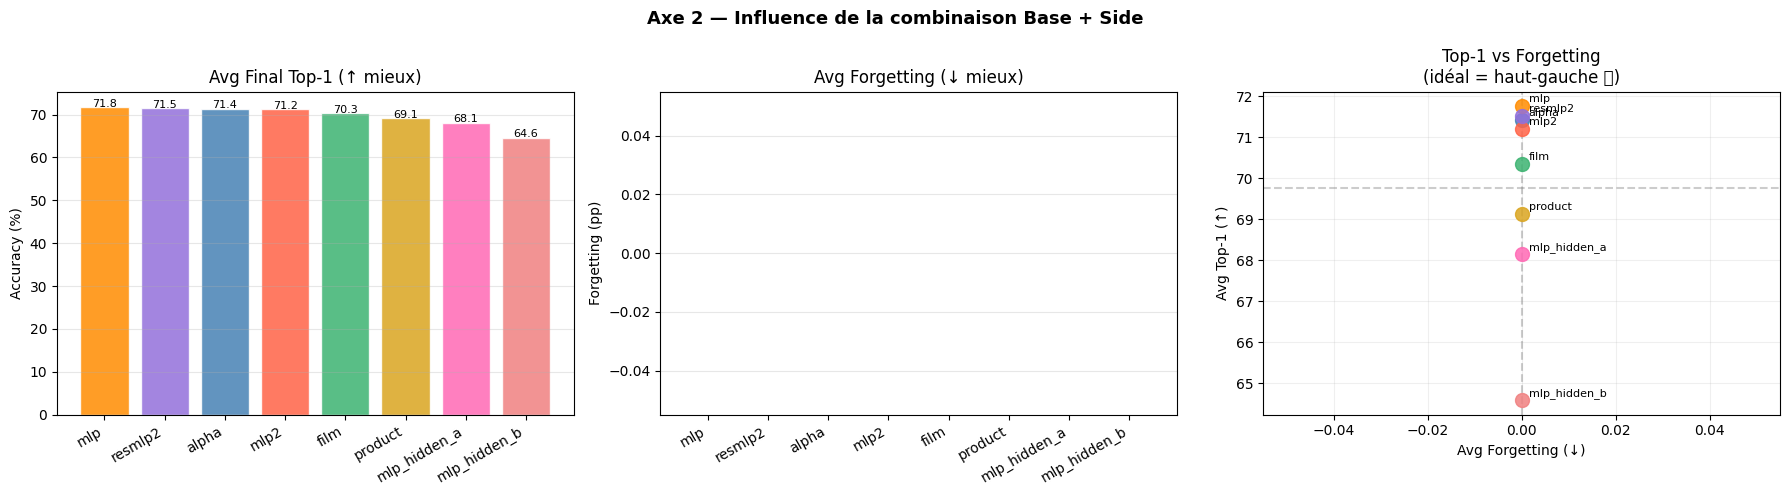

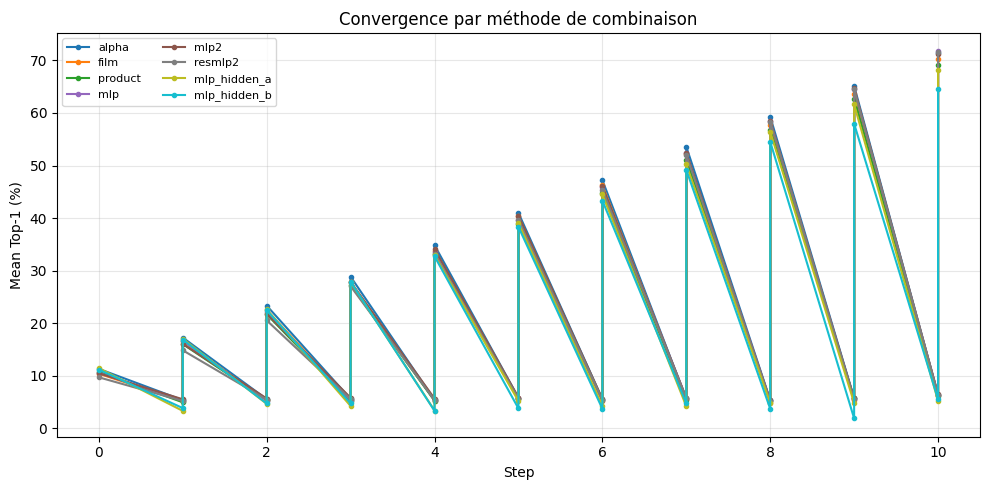

In [ ]:
# ============================================================
# isualisations
# ============================================================
def plot_merge_comparison(summaries_merge, experiments_merge):

    names  = list(summaries_merge.keys())
    top1s  = [summaries_merge[n].avg_top1      for n in names]
    fgs    = [summaries_merge[n].avg_forgetting for n in names]

    # Couleur par famille de merge
    color_map = {
        "alpha":        "steelblue",
        "film":         "mediumseagreen",
        "product":      "goldenrod",
        "mlp":          "darkorange",
        "mlp2":         "tomato",
        "resmlp2":      "mediumpurple",
        "mlp_hidden_a": "hotpink",
        "mlp_hidden_b": "lightcoral",
    }
    colors = [color_map.get(n.replace("merge_", ""), "gray") for n in names]

    order    = sorted(range(len(top1s)), key=lambda i: top1s[i], reverse=True)
    names_s  = [names[i]  for i in order]
    top1s_s  = [top1s[i]  for i in order]
    fgs_s    = [fgs[i]    for i in order]
    colors_s = [colors[i] for i in order]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle("Axe 2 — Influence de la combinaison Base + Side", fontweight="bold", fontsize=13)

    # Barplot Top-1 
    x = np.arange(len(names_s))
    bars = axes[0].bar(x, top1s_s, color=colors_s, alpha=0.85, edgecolor="white")
    axes[0].set_xticks(x)
    axes[0].set_xticklabels([n.replace("merge_", "") for n in names_s], rotation=30, ha="right")
    axes[0].set_title("Avg Final Top-1 (↑ mieux)")
    axes[0].set_ylabel("Accuracy (%)")
    axes[0].grid(axis="y", alpha=0.3)
    for bar, v in zip(bars, top1s_s):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                     f"{v:.1f}", ha="center", fontsize=8)

    # Barplot Forgetting
    bars2 = axes[1].bar(x, fgs_s, color=colors_s, alpha=0.85, edgecolor="white")
    axes[1].set_xticks(x)
    axes[1].set_xticklabels([n.replace("merge_", "") for n in names_s], rotation=30, ha="right")
    axes[1].set_title("Avg Forgetting (↓ mieux)")
    axes[1].set_ylabel("Forgetting (pp)")
    axes[1].grid(axis="y", alpha=0.3)

    # Scatter Top-1 vs Forgetting 
    for i, name in enumerate(names):
        axes[2].scatter(fgs[i], top1s[i], color=colors[i], s=100, alpha=0.85, zorder=3)
        axes[2].annotate(
            name.replace("merge_", ""),
            (fgs[i], top1s[i]),
            textcoords="offset points", xytext=(5, 3), fontsize=8
        )
    axes[2].axvline(np.mean(fgs),   color="gray", linestyle="--", alpha=0.4)
    axes[2].axhline(np.mean(top1s), color="gray", linestyle="--", alpha=0.4)
    axes[2].set_xlabel("Avg Forgetting (↓)")
    axes[2].set_ylabel("Avg Top-1 (↑)")
    axes[2].set_title("Top-1 vs Forgetting\n(idéal = haut-gauche ✅)")
    axes[2].grid(alpha=0.2)

    plt.tight_layout()
    plt.show()


def plot_merge_histories(summaries_merge):
    """Toutes les courbes de convergence sur un même graphe."""
    fig, ax = plt.subplots(figsize=(10, 5))
    colors = cm.tab10(np.linspace(0, 1, len(summaries_merge)))

    for (name, s), color in zip(summaries_merge.items(), colors):
        steps = [h["step"] for h in s.history]
        accs  = [h["top1"] for h in s.history]
        ax.plot(steps, accs, marker="o", markersize=3,
                color=color, label=name.replace("merge_", ""), linewidth=1.5)

    ax.set_title("Convergence par méthode de combinaison")
    ax.set_xlabel("Step")
    ax.set_ylabel("Mean Top-1 (%)")
    ax.legend(fontsize=8, ncol=2)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_merge_comparison(summaries_merge, experiments_merge)
plot_merge_histories(summaries_merge)

### 2.3 Comparaison de la structure du réseau de sidetuning

In [ ]:
# ============================================================
# Influence de l'architecture du side network
# ============================================================

# Meilleurs HP des axes précédents
best_optim_overrides = {
    k: v for k, v in experiments_optim[best_optim_name]["overrides"].items()
    if "optimizer" in k or k == "cfg.learner.lr"
}
best_merge_config = "merge_mlp"

print(f"Réutilisation optim  : {best_optim_name} → {best_optim_overrides}")
print(f"Réutilisation merge  : {best_merge_config}\n")

BASE_CONFIGS_AXE3 = ["cifar_hp", "icifar_data", "model_lifelong_sidetune_cifar", best_merge_config]

BASE_WEIGHTS  = f"{REPO}/assets/pytorch/resnet44-cifar.pth"
SIDE_WEIGHTS  = f"{REPO}/assets/pytorch/distillation/fcn4-cifar.pth"

experiments_side = {

    # ── Baseline : FCN4 pretrained ─────────────────────────
    "side_fcn4_pretrained": {
        "configs": BASE_CONFIGS_AXE3,
        "overrides": {
            **base_paths,
            **best_optim_overrides,
        }
    },

    # ── FCN4 from scratch ──────────────────────────────────
    "side_fcn4_scratch": {
        "configs": BASE_CONFIGS_AXE3,
        "overrides": {
            **base_paths,
            **best_optim_overrides,
            "cfg.learner.model_kwargs.side_weights_path": None,
        }
    },

    # ── Pas de side (features only) ────────────────────────
    # model_lifelong_features_cifar hardcode /mnt/models/resnet44-nolinear-cifar.pth
    "side_none": {
        "configs": ["cifar_hp", "icifar_data", "model_lifelong_features_cifar", best_merge_config],
        "overrides": {
            **base_paths,
            **best_optim_overrides,
            "cfg.learner.model_kwargs.base_weights_path": BASE_WEIGHTS,
        }
    },

    # ── Side = Linear (side_class=None → ZeroFn) ───────────
    "side_linear": {
        "configs": BASE_CONFIGS_AXE3,
        "overrides": {
            **base_paths,
            **best_optim_overrides,
            "cfg.learner.model_kwargs.side_class":        None,
            "cfg.learner.model_kwargs.side_weights_path": None,
        }
    },

    # ── Side = ResNet44 (double resnet) ────────────────────
    # model_lifelong_sidetune_double_resnet_cifar hardcode les deux chemins
    "side_resnet44": {
        "configs": ["cifar_hp", "icifar_data",
                    "model_lifelong_sidetune_double_resnet_cifar", best_merge_config],
        "overrides": {
            **base_paths,
            **best_optim_overrides,
            "cfg.learner.model_kwargs.base_weights_path": BASE_WEIGHTS,
            "cfg.learner.model_kwargs.side_weights_path": BASE_WEIGHTS,
        }
    },

    # ── Independent : base+side entraînés ensemble ─────────
    # model_lifelong_independent_cifar hardcode dans side_kwargs imbriqué
    "side_independent": {
        "configs": ["cifar_hp", "icifar_data",
                    "model_lifelong_independent_cifar", best_merge_config],
        "overrides": {
            **base_paths,
            **best_optim_overrides,
            "cfg.learner.model_kwargs.side_kwargs.base_weights_path": BASE_WEIGHTS,
            "cfg.learner.model_kwargs.side_kwargs.side_weights_path": SIDE_WEIGHTS,
        }
    },

    # ── Finetune ResNet44 (upper bound) ────────────────────
    # model_lifelong_finetune_resnet44_cifar hardcode base_weights_path
    "side_finetune": {
        "configs": ["cifar_hp", "icifar_data",
                    "model_lifelong_finetune_resnet44_cifar", best_merge_config],
        "overrides": {
            **base_paths,
            **best_optim_overrides,
            "cfg.learner.model_kwargs.base_weights_path": BASE_WEIGHTS,
        }
    },
}

print(f"{len(experiments_side)} expériences configurées")
for name, exp in experiments_side.items():
    print(f"  {name:<25} configs={exp['configs']}")

# Résumé
print(f"{len(experiments_side)} expériences :\n")
print(f"  {'Nom':<25} {'Side network':<35} {'Configs Sacred'}")
print(f"  {'-'*80}")
descriptions = {
    "side_fcn4_pretrained": "FCN4 pretrained  (baseline)",
    "side_fcn4_scratch":    "FCN4 from scratch",
    "side_none":            "Aucun side (features only)",
    "side_linear":          "Linear 1 couche",
    "side_resnet44":        "ResNet44 as side",
    "side_independent":     "Base+Side indépendants",
    "side_finetune":        "Finetune (upper bound)",
}
for name, exp in experiments_side.items():
    print(
        f"  {name:<25}"
        f" {descriptions[name]:<35}"
        f" {exp['configs']}"
    )

Réutilisation optim  : adam_lr1e2 → {'cfg.learner.optimizer_class': 'optim.Adam', 'cfg.learner.lr': 0.01, 'cfg.learner.optimizer_kwargs': {'weight_decay': 0.0}}
Réutilisation merge  : merge_mlp

7 expériences configurées
  side_fcn4_pretrained      configs=['cifar_hp', 'icifar_data', 'model_lifelong_sidetune_cifar', 'merge_mlp']
  side_fcn4_scratch         configs=['cifar_hp', 'icifar_data', 'model_lifelong_sidetune_cifar', 'merge_mlp']
  side_none                 configs=['cifar_hp', 'icifar_data', 'model_lifelong_features_cifar', 'merge_mlp']
  side_linear               configs=['cifar_hp', 'icifar_data', 'model_lifelong_sidetune_cifar', 'merge_mlp']
  side_resnet44             configs=['cifar_hp', 'icifar_data', 'model_lifelong_sidetune_double_resnet_cifar', 'merge_mlp']
  side_independent          configs=['cifar_hp', 'icifar_data', 'model_lifelong_independent_cifar', 'merge_mlp']
  side_finetune             configs=['cifar_hp', 'icifar_data', 'model_lifelong_finetune_resnet44_cifa

In [ ]:
# ============================================================
# Lancement des expériences 
# ============================================================
failed_side = []

for name, exp in experiments_side.items():
    try:
        runner.run(
            name,
            exp["configs"],
            exp["overrides"],
            output_dir=f"runs/side/{name}",
        )
        print(f"{name}")
    except RuntimeError as e:
        print(f"{name} échoué : {e}")
        failed_side.append(name)

print(f"\n{'='*40}")
print(f"Réussies : {len(experiments_side) - len(failed_side)}/{len(experiments_side)}")
if failed_side:
    print(f"Échouées : {failed_side}")


  Experiment : side_fcn4_pretrained
  Output     : /users/eleves-b/2023/benjamin.wilhelm/side-tuning/runs/side/side_fcn4_pretrained
  CMD        : /users/eleves-b/2023/benjamin.wilhelm/side-tuning/.venv/bin/python -m scripts.train_lifelong /users/eleves-b/2023/benjamin.wilhelm/side-tuning/runs/side/side_fcn4_pretrained train with cifar_hp icifar_data model_lifelong_sidetune_cifar merge_mlp cfg.training.dataloader_fn_kwargs.data_path=/users/eleves-b/2023/benjamin.wilhelm/datasets cfg.learner.model_kwargs.base_weights_path=/users/eleves-b/2023/benjamin.wilhelm/side-tuning/assets/pytorch/resnet44-cifar.pth cfg.learner.model_kwargs.side_weights_path=/users/eleves-b/2023/benjamin.wilhelm/side-tuning/assets/pytorch/distillation/fcn4-cifar.pth cfg.learner.optimizer_class=optim.Adam cfg.learner.lr=0.01 cfg.learner.optimizer_kwargs={'weight_decay': 0.0}

RETURN CODE: 0

STDOUT (dernières lignes):
 	 Alphas: [-1, -1, -1, -1, -1, -1, -1, -1, -1, -1]
Logging step 9 (val)  | total loss: 2.445308 


In [ ]:
# ============================================================
# Extraction résultats
# ============================================================
summaries_side = {}

for name in experiments_side:
    try:
        result_file = runner.find_result(f"runs/side/{name}")
        summaries_side[name] = ResultExtractor(result_file).load().extract()
        print(f"{name}")
    except FileNotFoundError:
        print(f"{name} — introuvable")

print(f"\n{len(summaries_side)} résultats chargés.")

side_fcn4_pretrained
side_fcn4_scratch
side_none
side_linear
side_resnet44
side_independent
side_finetune

7 résultats chargés.


/tmp/ipykernel_2747963/1641876718.py:79: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/users/eleves-b/2023/benjamin.wilhelm/side-tuning/.venv/lib64/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


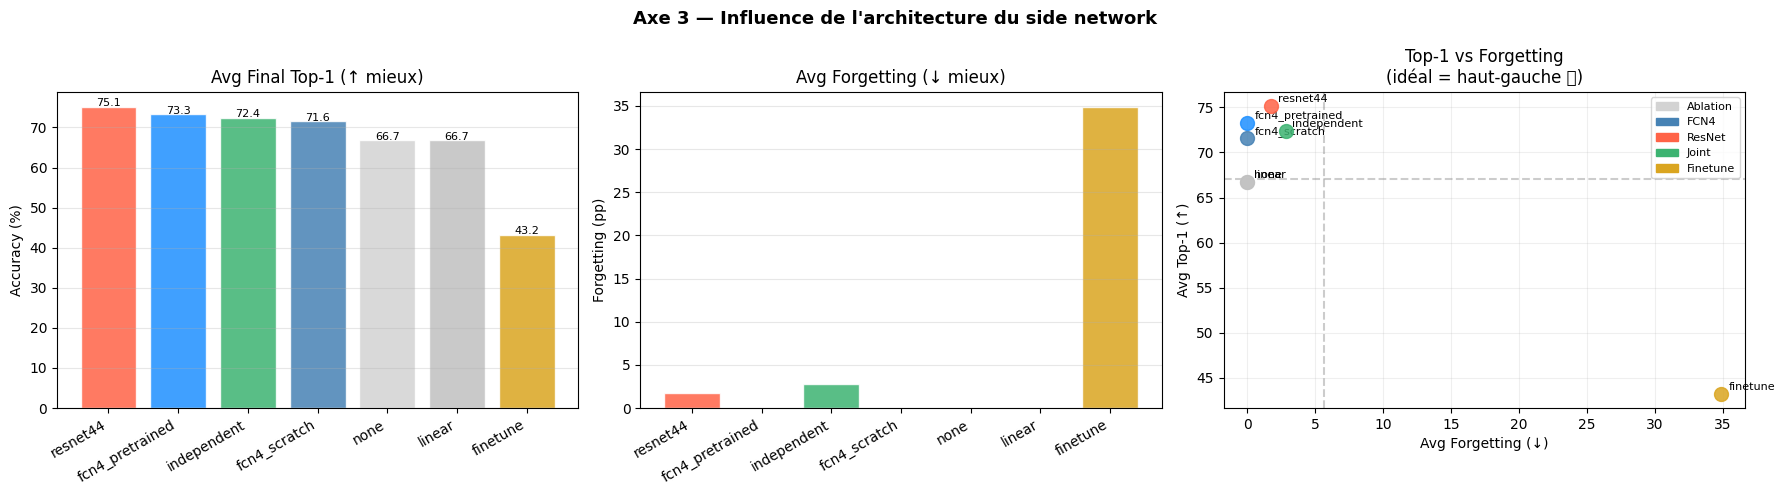

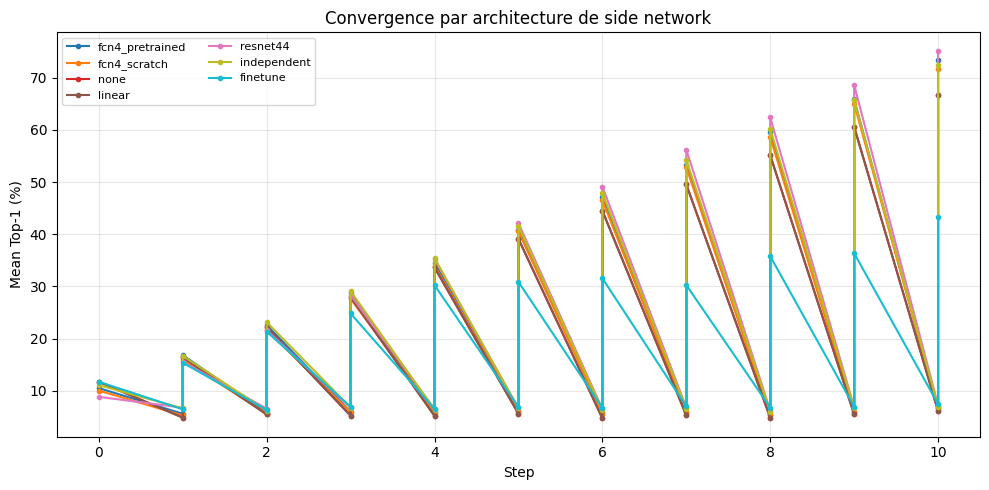

In [ ]:
# ============================================================
# Visualisations 
# ============================================================
def plot_side_comparison(summaries_side, experiments_side):

    # Catégories pour colorer
    categories = {
        "side_none":            ("Ablation",  "lightgray"),
        "side_linear":          ("Ablation",  "silver"),
        "side_fcn4_scratch":    ("FCN4",      "steelblue"),
        "side_fcn4_pretrained": ("FCN4",      "dodgerblue"),
        "side_resnet44":        ("ResNet",    "tomato"),
        "side_independent":     ("Joint",     "mediumseagreen"),
        "side_finetune":        ("Finetune",  "goldenrod"),
    }

    names  = list(summaries_side.keys())
    top1s  = [summaries_side[n].avg_top1      for n in names]
    fgs    = [summaries_side[n].avg_forgetting for n in names]
    colors = [categories.get(n, ("?", "gray"))[1] for n in names]

    order    = sorted(range(len(top1s)), key=lambda i: top1s[i], reverse=True)
    names_s  = [names[i]  for i in order]
    top1s_s  = [top1s[i]  for i in order]
    fgs_s    = [fgs[i]    for i in order]
    colors_s = [colors[i] for i in order]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle("Axe 3 — Influence de l'architecture du side network",
                 fontweight="bold", fontsize=13)

    # Barplot Top-1 
    x    = np.arange(len(names_s))
    bars = axes[0].bar(x, top1s_s, color=colors_s, alpha=0.85, edgecolor="white")
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(
        [n.replace("side_", "") for n in names_s], rotation=30, ha="right"
    )
    axes[0].set_title("Avg Final Top-1 (↑ mieux)")
    axes[0].set_ylabel("Accuracy (%)")
    axes[0].grid(axis="y", alpha=0.3)
    for bar, v in zip(bars, top1s_s):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                     f"{v:.1f}", ha="center", fontsize=8)

    # Barplot Forgetting 
    bars2 = axes[1].bar(x, fgs_s, color=colors_s, alpha=0.85, edgecolor="white")
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(
        [n.replace("side_", "") for n in names_s], rotation=30, ha="right"
    )
    axes[1].set_title("Avg Forgetting (↓ mieux)")
    axes[1].set_ylabel("Forgetting (pp)")
    axes[1].grid(axis="y", alpha=0.3)

    # Scatter Top-1 vs Forgetting 
    for i, name in enumerate(names):
        axes[2].scatter(fgs[i], top1s[i], color=colors[i], s=100, alpha=0.85, zorder=3)
        axes[2].annotate(
            name.replace("side_", ""),
            (fgs[i], top1s[i]),
            textcoords="offset points", xytext=(5, 3), fontsize=8
        )
    axes[2].axvline(np.mean(fgs),   color="gray", linestyle="--", alpha=0.4)
    axes[2].axhline(np.mean(top1s), color="gray", linestyle="--", alpha=0.4)
    axes[2].set_xlabel("Avg Forgetting (↓)")
    axes[2].set_ylabel("Avg Top-1 (↑)")
    axes[2].set_title("Top-1 vs Forgetting\n(idéal = haut-gauche ✅)")
    axes[2].grid(alpha=0.2)

    # Légende catégories
    seen = {}
    for n, (cat, col) in categories.items():
        if cat not in seen:
            seen[cat] = col
    legend = [mpatches.Patch(color=c, label=k) for k, c in seen.items()]
    axes[2].legend(handles=legend, fontsize=8)

    plt.tight_layout()
    plt.show()


def plot_side_histories(summaries_side):
    fig, ax = plt.subplots(figsize=(10, 5))
    colors = cm.tab10(np.linspace(0, 1, len(summaries_side)))

    for (name, s), color in zip(summaries_side.items(), colors):
        steps = [h["step"] for h in s.history]
        accs  = [h["top1"] for h in s.history]
        ax.plot(steps, accs, marker="o", markersize=3,
                color=color, label=name.replace("side_", ""), linewidth=1.5)

    ax.set_title("Convergence par architecture de side network")
    ax.set_xlabel("Step")
    ax.set_ylabel("Mean Top-1 (%)")
    ax.legend(fontsize=8, ncol=2)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_side_comparison(summaries_side, experiments_side)
plot_side_histories(summaries_side)

In [ ]:
# ============================================================
# Meilleur side network → réutilisé pour la suite
# ============================================================
best_side_name = max(summaries_side, key=lambda n: summaries_side[n].avg_top1)

print(f" Meilleur side network : {best_side_name}")
print(f"   avg_top1             : {summaries_side[best_side_name].avg_top1:.2f}%")
print(f"   avg_forgetting       : {summaries_side[best_side_name].avg_forgetting:.2f}%")

# Config complète idéale
print(f"\n{'='*50}")
print(f"  Config idéale complète :")
print(f"{'='*50}")
print(f"  optim  : {best_optim_name}")
print(f"     lr            = {experiments_optim[best_optim_name]['overrides'].get('cfg.learner.lr')}")
print(f"     optimizer     = {experiments_optim[best_optim_name]['overrides'].get('cfg.learner.optimizer_class')}")
print(f"     optimizer_kwargs = {experiments_optim[best_optim_name]['overrides'].get('cfg.learner.optimizer_kwargs')}")
print(f"  merge  : {best_merge_config}")
print(f"  side   : {best_side_name}")
print(f"{'='*50}")

# Overrides complets à réutiliser
best_full_overrides = {
    **best_optim_overrides,
    **{k: v for k, v in experiments_side[best_side_name]["overrides"].items()
       if k not in base_paths and k not in best_optim_overrides},
}
best_full_configs = experiments_side[best_side_name]["configs"]

print(f"\n→ best_full_configs  : {best_full_configs}")
print(f"→ best_full_overrides: {best_full_overrides}")

 Meilleur side network : side_resnet44
   avg_top1             : 75.14%
   avg_forgetting       : 1.75%

  Config idéale complète :
  optim  : adam_lr1e2
     lr            = 0.01
     optimizer     = optim.Adam
     optimizer_kwargs = {'weight_decay': 0.0}
  merge  : merge_mlp
  side   : side_resnet44

→ best_full_configs  : ['cifar_hp', 'icifar_data', 'model_lifelong_sidetune_double_resnet_cifar', 'merge_mlp']
→ best_full_overrides: {'cfg.learner.optimizer_class': 'optim.Adam', 'cfg.learner.lr': 0.01, 'cfg.learner.optimizer_kwargs': {'weight_decay': 0.0}}


### Partie 3 : Test sur un nouveau Dataset (FashionMnist)

In [44]:
# ============================================================
# Fashion-MNIST
# ============================================================
N_TASKS_FMNIST = 5   # 10 classes / 5 tâches = 2 classes par tâche

fmnist_targets = [[f'fmnist{i*2}-{i*2+1}'] for i in range(N_TASKS_FMNIST)]
fmnist_sources = [['rgb']] * N_TASKS_FMNIST

print("Targets Fashion-MNIST :", fmnist_targets)

experiments_fmnist = {
    "fmnist_sidetune": {
        "configs": ["cifar_hp", "icifar_data",                        # ← icifar_data manquait
                    "model_lifelong_sidetune_cifar", best_merge_config],
        "overrides": {
            "cfg.training.dataloader_fn":                            "fashion_mnist_dataset.get_dataloaders",
            "cfg.training.dataloader_fn_kwargs.data_path":           f"{HOME}/datasets/fmnist",
            "cfg.training.dataloader_fn_kwargs.epochlength":         10000,
            "cfg.training.dataloader_fn_kwargs.epochs_until_cycle":  0,
            "cfg.training.sources":                                   fmnist_sources,  # ← pas str()
            "cfg.training.targets":                                   fmnist_targets,  # ← pas str()
            "cfg.training.masks":                                     None,
            "cfg.training.num_epochs":                                N_TASKS_FMNIST,
            "cfg.training.task_is_classification":                    [True] * N_TASKS_FMNIST,  # ← pas str()
            "cfg.learner.model_kwargs.base_weights_path":             f"{REPO}/assets/pytorch/resnet44-cifar.pth",
            "cfg.learner.model_kwargs.side_weights_path":             f"{REPO}/assets/pytorch/distillation/fcn4-cifar.pth",
            "cfg.learner.model_kwargs.transfer_kwargs":               {"in_features": 64, "out_features": 2},
            **best_optim_overrides,
        }
    },

    "fmnist_finetune": {
        "configs": ["cifar_hp", "icifar_data",                        # ← icifar_data manquait
                    "model_lifelong_finetune_resnet44_cifar", best_merge_config],
        "overrides": {
            "cfg.training.dataloader_fn":                            "fashion_mnist_dataset.get_dataloaders",
            "cfg.training.dataloader_fn_kwargs.data_path":           f"{HOME}/datasets/fmnist",
            "cfg.training.dataloader_fn_kwargs.epochlength":         10000,
            "cfg.training.dataloader_fn_kwargs.epochs_until_cycle":  0,
            "cfg.training.sources":                                   fmnist_sources,
            "cfg.training.targets":                                   fmnist_targets,
            "cfg.training.masks":                                     None,
            "cfg.training.num_epochs":                                N_TASKS_FMNIST,
            "cfg.training.task_is_classification":                    [True] * N_TASKS_FMNIST,
            "cfg.learner.model_kwargs.base_weights_path":             f"{REPO}/assets/pytorch/resnet44-cifar.pth",
            "cfg.learner.model_kwargs.transfer_kwargs":               {"in_features": 64, "out_features": 2},
            **best_optim_overrides,
            
        }
    },
}

# Lancement
failed_fmnist = []
for name, exp in experiments_fmnist.items():
    try:
        runner.run(
            name,
            exp["configs"],
            exp["overrides"],
            output_dir=f"runs/fmnist/{name}",
        )
        print(f" {name}")
    except RuntimeError as e:
        print(f" {name} : {e}")
        failed_fmnist.append(name)

Targets Fashion-MNIST : [['fmnist0-1'], ['fmnist2-3'], ['fmnist4-5'], ['fmnist6-7'], ['fmnist8-9']]

  Experiment : fmnist_sidetune
  Output     : /users/eleves-b/2023/benjamin.wilhelm/side-tuning/runs/fmnist/fmnist_sidetune
  CMD        : /users/eleves-b/2023/benjamin.wilhelm/side-tuning/.venv/bin/python -m scripts.train_lifelong /users/eleves-b/2023/benjamin.wilhelm/side-tuning/runs/fmnist/fmnist_sidetune train with cifar_hp icifar_data model_lifelong_sidetune_cifar merge_mlp cfg.training.dataloader_fn=fashion_mnist_dataset.get_dataloaders cfg.training.dataloader_fn_kwargs.data_path=/users/eleves-b/2023/benjamin.wilhelm/datasets/fmnist cfg.training.dataloader_fn_kwargs.epochlength=10000 cfg.training.dataloader_fn_kwargs.epochs_until_cycle=0 cfg.training.sources=[['rgb'], ['rgb'], ['rgb'], ['rgb'], ['rgb']] cfg.training.targets=[['fmnist0-1'], ['fmnist2-3'], ['fmnist4-5'], ['fmnist6-7'], ['fmnist8-9']] cfg.training.masks=None cfg.training.num_epochs=5 cfg.training.task_is_classificati

In [ ]:
# ============================================================
# Extraction résultats Fashion-MNIST
# ============================================================
summaries_fmnist = {}

for name in experiments_fmnist:
    try:
        result_file = runner.find_result(f"runs/fmnist/{name}")
        summaries_fmnist[name] = ResultExtractor(result_file).load().extract()
        print(f" {name}")
    except FileNotFoundError:
        print(f" {name} — introuvable")

print(f"\n{len(summaries_fmnist)} résultats chargés.")

 fmnist_sidetune
 fmnist_finetune

2 résultats chargés.


  method  avg_top1 (%)  avg_forgetting (%)  n_tasks
sidetune         98.43                0.00        5
finetune         79.17               19.62        5


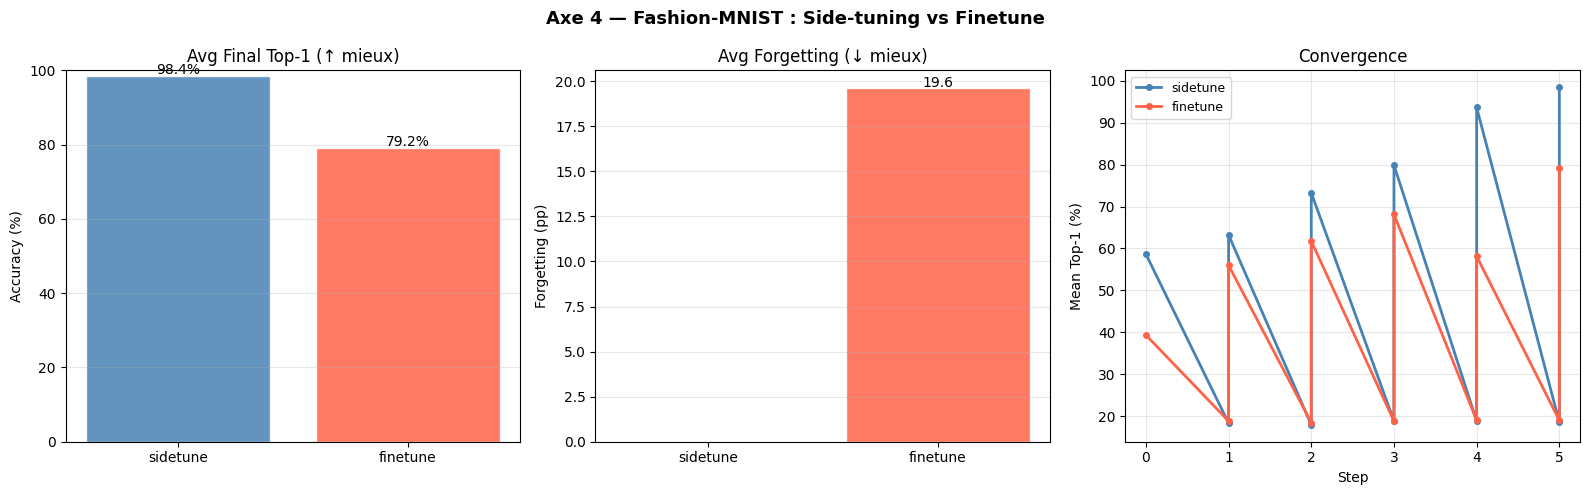

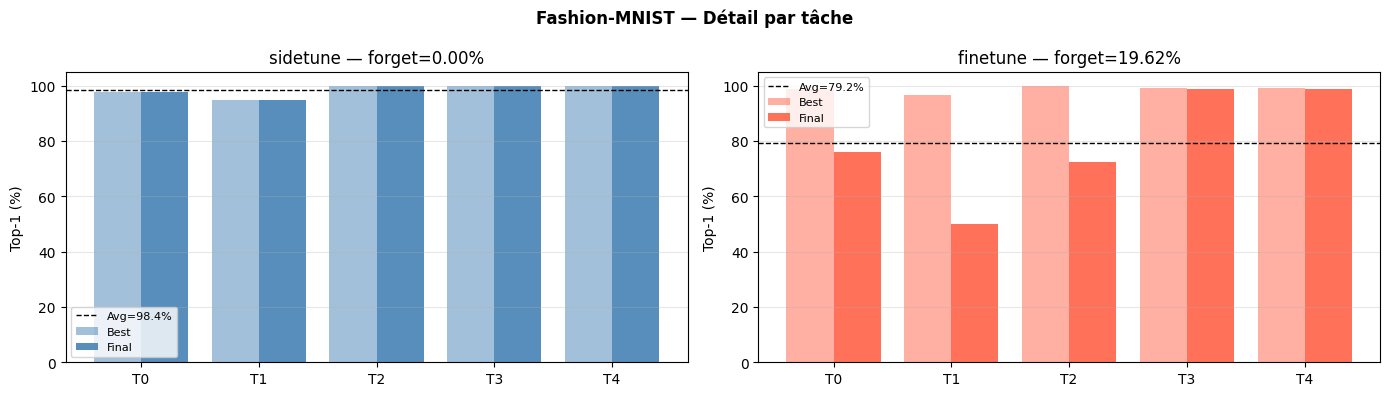


  Method : fmnist_sidetune
  Steps  : 11
   Task      Best     Final  Forgetting
  ---------------------------------------------
      0    97.60%    97.60%       0.00%
      1    94.95%    94.95%       0.00%
      2    99.90%    99.90%       0.00%
      3   100.00%   100.00%       0.00%
      4    99.70%    99.70%       0.00%
  ---------------------------------------------
    AVG              98.43%       0.00%


  Method : fmnist_finetune
  Steps  : 11
   Task      Best     Final  Forgetting
  ---------------------------------------------
      0    98.85%    75.85%      23.00% ⚠
      1    96.65%    50.00%      46.65% ⚠
      2   100.00%    72.40%      27.60% ⚠
      3    99.30%    98.85%       0.45%
      4    99.17%    98.75%       0.42%
  ---------------------------------------------
    AVG              79.17%      19.62%



In [49]:
# ============================================================
# Visualisations Fashion-MNIST
# ============================================================

viz = Visualizer()
def plot_fmnist_comparison(summaries_fmnist):

    names  = list(summaries_fmnist.keys())
    top1s  = [summaries_fmnist[n].avg_top1      for n in names]
    fgs    = [summaries_fmnist[n].avg_forgetting for n in names]

    color_map = {
        "fmnist_sidetune": "steelblue",
        "fmnist_finetune": "tomato",
    }
    colors = [color_map.get(n, "gray") for n in names]

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle("Axe 4 — Fashion-MNIST : Side-tuning vs Finetune",
                 fontweight="bold", fontsize=13)

    # ── Barplot Top-1 ──────────────────────────────────────
    x    = np.arange(len(names))
    bars = axes[0].bar(x, top1s, color=colors, alpha=0.85, edgecolor="white")
    axes[0].set_xticks(x)
    axes[0].set_xticklabels([n.replace("fmnist_", "") for n in names])
    axes[0].set_title("Avg Final Top-1 (↑ mieux)")
    axes[0].set_ylabel("Accuracy (%)")
    axes[0].set_ylim(0, 100)
    axes[0].grid(axis="y", alpha=0.3)
    for bar, v in zip(bars, top1s):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                     f"{v:.1f}%", ha="center", fontsize=10)

    # ── Barplot Forgetting ─────────────────────────────────
    bars2 = axes[1].bar(x, fgs, color=colors, alpha=0.85, edgecolor="white")
    axes[1].set_xticks(x)
    axes[1].set_xticklabels([n.replace("fmnist_", "") for n in names])
    axes[1].set_title("Avg Forgetting (↓ mieux)")
    axes[1].set_ylabel("Forgetting (pp)")
    axes[1].grid(axis="y", alpha=0.3)
    for bar, v in zip(bars2, fgs):
        if v > 0.05:
            axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                         f"{v:.1f}", ha="center", fontsize=10)

    # ── Courbes de convergence ─────────────────────────────
    for name, color in color_map.items():
        if name not in summaries_fmnist:
            continue
        s     = summaries_fmnist[name]
        steps = [h["step"] for h in s.history]
        accs  = [h["top1"] for h in s.history]
        axes[2].plot(steps, accs, marker="o", markersize=4,
                     color=color, label=name.replace("fmnist_", ""), linewidth=2)

    axes[2].set_title("Convergence")
    axes[2].set_xlabel("Step")
    axes[2].set_ylabel("Mean Top-1 (%)")
    axes[2].legend(fontsize=9)
    axes[2].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_fmnist_per_task(summaries_fmnist):
    """Accuracy et forgetting par tâche pour chaque méthode."""
    n_methods = len(summaries_fmnist)
    fig, axes = plt.subplots(1, n_methods, figsize=(7 * n_methods, 4), sharey=False)
    if n_methods == 1:
        axes = [axes]

    fig.suptitle("Fashion-MNIST — Détail par tâche", fontweight="bold")

    color_map = {"fmnist_sidetune": "steelblue", "fmnist_finetune": "tomato"}

    for ax, (name, s) in zip(axes, summaries_fmnist.items()):
        tids   = [m.task_id    for m in s.task_metrics]
        bests  = [m.best_top1  for m in s.task_metrics]
        finals = [m.final_top1 for m in s.task_metrics]
        x      = np.arange(len(tids))
        width  = 0.4
        color  = color_map.get(name, "gray")

        ax.bar(x - width/2, bests,  width, label="Best",  color=color,    alpha=0.5)
        ax.bar(x + width/2, finals, width, label="Final", color=color,    alpha=0.9)
        ax.axhline(s.avg_top1, color="black", linestyle="--", linewidth=1,
                   label=f"Avg={s.avg_top1:.1f}%")
        ax.set_xticks(x)
        ax.set_xticklabels([f"T{t}" for t in tids])
        ax.set_title(f"{name.replace('fmnist_', '')} — forget={s.avg_forgetting:.2f}%")
        ax.set_ylabel("Top-1 (%)")
        ax.legend(fontsize=8)
        ax.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()


# ── Tableau comparatif ─────────────────────────────────────
rows_fmnist = []
for name, s in summaries_fmnist.items():
    rows_fmnist.append({
        "method":             name.replace("fmnist_", ""),
        "avg_top1 (%)":       round(s.avg_top1, 2),
        "avg_forgetting (%)": round(s.avg_forgetting, 2),
        "n_tasks":            len(s.task_metrics),
    })

df_fmnist = pd.DataFrame(rows_fmnist).sort_values("avg_top1 (%)", ascending=False)
print(df_fmnist.to_string(index=False))

# ── Visualisations ─────────────────────────────────────────
plot_fmnist_comparison(summaries_fmnist)
plot_fmnist_per_task(summaries_fmnist)

# ── Print tables ───────────────────────────────────────────
for name, s in summaries_fmnist.items():
    viz.print_summary_table(s)

### Partie 4 : Test sur un nouveau dataset avec un fort shift de domaine (PCAM)

#### 📌 Note sur l'origine de cette section

Les tableaux et figures qui suivent sont issus d'expériences conduites **en local**
par un autre membre du groupe (Emile DRIJARD-MAZZINI), sur sa machine personnelle équipée d'un GPU.
Ils ont été intégrés dans ce notebook par le membre ayant créé le fichier `.ipynb`.

L'ensemble des scripts, résultats et ce notebook sont disponibles sur le dépôt GitHub du groupe :

> 🔗 **[github.com/edrijardmazzini/APM583_Group_COULON_DRIJARD-MAZZINI_BOURELLY_WILHELM_Project-Side-Tuning](https://github.com/edrijardmazzini/APM583_Group_COULON_DRIJARD-MAZZINI_BOURELLY_WILHELM_Project-Side-Tuning)**

#### 🗂️ Structure du dépôt GitHub

Le dépôt est basé sur le repo original du cours
([dataflowr/Project-side-tuning](https://github.com/dataflowr/Project-side-tuning))
auquel les éléments suivants ont été ajoutés :
```
side-tuning/
│
├── data/
│   └── pcam/                          ← Dataset PatchCamelyon (non versionné, à télécharger)
│       ├── training_split.h5          ← 262 144 images d'entraînement (images)
│       ├── validation_split.h5        ← 32 768 images de validation (images)
│       ├── test_split.h5              ← 32 768 images de test (images)
│       ├── camelyonpatch_level_2_split_train_y.h5   ← labels train
│       ├── camelyonpatch_level_2_split_valid_y.h5   ← labels validation
│       └── camelyonpatch_level_2_split_test_y.h5    ← labels test
│
├── scripts/                           ← Scripts ajoutés au repo de base
│   ├── demo_pcam.py                   ← Exp. 1 : 3 baselines (features / finetune / sidetune)
│   ├── demo_pcam_ablation.py          ← Exp. 2 : ablation side size / merge method / base network
│   ├── demo_pcam_ablation_all.py
│   ├── demo_pcam_optim.py             ← Exp. 3 : grille d'optimisation 3×3 (side size × epochs)
│   ├── demo_pcam_benchmark.py         ← Exp. 4 : benchmark 7 méthodes PEFT (20k train)
│   ├── demo_final.py                  ← Exp. 5 : benchmark final (50k train)
│   ├── generate_figures.py            ← Génération des figures du rapport LaTeX
│   ├── generate_figures_v2.py
│   ├── generate_figures_v3.py
│   ├── results_viewer.ipynb
│   └── results_viewer_v2.ipynb               ← Notebook pour créer voir les figures depuis 
│
├── results/                           ← Résultats JSON des expériences (ajoutés au repo)
│   ├── benchmark_results.json     ← Résultats Exp. 4 (7 méthodes, 20k)
│   ├── ablation_all.json          ← Résultats Exp. 2 (8 configurations)
│   ├── ablation_side_size.json
│   ├── tensorborads/
│   ├── final_log.txt
│   ├── optim_results.json         ← Résultats Exp. 3 (grille 3×3)
│   └── final_results.json             ← Résultats Exp. 5 (3 méthodes, 50k)
│
├── figures/                           ← Figures générées (PDF/PNG pour le rapport)
├── tlkit/
│   └── data/
│       └── datasets/
│           └── pcam_datasets.py
```

> ⚠️ Les fichiers `.h5` du dataset PCam ne sont **pas versionnés** sur GitHub en raison
> de leur taille (>1 Go). Ils sont à télécharger séparément depuis
> [Kaggle – PatchCamelyon](https://www.kaggle.com/c/histopathologic-cancer-detection/data)
> ou via l'API `tensorflow_datasets`.
> Les fichiers `.json` de résultats sont en revanche **directement disponibles** sur le repo.

In [1]:
import json
import pandas as pd
from pathlib import Path
from IPython.display import display, HTML

# ── Chemins ───────────────────────────────────────────────────────────────────
REPO_DIR    = Path(globals()['_dh'][0]).parent
RESULTS_DIR = REPO_DIR / 'scripts' / 'results'

JSON_FILES = {
    'benchmark': RESULTS_DIR / 'benchmark_results.json',
    'ablation':  RESULTS_DIR / 'ablation_all.json',
    'optim':     RESULTS_DIR / 'optim_results.json',
    'final':     RESULTS_DIR / 'final_results.json',
}

data = {}
for key, path in JSON_FILES.items():
    if path.exists():
        with open(path) as f:
            data[key] = json.load(f)
        print(f'  ✓  {key:<12}  {len(data[key])} entrées  →  {path}')
    else:
        print(f'  ✗  {key:<12}  non trouvé  →  {path}')

# ── Helper affichage ──────────────────────────────────────────────────────────
def fmt(df):
    df = df.copy()
    for c in ['val_acc','train_acc']:
        if c in df: df[c] = df[c].map(lambda x: f'{x:.2f}%')
    if 'val_loss' in df: df['val_loss'] = df['val_loss'].map(lambda x: f'{x:.4f}')
    if 'n_params' in df: df['n_params'] = df['n_params'].map(lambda x: f'{int(x):,}')
    if 'time'     in df: df['time']     = df['time'].map(lambda x: f'{int(x)}s')
    if 'alpha'    in df: df['alpha']    = df['alpha'].map(lambda x: f'{x:.3f}' if pd.notna(x) else '—')
    return df.style \
        .set_table_styles([{'selector':'th','props':'background:#f0f0f0;font-weight:bold;padding:6px 12px;'},
                           {'selector':'td','props':'padding:5px 12px;'},
                           {'selector':'tr:nth-child(even)','props':'background:#fafafa;'}]) \
        .hide(axis='index')

# ══════════════════════════════════════════════════════════════════════════════
# 1. BENCHMARK FINAL — Adapter vs Finetune vs Sidetune (50k, 10ep)
# ══════════════════════════════════════════════════════════════════════════════
display(HTML('<h3>① Benchmark Final — 50k train, 10 epochs</h3>'))
if 'final' in data:
    df = pd.DataFrame(data['final']).sort_values('val_acc', ascending=False)
    display(fmt(df[['method','val_acc','train_acc','val_loss','n_params','time']]))

# ══════════════════════════════════════════════════════════════════════════════
# 2. BENCHMARK 20k — 7 méthodes PEFT
# ══════════════════════════════════════════════════════════════════════════════
display(HTML('<h3>② Benchmark 7 méthodes — 20k train, 10 epochs</h3>'))
if 'benchmark' in data:
    df = pd.DataFrame(data['benchmark'])
    df['acc_per_M'] = (df['val_acc'] / (df['n_params'] / 1e6)).round(1)
    df = df.sort_values('val_acc', ascending=False)
    display(fmt(df[['method','val_acc','train_acc','val_loss','n_params','acc_per_M','time']]))

# ══════════════════════════════════════════════════════════════════════════════
# 3. ABLATION — side size / merge / base
# ══════════════════════════════════════════════════════════════════════════════
display(HTML('<h3>③ Ablation Side-Tuning — 20k train, 10 epochs</h3>'))
if 'ablation' in data:
    df   = pd.DataFrame(data['ablation']).sort_values('val_acc', ascending=False)
    cols = [c for c in ['name','val_acc','train_acc','val_loss','n_params','alpha','time'] if c in df]
    display(fmt(df[cols]))

# ══════════════════════════════════════════════════════════════════════════════
# 4. OPTIM — grille side_size × epochs (tableau + pivot coloré)
# ══════════════════════════════════════════════════════════════════════════════
display(HTML('<h3>④ Grille side_size × epochs — Base=RN50, Merge=MLP</h3>'))
if 'optim' in data:
    df = pd.DataFrame(data['optim']).sort_values('val_acc', ascending=False)
    display(fmt(df[['name','side','epochs','val_acc','train_acc','val_loss']]))
    display(HTML('<b>Pivot val_acc :</b>'))
    pivot = df.pivot(index='side', columns='epochs', values='val_acc').reindex(['small','medium','large'])
    pivot.columns = [f'{c} ep.' for c in pivot.columns]
    display(pivot.style.format('{:.2f}%').background_gradient(cmap='YlGn', axis=None)
                       .set_caption('Val Accuracy — RN50 + MLP'))

  ✓  benchmark     7 entrées  →  c:\Users\user\Desktop\3A\0 - P2\APM583 Deep Learning\Project_SIDE-TUNING\side-tuning\scripts\results\benchmark_results.json
  ✓  ablation      8 entrées  →  c:\Users\user\Desktop\3A\0 - P2\APM583 Deep Learning\Project_SIDE-TUNING\side-tuning\scripts\results\ablation_all.json
  ✓  optim         9 entrées  →  c:\Users\user\Desktop\3A\0 - P2\APM583 Deep Learning\Project_SIDE-TUNING\side-tuning\scripts\results\optim_results.json
  ✓  final         3 entrées  →  c:\Users\user\Desktop\3A\0 - P2\APM583 Deep Learning\Project_SIDE-TUNING\side-tuning\scripts\results\final_results.json


method,val_acc,train_acc,val_loss,n_params,time
adapter,88.40%,93.83%,0.0065,"507,394",1026s
finetune,87.55%,97.06%,0.0113,"23,512,130",1585s
sidetune,85.60%,90.70%,0.0070,"2,931,458",1129s


method,val_acc,train_acc,val_loss,n_params,acc_per_M,time
adapter,86.65%,92.62%,0.0064,"507,394",170.800000,313s
finetune,86.10%,95.85%,0.0119,"23,512,130",3.700000,441s
sidetune,82.65%,88.42%,0.0071,"2,931,458",28.200000,406s
bitfit,82.65%,85.83%,0.0067,"30,658",2695.900000,322s
prompt_tuning,81.65%,83.37%,0.0069,"672,770",121.400000,204s
lora,81.60%,81.89%,0.0071,"4,098",19912.200000,207s
features,80.85%,81.91%,0.0072,"4,098",19729.100000,221s


name,val_acc,train_acc,val_loss,n_params,alpha,time
merge_mlp,83.70%,85.55%,0.0064,"947,778",—,222s
base_rn50,82.50%,85.37%,0.0070,"1,209,411",0.258,278s
side_large,81.55%,87.45%,0.0085,"1,094,915",0.372,396s
merge_product,81.30%,84.71%,0.0066,"160,322",—,217s
base_rn18,81.15%,84.43%,0.0073,"160,323",0.359,221s
side_small,79.30%,83.55%,0.0073,"53,699",0.380,217s
merge_alpha,78.70%,84.32%,0.0081,"160,323",0.397,225s
side_medium,77.05%,84.08%,0.0083,"160,323",0.370,216s


name,side,epochs,val_acc,train_acc,val_loss
rn50_mlp_large_ep10,large,10,85.90%,87.69%,0.0060
rn50_mlp_medium_ep05,medium,5,83.20%,84.12%,0.0075
rn50_mlp_medium_ep10,medium,10,83.00%,85.86%,0.0071
rn50_mlp_medium_ep20,medium,20,82.40%,88.09%,0.0075
rn50_mlp_small_ep05,small,5,81.40%,83.94%,0.0077
rn50_mlp_small_ep20,small,20,80.05%,87.41%,0.0088
rn50_mlp_large_ep05,large,5,79.75%,86.08%,0.0077
rn50_mlp_small_ep10,small,10,79.30%,85.57%,0.0091
rn50_mlp_large_ep20,large,20,79.00%,89.93%,0.0116


,5 ep.,10 ep.,20 ep.
side,,,
small,81.40%,79.30%,80.05%
medium,83.20%,83.00%,82.40%
large,79.75%,85.90%,79.00%


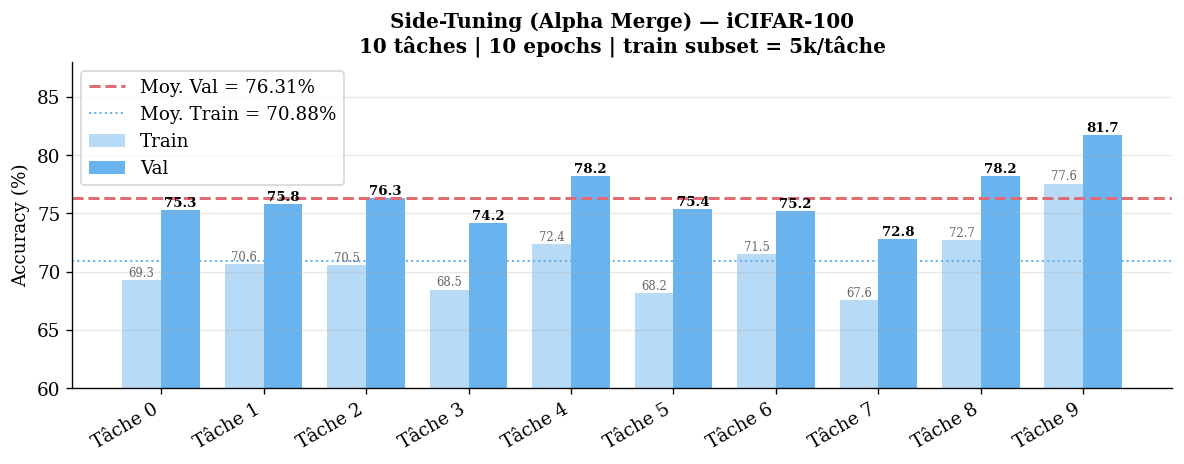

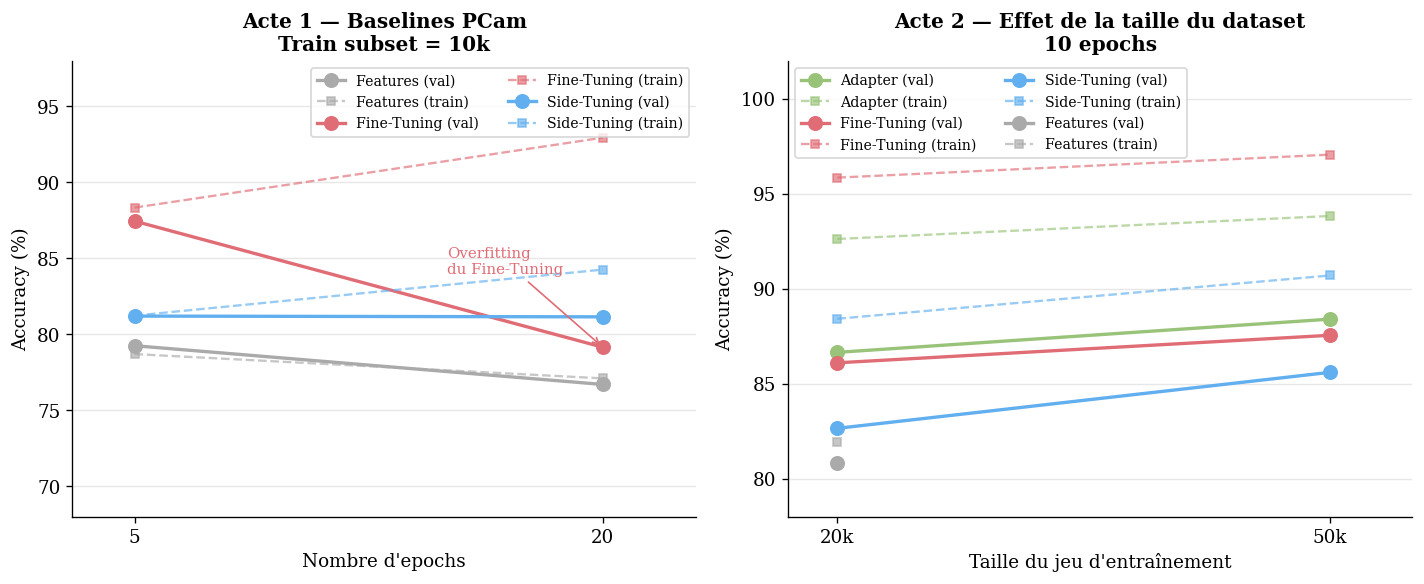

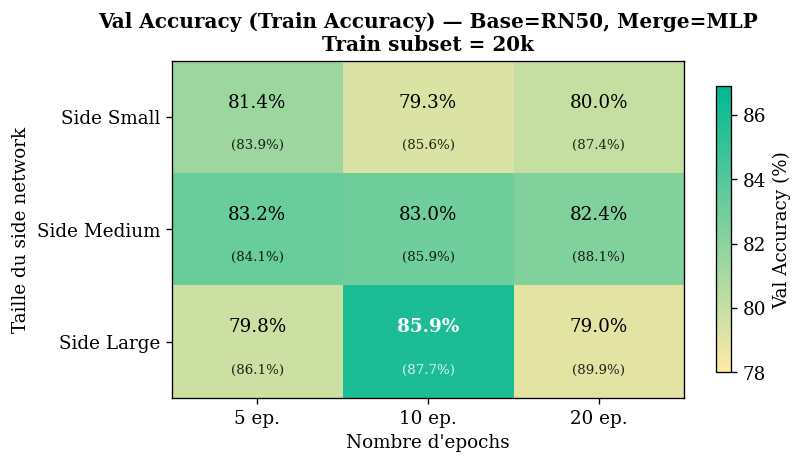

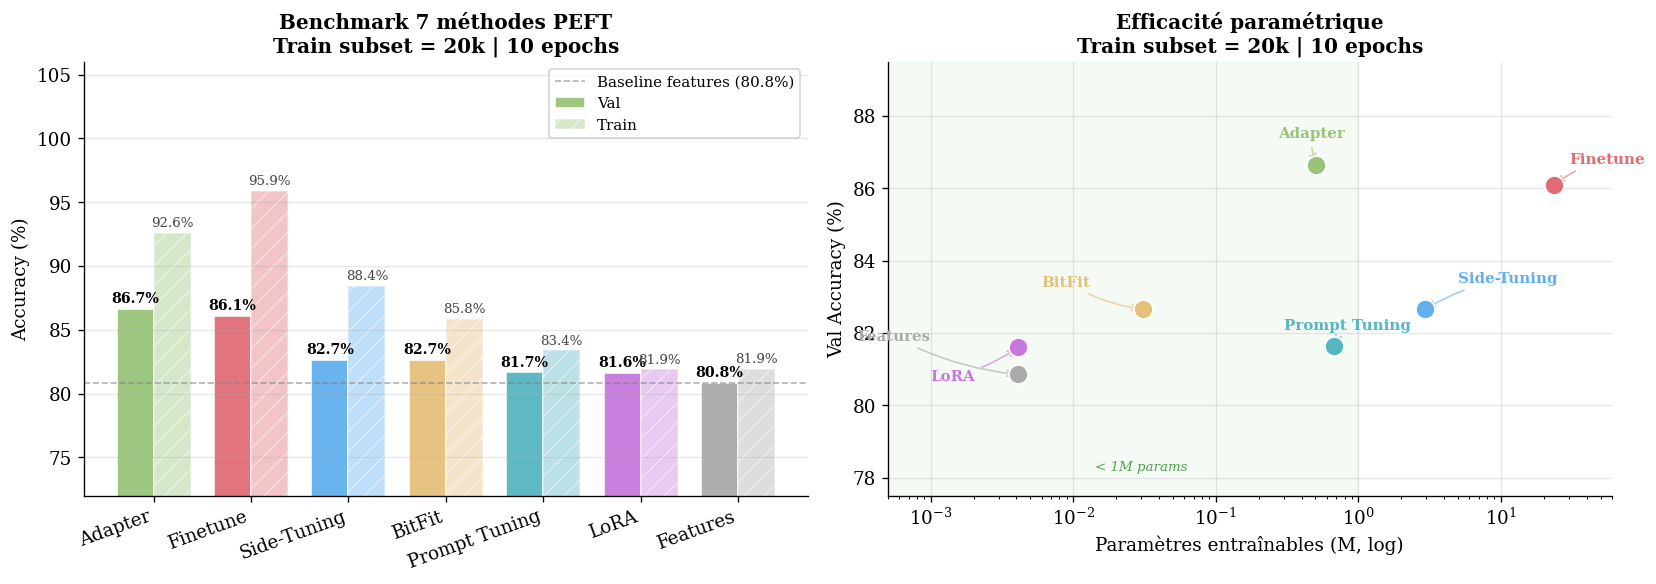

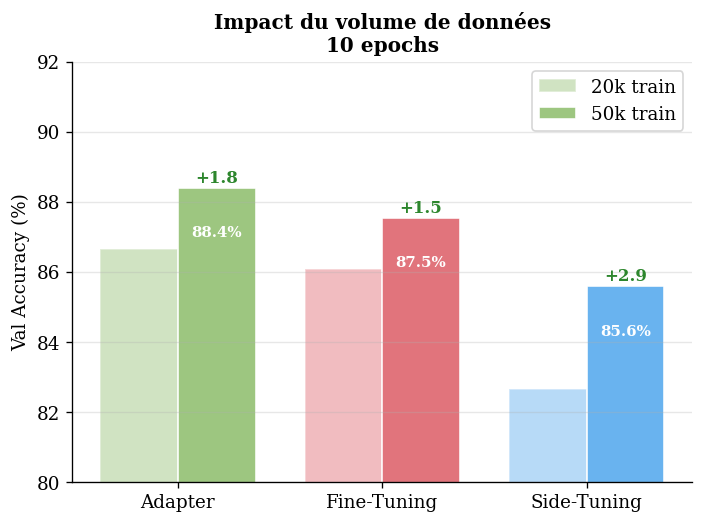

In [2]:
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import numpy as np

%matplotlib inline
matplotlib.rcParams.update({'font.family':'serif','font.size':11,'axes.titlesize':12,'figure.dpi':120})

COLORS = {
    'features':'#aaaaaa','Features':'#aaaaaa',
    'finetune':'#e06c75','Finetune':'#e06c75','Fine-Tuning':'#e06c75',
    'sidetune':'#61afef','Side-Tuning':'#61afef',
    'adapter':'#98c379','Adapter':'#98c379',
    'lora':'#c678dd','LoRA':'#c678dd',
    'bitfit':'#e5c07b','BitFit':'#e5c07b',
    'prompt_tuning':'#56b6c2','Prompt Tuning':'#56b6c2',
}

def clean(ax):
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    ax.grid(True, axis='y', alpha=0.3)

# ── Données (JSON si dispo, sinon fallback) ───────────────────────────────────
LABEL_MAP = {
    'features':'Features','finetune':'Finetune','sidetune':'Side-Tuning',
    'adapter':'Adapter','lora':'LoRA','bitfit':'BitFit','prompt_tuning':'Prompt Tuning',
}

bench_20k = sorted(data.get('benchmark', [
    {'method':'Adapter',      'val_acc':86.65,'train_acc':92.62,'val_loss':0.0064,'n_params':507394},
    {'method':'Finetune',     'val_acc':86.10,'train_acc':95.85,'val_loss':0.0119,'n_params':23512130},
    {'method':'Side-Tuning',  'val_acc':82.65,'train_acc':88.42,'val_loss':0.0071,'n_params':2931458},
    {'method':'BitFit',       'val_acc':82.65,'train_acc':85.83,'val_loss':0.0067,'n_params':30658},
    {'method':'Prompt Tuning','val_acc':81.65,'train_acc':83.37,'val_loss':0.0069,'n_params':672770},
    {'method':'LoRA',         'val_acc':81.60,'train_acc':81.89,'val_loss':0.0071,'n_params':4098},
    {'method':'Features',     'val_acc':80.85,'train_acc':81.91,'val_loss':0.0072,'n_params':4098},
]), key=lambda x: x['val_acc'], reverse=True)
# Normaliser les noms de méthodes (le JSON peut utiliser des casses variées)
bench_20k = [{**d, 'method': LABEL_MAP.get(d['method'].lower(), d['method'])} for d in bench_20k]

bench_final = data.get('final', [
    {'method':'Adapter',    'val_acc':88.40,'train_acc':93.83},
    {'method':'Finetune',   'val_acc':87.55,'train_acc':97.06},
    {'method':'Side-Tuning','val_acc':85.60,'train_acc':90.70},
])
bench_final = [{**d, 'method': LABEL_MAP.get(d['method'].lower(), d['method'])} for d in bench_final]

ICIFAR = {
    'train':[69.28,70.62,70.54,68.47,72.36,68.20,71.48,67.60,72.70,77.57],
    'val':  [75.30,75.80,76.30,74.20,78.20,75.40,75.20,72.80,78.20,81.70],
    'avg':  76.31, 'avg_train': 70.88
}

# Acte 1 : seulement 5 et 20 epochs (pas de run à 10ep)
ACT1 = {
    'epochs':         [5,     20],
    'features_val':   [79.25, 76.70], 'features_train': [78.70, 77.10],
    'finetune_val':   [87.45, 79.15], 'finetune_train': [88.34, 92.94],
    'sidetune_val':   [81.20, 81.15], 'sidetune_train': [81.23, 84.26],
}

ACT2 = {
    'sizes':          [20000,  50000],
    'adapter_val':    [86.65,  88.40], 'adapter_train':   [92.62, 93.83],
    'finetune_val':   [86.10,  87.55], 'finetune_train':  [95.85, 97.06],
    'sidetune_val':   [82.65,  85.60], 'sidetune_train':  [88.42, 90.70],
    'features_val':   [80.85,  None],  'features_train':  [81.91, None],
}

HEATMAP_VAL   = np.array([[81.40,79.30,80.05],[83.20,83.00,82.40],[79.75,85.90,79.00]])
HEATMAP_TRAIN = np.array([[82.10,81.45,83.20],[84.30,85.70,86.10],[81.20,87.69,89.93]])

# ══════════════════════════════════════════════════════════════════════════════
# Fig A — iCIFAR par tâche (10 tâches | 10 epochs | train subset = 5k/tâche)
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(10, 4))
x, w = np.arange(10), 0.38
ax.bar(x-w/2, ICIFAR['train'], w, color='#61afef', alpha=0.45, label='Train')
ax.bar(x+w/2, ICIFAR['val'],   w, color='#61afef', alpha=0.95, label='Val')
ax.axhline(ICIFAR['avg'],       color='#e06c75', ls='--', lw=1.8,
           label=f"Moy. Val = {ICIFAR['avg']:.2f}%")
ax.axhline(ICIFAR['avg_train'], color='#61afef', ls=':',  lw=1.2,
           label=f"Moy. Train = {ICIFAR['avg_train']:.2f}%")
for i,(tr,va) in enumerate(zip(ICIFAR['train'],ICIFAR['val'])):
    ax.text(i-w/2, tr+.3, f'{tr:.1f}', ha='center', fontsize=7, color='#666')
    ax.text(i+w/2, va+.3, f'{va:.1f}', ha='center', fontsize=8, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels([f'Tâche {i}' for i in range(10)], rotation=30, ha='right')
ax.set_ylabel('Accuracy (%)'); ax.set_ylim(60, 88)
ax.set_title('Side-Tuning (Alpha Merge) — iCIFAR-100\n'
             '10 tâches | 10 epochs | train subset = 5k/tâche', fontweight='bold')
ax.legend(); clean(ax); plt.tight_layout(); plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# Fig B — Val + Train accuracy vs epochs (gauche) et vs data size (droite)
# Corrections : train_acc ajoutée, seulement 5 et 20 epochs (pas de 10ep)
# ══════════════════════════════════════════════════════════════════════════════
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Gauche : val + train vs epochs (10k, 5 et 20 ep seulement)
ep_configs = [
    ('Features',    '#aaaaaa', ACT1['features_val'],  ACT1['features_train']),
    ('Fine-Tuning', '#e06c75', ACT1['finetune_val'],  ACT1['finetune_train']),
    ('Side-Tuning', '#61afef', ACT1['sidetune_val'],  ACT1['sidetune_train']),
]
for label, c, vv, vt in ep_configs:
    ax1.plot(ACT1['epochs'], vv, 'o-',  color=c, lw=2,   ms=8, label=f'{label} (val)')
    ax1.plot(ACT1['epochs'], vt, 's--', color=c, lw=1.4, ms=5, alpha=0.65, label=f'{label} (train)')

ax1.annotate('Overfitting\ndu Fine-Tuning',
             xy=(20, ACT1['finetune_val'][-1]), xytext=(15, 84),
             arrowprops=dict(arrowstyle='->', color='#e06c75'),
             color='#e06c75', fontsize=9)
ax1.set_xlabel("Nombre d'epochs"); ax1.set_ylabel('Accuracy (%)')
# Epochs sur axe X → train_subset dans le titre
ax1.set_title("Acte 1 — Baselines PCam\nTrain subset = 10k", fontweight='bold')
ax1.set_xticks(ACT1['epochs']); ax1.set_xlim(3, 23); ax1.set_ylim(68, 98)
ax1.legend(ncol=2, fontsize=8.5); clean(ax1)

# Droite : val + train vs data size (10 epochs)
sz_configs = [
    ('Adapter',     '#98c379', ACT2['adapter_val'],  ACT2['adapter_train']),
    ('Fine-Tuning', '#e06c75', ACT2['finetune_val'], ACT2['finetune_train']),
    ('Side-Tuning', '#61afef', ACT2['sidetune_val'], ACT2['sidetune_train']),
    ('Features',    '#aaaaaa', ACT2['features_val'],  ACT2['features_train']),
]
sizes = ACT2['sizes']
for label, c, vv, vt in sz_configs:
    sv = [s for s,v in zip(sizes,vv) if v is not None]
    yv = [v for v in vv if v is not None]
    st = [s for s,v in zip(sizes,vt) if v is not None]
    yt = [v for v in vt if v is not None]
    ax2.plot(sv, yv, 'o-',  color=c, lw=2,   ms=8, label=f'{label} (val)')
    ax2.plot(st, yt, 's--', color=c, lw=1.4, ms=5, alpha=0.65, label=f'{label} (train)')

# Data size sur axe X → epochs dans le titre
ax2.set_xlabel("Taille du jeu d'entraînement"); ax2.set_ylabel('Accuracy (%)')
ax2.set_title("Acte 2 — Effet de la taille du dataset\n10 epochs", fontweight='bold')
ax2.set_xticks(sizes); ax2.set_xticklabels(['20k','50k'])
ax2.set_xlim(17000, 55000); ax2.set_ylim(78, 102)
ax2.legend(ncol=2, fontsize=8.5); clean(ax2)

plt.tight_layout(); plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# Fig C — Heatmap side_size × epochs
# Correction : affiche val_acc + (train_acc) dans chaque cellule
# ══════════════════════════════════════════════════════════════════════════════
if 'optim' in data:
    import pandas as pd
    df_opt     = pd.DataFrame(data['optim'])
    sides      = ['small','medium','large']
    ep_lbl     = sorted(df_opt['epochs'].unique())
    val_grid   = df_opt.pivot(index='side',columns='epochs',values='val_acc').reindex(sides).values
    train_grid = df_opt.pivot(index='side',columns='epochs',values='train_acc').reindex(sides).values
else:
    val_grid   = HEATMAP_VAL
    train_grid = HEATMAP_TRAIN
    ep_lbl     = [5, 10, 20]

fig, ax = plt.subplots(figsize=(7, 4))
cmap = LinearSegmentedColormap.from_list('g', ['#ffeaa7','#00b894'])
im = ax.imshow(val_grid, cmap=cmap, aspect='auto', vmin=val_grid.min()-1, vmax=val_grid.max()+1)
ax.set_xticks(range(len(ep_lbl))); ax.set_xticklabels([f'{e} ep.' for e in ep_lbl])
ax.set_yticks(range(3));           ax.set_yticklabels(['Side Small','Side Medium','Side Large'])
ax.set_xlabel("Nombre d'epochs"); ax.set_ylabel("Taille du side network")
# Titre : train_subset et config fixée (ni epochs ni side sur cet axe double)
ax.set_title("Val Accuracy (Train Accuracy) — Base=RN50, Merge=MLP\n"
             "Train subset = 20k", fontweight='bold')
vm = np.unravel_index(val_grid.argmax(), val_grid.shape)
for i in range(3):
    for j in range(len(ep_lbl)):
        is_best = (i,j) == vm
        clr     = 'white' if is_best else 'black'
        wgt     = 'bold'  if is_best else 'normal'
        # Ligne 1 : val_acc (grand)
        ax.text(j, i - 0.13, f'{val_grid[i,j]:.1f}%',
                ha='center', va='center', color=clr, fontweight=wgt, fontsize=11)
        # Ligne 2 : (train_acc) en dessous, plus petit
        ax.text(j, i + 0.25, f'({train_grid[i,j]:.1f}%)',
                ha='center', va='center', color=clr, fontsize=8, alpha=0.85)
plt.colorbar(im, ax=ax, label='Val Accuracy (%)', shrink=0.85)
plt.tight_layout(); plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# Fig D — Bar chart 7 méthodes + Scatter params vs acc
# Corrections : val en gras, train en normal (#444) | titre avec subset+epochs
# ══════════════════════════════════════════════════════════════════════════════
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

methods    = [d['method']    for d in bench_20k]
val_accs   = [d['val_acc']   for d in bench_20k]
train_accs = [d['train_acc'] for d in bench_20k]
cols       = [COLORS.get(m,'#888') for m in methods]
x, w = np.arange(len(methods)), 0.38

bars_v = ax1.bar(x-w/2, val_accs,   w, color=cols, alpha=0.95, label='Val',   edgecolor='white')
bars_t = ax1.bar(x+w/2, train_accs, w, color=cols, alpha=0.40, label='Train', edgecolor='white', hatch='//')

# Val : étiquettes en gras
for bar, v in zip(bars_v, val_accs):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.25,
             f'{v:.1f}%', ha='center', va='bottom', fontsize=8.5, fontweight='bold')
# Train : étiquettes normales, couleur plus discrète
for bar, v in zip(bars_t, train_accs):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.25,
             f'{v:.1f}%', ha='center', va='bottom', fontsize=8, fontweight='normal',
             color='#444444')

features_acc = next((d['val_acc'] for d in bench_20k
                     if d['method'].lower() in ('features','feature')), 80.85)
ax1.axhline(features_acc, color='gray', ls='--', lw=1, alpha=0.6,
            label=f'Baseline features ({features_acc:.1f}%)')
ax1.set_xticks(x); ax1.set_xticklabels(methods, rotation=20, ha='right')
ax1.set_ylabel('Accuracy (%)'); ax1.set_ylim(72, 106)
ax1.set_title('Benchmark 7 méthodes PEFT\nTrain subset = 20k | 10 epochs', fontweight='bold')
ax1.legend(fontsize=9); clean(ax1)

# Scatter : labels positionnés hors du nuage pour éviter les chevauchements
label_pos = {
    'Adapter':       (0.8,   87.5,  'right'),
    'Finetune':      (30.0,  86.8,  'left'),
    'Side-Tuning':   (5.0,   83.5,  'left'),
    'BitFit':        (0.006, 83.4,  'left'),
    'Prompt Tuning': (0.3,   82.2,  'left'),
    'LoRA':          (0.001, 80.8,  'left'),
    'Features':      (0.001, 81.9,  'right'),
}
for d in bench_20k:
    xp, c = d['n_params']/1e6, COLORS.get(d['method'],'#888')
    ax2.scatter(xp, d['val_acc'], s=130, color=c, zorder=5, edgecolors='white', lw=1)
    xt, yt, ha = label_pos.get(d['method'], (xp*2, d['val_acc']+0.3, 'left'))
    ax2.annotate(d['method'], xy=(xp, d['val_acc']), xytext=(xt, yt),
                 ha=ha, va='center', fontsize=9, color=c, fontweight='bold',
                 arrowprops=dict(arrowstyle='->', color=c, alpha=0.6, lw=1.0,
                                 connectionstyle='arc3,rad=0.1'))

ax2.axvspan(1e-4, 1.0, alpha=0.04, color='green')
ax2.text(0.03, 78.2, '< 1M params', ha='center', fontsize=8,
         color='green', alpha=0.7, style='italic')
ax2.set_xscale('log')
ax2.set_xlabel('Paramètres entraînables (M, log)'); ax2.set_ylabel('Val Accuracy (%)')
ax2.set_title('Efficacité paramétrique\nTrain subset = 20k | 10 epochs', fontweight='bold')
ax2.set_ylim(77.5, 89.5); ax2.set_xlim(5e-4, 60)
ax2.grid(True, alpha=0.3)
ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)

plt.tight_layout(); plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# Fig E — 20k vs 50k (3 meilleures méthodes)
# ══════════════════════════════════════════════════════════════════════════════
d20 = {d['method']:d['val_acc'] for d in bench_20k}
d50 = {d['method']:d['val_acc'] for d in bench_final}
labels_f = ['Adapter','Finetune','Side-Tuning']
a20 = [d20.get(m, 0) for m in labels_f]
a50 = [d50.get(m, 0) for m in labels_f]
cols_f = ['#98c379','#e06c75','#61afef']
display_labels = ['Adapter','Fine-Tuning','Side-Tuning']

fig, ax = plt.subplots(figsize=(6, 4.5))
x, w = np.arange(3), 0.38
ax.bar(x-w/2, a20, w, color=cols_f, alpha=0.45, label='20k train', edgecolor='white')
bars = ax.bar(x+w/2, a50, w, color=cols_f, alpha=0.95, label='50k train', edgecolor='white')
for bar, v20, v50 in zip(bars, a20, a50):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+.15,
            f'+{v50-v20:.1f}', ha='center', fontsize=10, color='#2d862d', fontweight='bold')
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()-1.4,
            f'{v50:.1f}%', ha='center', fontsize=9, color='white', fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(display_labels)
ax.set_ylabel('Val Accuracy (%)'); ax.set_ylim(80, 92)
ax.set_title('Impact du volume de données\n10 epochs', fontweight='bold')
ax.legend(); clean(ax); plt.tight_layout(); plt.show()


---
#### 📄 Code source des scripts — Expériences PCam

Les cellules suivantes présentent le code source complet de chaque script utilisé pour produire les résultats ci-dessus.
Tous ces fichiers sont disponibles dans le dépôt GitHub du groupe :

> 🔗 **[github.com/edrijardmazzini/APM583_Group_COULON_DRIJARD-MAZZINI_BOURELLY_WILHELM_Project-Side-Tuning](https://github.com/edrijardmazzini/APM583_Group_COULON_DRIJARD-MAZZINI_BOURELLY_WILHELM_Project-Side-Tuning)**

##### `tlkit/data/datasets/pcam_datasets.py` — Dataset loader PCam

Charge les fichiers `.h5` en RAM et expose un `torch.Dataset`. Contient la normalisation ImageNet et les augmentations train/val.

```python
# tlkit/data/datasets/pcam_datasets.py

import h5py
import numpy as np
import torch
from torch.utils.data import Dataset
import torchvision.transforms as transforms


class PCAMDataset(Dataset):
    """
    PatchCamelyon Dataset - images médicales 96x96 RGB
    Labels: 0 = tissu sain, 1 = métastase

    Les données sont chargées entièrement en mémoire numpy dans __init__
    pour éviter l'erreur "h5py objects cannot be pickled" sur Windows
    avec num_workers > 0.
    """
    def __init__(self, x_path, y_path, transform=None):
        self.transform = transform

        # Charge tout en RAM — évite les problèmes de pickle h5py
        with h5py.File(x_path, 'r') as fx:
            x_key = list(fx.keys())[0]
            self.data = fx[x_key][:]          # numpy array (N, 96, 96, 3) uint8

        with h5py.File(y_path, 'r') as fy:
            y_key = list(fy.keys())[0]
            self.labels = fy[y_key][:].squeeze().astype(np.int64)  # (N,)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        image = self.data[idx]               # (96, 96, 3) numpy uint8
        label = int(self.labels[idx].flatten()[0]) if self.labels[idx].ndim > 0 else int(self.labels[idx])
        if self.transform:
            image = self.transform(image)
        return image, label


def get_pcam_datasets(data_dir):
    """
    Retourne (train_dataset, val_dataset, test_dataset).

    Structure attendue dans data_dir :
        training_split.h5
        validation_split.h5
        test_split.h5
        camelyonpatch_level_2_split_train_y.h5
        camelyonpatch_level_2_split_valid_y.h5
        camelyonpatch_level_2_split_test_y.h5
    """
    transform_train = transforms.Compose([
        transforms.ToPILImage(),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        ),
    ])
    transform_eval = transforms.Compose([
        transforms.ToPILImage(),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        ),
    ])

    train_dataset = PCAMDataset(
        x_path=f'{data_dir}/training_split.h5',
        y_path=f'{data_dir}/camelyonpatch_level_2_split_train_y.h5',
        transform=transform_train
    )
    val_dataset = PCAMDataset(
        x_path=f'{data_dir}/validation_split.h5',
        y_path=f'{data_dir}/camelyonpatch_level_2_split_valid_y.h5',
        transform=transform_eval
    )
    test_dataset = PCAMDataset(
        x_path=f'{data_dir}/test_split.h5',
        y_path=f'{data_dir}/camelyonpatch_level_2_split_test_y.h5',
        transform=transform_eval
    )

    return train_dataset, val_dataset, test_dataset
```

##### `scripts/demo_pcam.py` — Expérience 1 — Baselines

Compare 3 méthodes (features / finetune / sidetune) sur 10k–50k images. Point de départ de toute la section PCam.

```python
"""
demo_pcam.py  —  Side-Tuning on PatchCamelyon (PCam)
Binary classification: 0 = healthy tissue, 1 = metastatic tissue

Structure calquée sur demo_icifar.py (même boucle, même logging tnt).
On implémente directement le réseau side-tuning sans passer par
LifelongSidetuneNetwork (qui utilise eval() incompatible avec nos classes custom).

Comparaison de 3 méthodes :
  - features  : ResNet-18 gelé + tête linéaire (baseline naïve)
  - finetune  : ResNet-18 entièrement entraînable (baseline forte)
  - sidetune  : Base gelée + side network + alpha-blending (notre méthode)

Usage:
    python -m scripts.demo_pcam
    python -m scripts.demo_pcam --method sidetune
    python -m scripts.demo_pcam --method features
    python -m scripts.demo_pcam --method finetune
    python -m scripts.demo_pcam --epochs 20 --train_subset 50000
"""

import os
import argparse
import numpy as np
import time
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as tv_models

from tlkit.data.datasets.pcam_datasets import get_pcam_datasets
import tnt.torchnet as tnt

# ── Config ────────────────────────────────────────────────────────────────────

PCAM_DATA_DIR = os.path.join(os.path.dirname(__file__), '..', 'data', 'pcam')
LOG_DIR       = '/tmp/pcam_demo/tensorboards'
SAVE_DIR      = '/tmp/pcam_demo'

BATCH_SIZE    = 64
NUM_EPOCHS    = 20
LR            = 1e-3
TRAIN_SUBSET  = 10000   # None = dataset complet (262k)
VAL_SUBSET    = 2000    # None = dataset complet (32k)

# ── Args ──────────────────────────────────────────────────────────────────────

parser = argparse.ArgumentParser()
parser.add_argument('--method', type=str, default='all',
                    choices=['sidetune', 'features', 'finetune', 'all'])
parser.add_argument('--epochs',       type=int, default=NUM_EPOCHS)
parser.add_argument('--train_subset', type=int, default=TRAIN_SUBSET)
args, _ = parser.parse_known_args()
NUM_EPOCHS   = args.epochs
TRAIN_SUBSET = args.train_subset

# ── Device ────────────────────────────────────────────────────────────────────

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Training on device:', device)


# ═══════════════════════════════════════════════════════════════════════════════
#  Modèles — même logique que LifelongSidetuneNetwork mais sans eval()
# ═══════════════════════════════════════════════════════════════════════════════

class FeatureExtractionPCam(nn.Module):
    """
    FEATURES — baseline naïve.
    ResNet-18 ImageNet complètement gelé + classifieur linéaire.
    Équivalent à merge_operators.BaseOnly dans le framework.
    """
    def __init__(self):
        super().__init__()
        base = tv_models.resnet18(weights=tv_models.ResNet18_Weights.DEFAULT)
        self.encoder = nn.Sequential(*list(base.children())[:-1])  # (B,512,1,1)
        for p in self.encoder.parameters():
            p.requires_grad = False
        self.transfer = nn.Linear(512, 2)   # = transfer_class dans le framework

    def forward(self, x, task_idx=None):
        with torch.no_grad():
            f = self.encoder(x).flatten(1)  # (B, 512)
        return self.transfer(f)


class FineTunePCam(nn.Module):
    """
    FINETUNE — baseline forte.
    ResNet-18 entièrement entraînable.
    Équivalent à merge_operators.SideOnly dans le framework.
    """
    def __init__(self):
        super().__init__()
        base = tv_models.resnet18(weights=tv_models.ResNet18_Weights.DEFAULT)
        self.encoder = nn.Sequential(*list(base.children())[:-1])  # (B,512,1,1)
        self.transfer = nn.Linear(512, 2)

    def forward(self, x, task_idx=None):
        f = self.encoder(x).flatten(1)  # (B, 512)
        return self.transfer(f)


class SideTunePCam(nn.Module):
    """
    SIDETUNE — notre méthode.
    Implémente T( alpha*B(x) + (1-alpha)*S(x) ) exactement comme
    LifelongSidetuneNetwork avec merge_operators.Alpha.

      B(x) = ResNet-18 ImageNet, gelé          (= base dans le framework)
      S(x) = petit CNN entraînable              (= side dans le framework)
      alpha = paramètre scalaire appris         (= merge_operators.Alpha.param)
      T(·) = nn.Linear(512, 2)                 (= transfer dans le framework)
    """
    def __init__(self):
        super().__init__()

        # Base (frozen) — ResNet-18 ImageNet
        base = tv_models.resnet18(weights=tv_models.ResNet18_Weights.DEFAULT)
        self.base = nn.Sequential(*list(base.children())[:-1])
        for p in self.base.parameters():
            p.requires_grad = False

        # Side network (trainable) — petit CNN, même output dim que la base
        self.side = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),    # 48×48
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),   # 24×24
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),                                         # 1×1
            nn.Flatten(),
            nn.Linear(128, 512), nn.ReLU(),
        )

        # Alpha blending — paramètre appris (initialisé à 0.5)
        # Correspond exactement à merge_operators.Alpha.param
        self.alpha = nn.Parameter(torch.tensor(0.5))

        # Transfer (classifieur final) — même que transfer_class='nn.Linear'
        self.transfer = nn.Linear(512, 2)

    def forward(self, x, task_idx=None):
        # Base encoding (no grad)
        with torch.no_grad():
            f_base = self.base(x).flatten(1)   # (B, 512)

        # Side encoding
        f_side = self.side(x)                  # (B, 512)

        # Alpha blending : clamp dans [0,1] comme dans merge_operators.Alpha
        alpha = self.alpha.clamp(0.0, 1.0)
        merged = alpha * f_base + (1.0 - alpha) * f_side  # (B, 512)

        return self.transfer(merged)


# ── Helpers ───────────────────────────────────────────────────────────────────

def get_subset_loader(dataset, n, shuffle):
    if n is not None and n < len(dataset):
        indices = torch.randperm(len(dataset))[:n].tolist()
        dataset = torch.utils.data.Subset(dataset, indices)
    return torch.utils.data.DataLoader(
        dataset, batch_size=BATCH_SIZE,
        shuffle=shuffle, num_workers=0, pin_memory=False  # h5py non-picklable sur Windows
    )


MODEL_CLASSES = {
    'features': FeatureExtractionPCam,
    'finetune':  FineTunePCam,
    'sidetune':  SideTunePCam,
}


# ── Experiment ────────────────────────────────────────────────────────────────

def run_experiment(method, dl_train, dl_val):
    print(f"\n{'='*60}")
    print(f"  Method : {method.upper()}")
    print(f"{'='*60}")

    os.makedirs(os.path.join(LOG_DIR, method), exist_ok=True)
    os.makedirs(SAVE_DIR, exist_ok=True)

    # ── Model ─────────────────────────────────────────────────────────────────
    model = MODEL_CLASSES[method]().to(device)
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  Trainable params : {n_params:,}")

    # ── Optimizer — weight_decay=0 pour alpha (comme dans train_lifelong.py) ──
    if method == 'sidetune':
        optimizer = torch.optim.Adam([
            {'params': [model.alpha], 'weight_decay': 0.0},
            {'params': [p for n, p in model.named_parameters()
                        if n != 'alpha' and p.requires_grad]},
        ], lr=LR)
    else:
        optimizer = torch.optim.Adam(
            filter(lambda p: p.requires_grad, model.parameters()),
            lr=LR, weight_decay=0.0
        )

    # ── Logging — même structure que demo_icifar ──────────────────────────────
    mlog = tnt.logger.TensorboardMeterLogger(
        env=f'pcam_{method}',
        log_dir=os.path.join(LOG_DIR, method),
        plotstylecombined=True
    )
    mlog.add_meter('losses/task_0',
                   tnt.meter.ValueSummaryMeter())
    mlog.add_meter('accuracy_top1/task_0',
                   tnt.meter.ClassErrorMeter(topk=[1], accuracy=True))

    # ── Training loop — calqué ligne par ligne sur demo_icifar ────────────────
    print('Starting training')
    model.train(True)
    start_time = time.time()

    for epoch in range(NUM_EPOCHS):
        for x, label in tqdm(dl_train, desc=f'Epoch {epoch} (Train)'):
            x, label = x.to(device), label.to(device)

            pred = model(x, task_idx=0)
            loss = F.cross_entropy(pred, label)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            mlog.update_meter(loss.item() / x.shape[0],
                              meters={'losses/task_0'}, phase='train')
            mlog.update_meter(pred, target=label,
                              meters={'accuracy_top1/task_0'}, phase='train')

    elapsed = time.time() - start_time
    meter_dict = mlog.peek_meter('train')
    print(f'Finished training in: {elapsed:.1f}s')
    print(f'\t Task 0 Train Loss    : {meter_dict["losses/task_0"].item():.4f}')
    print(f'\t Task 0 Train Accuracy: {meter_dict["accuracy_top1/task_0"]:.4f}')

    if method == 'sidetune':
        print(f'\t Alpha (base weight)  : {model.alpha.item():.4f}'
              f'  (1=base only, 0=side only)')

    # ── Validation — calqué sur demo_icifar ───────────────────────────────────
    model.to(device)
    model.train(False)
    with torch.no_grad():
        for x, label in tqdm(dl_val, desc='Validation'):
            x, label = x.to(device), label.to(device)
            pred = model(x, task_idx=0)
            loss = F.cross_entropy(pred, label)

            mlog.update_meter(loss.item() / x.shape[0],
                              meters={'losses/task_0'}, phase='val')
            mlog.update_meter(pred, target=label,
                              meters={'accuracy_top1/task_0'}, phase='val')

    meter_dict = mlog.peek_meter('val')
    val_loss = meter_dict['losses/task_0'].item()
    val_acc  = meter_dict['accuracy_top1/task_0']
    print('Results (Validation):')
    print(f'\t Task 0 Val Loss    : {val_loss:.4f}')
    print(f'\t Task 0 Val Accuracy: {val_acc:.4f}')

    # ── Save checkpoint ────────────────────────────────────────────────────────
    save_path = os.path.join(SAVE_DIR, f'model_{method}.pth')
    torch.save(model.state_dict(), save_path)
    print(f'Model saved to {save_path}')

    return {'val_loss': val_loss, 'val_acc': val_acc}


# ── Main ──────────────────────────────────────────────────────────────────────

def main():
    print('Loading PCam datasets...')
    train_ds, val_ds, _ = get_pcam_datasets(PCAM_DATA_DIR)

    dl_train = get_subset_loader(train_ds, TRAIN_SUBSET, shuffle=True)
    dl_val   = get_subset_loader(val_ds,   VAL_SUBSET,   shuffle=False)
    print(f'Train subset : {len(dl_train.dataset)} | '
          f'Val subset   : {len(dl_val.dataset)}')

    methods = ['features', 'finetune', 'sidetune'] \
              if args.method == 'all' else [args.method]

    results = {}
    for method in methods:
        results[method] = run_experiment(method, dl_train, dl_val)

    # Résumé final — comme avg_acc dans demo_icifar
    print(f"\n{'='*60}")
    print('  SUMMARY — Val Accuracy')
    print(f"{'='*60}")
    for method, res in results.items():
        print(f'  {method:<12} val_acc={res["val_acc"]:.4f}  '
              f'val_loss={res["val_loss"]:.4f}')

    avg_acc = np.mean([r['val_acc'] for r in results.values()])
    print(f'\n  Average Val Accuracy : {avg_acc:.4f}')


if __name__ == '__main__':
    main()
```

##### `scripts/demo_pcam_ablation.py` — Expérience 2 — Ablation

8 configurations organisées en 3 groupes : taille du side network, méthode de fusion (Alpha / MLP / Product), réseau de base (RN18 / RN50).

```python
"""
demo_pcam_ablation.py  —  Ablation Study of Side-Tuning on PatchCamelyon
========================================================================

8 configurations organisées en 3 groupes :

  GROUP 1 — Side network size  (base=RN18, merge=Alpha)
    [1] side_small   : 2 conv layers, 64 filters   ~40k params
    [2] side_medium  : 3 conv layers, 128 filters  ~160k params  ← référence
    [3] side_large   : 4 conv layers, 256 + BN     ~600k params

  GROUP 2 — Merge method  (base=RN18, side=medium)
    [4] merge_alpha   : alpha*base + (1-alpha)*side  (learnable scalar)
    [5] merge_mlp     : concat → MLP → 512
    [6] merge_product : base ⊙ side  (element-wise)

  GROUP 3 — Base network  (side=medium, merge=Alpha)
    [7] base_rn18 : ResNet-18 ImageNet  (512-d)
    [8] base_rn50 : ResNet-50 ImageNet  (2048-d → proj 512)

Usage:
    python -m scripts.demo_pcam_ablation
    python -m scripts.demo_pcam_ablation --group side_size
    python -m scripts.demo_pcam_ablation --group merge
    python -m scripts.demo_pcam_ablation --group base
    python -m scripts.demo_pcam_ablation --epochs 10 --train_subset 20000
"""

import os, json, argparse, time
import numpy as np
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as tv_models
import torchvision.transforms as transforms

from tlkit.data.datasets.pcam_datasets import PCAMDataset
import tnt.torchnet as tnt

# ── Config ────────────────────────────────────────────────────────────────────

PCAM_DATA_DIR = os.path.join(os.path.dirname(__file__), '..', 'data', 'pcam')
LOG_DIR       = '/tmp/pcam_ablation/tensorboards'
SAVE_DIR      = '/tmp/pcam_ablation'

BATCH_SIZE   = 64
NUM_EPOCHS   = 10
LR           = 1e-3
TRAIN_SUBSET = 20000
VAL_SUBSET   = 2000

parser = argparse.ArgumentParser()
parser.add_argument('--group',        type=str, default='all',
                    choices=['side_size', 'merge', 'base', 'all'])
parser.add_argument('--epochs',       type=int, default=NUM_EPOCHS)
parser.add_argument('--train_subset', type=int, default=TRAIN_SUBSET)
args, _ = parser.parse_known_args()
NUM_EPOCHS   = args.epochs
TRAIN_SUBSET = args.train_subset

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Training on device:', device)


# ═══════════════════════════════════════════════════════════════════════════════
#  Side Networks
# ═══════════════════════════════════════════════════════════════════════════════

class SideNetSmall(nn.Module):
    """2 conv layers, 64 filters max — ~40k params."""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),   # 48×48
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),  # 24×24
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(64, 512), nn.ReLU(),
        )
    def forward(self, x): return self.net(x)


class SideNetMedium(nn.Module):
    """3 conv layers, 128 filters — ~160k params. Référence."""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 32,  3, padding=1), nn.ReLU(), nn.MaxPool2d(2),  # 48×48
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),  # 24×24
            nn.Conv2d(64, 128,3, padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(128, 512), nn.ReLU(),
        )
    def forward(self, x): return self.net(x)


class SideNetLarge(nn.Module):
    """4 conv layers, 256 filters + BatchNorm — ~600k params."""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3,   64,  3, padding=1), nn.BatchNorm2d(64),  nn.ReLU(), nn.MaxPool2d(2),  # 48×48
            nn.Conv2d(64,  128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),  # 24×24
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(), nn.MaxPool2d(2),  # 12×12
            nn.Conv2d(256, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(256, 512), nn.ReLU(), nn.Dropout(0.3),
        )
    def forward(self, x): return self.net(x)


# ═══════════════════════════════════════════════════════════════════════════════
#  Merge Operators
# ═══════════════════════════════════════════════════════════════════════════════

class MergeAlpha(nn.Module):
    """
    Alpha-blending : alpha*B(x) + (1-alpha)*S(x)
    Correspond exactement à merge_operators.Alpha du framework.
    alpha est un scalaire appris, initialisé à 0.5.
    """
    def __init__(self):
        super().__init__()
        self.alpha = nn.Parameter(torch.tensor(0.5))

    def forward(self, f_base, f_side):
        a = self.alpha.clamp(0.0, 1.0)
        return a * f_base + (1.0 - a) * f_side

    def extra_info(self):
        return f"α={self.alpha.item():.3f}"


class MergeMLP(nn.Module):
    """
    MLP merger : concat(base, side) → Linear(1024→512) → ReLU → Linear(512→512)
    Correspond à merge_operators.MLP du framework.
    Plus expressif que Alpha — apprend une combinaison non-linéaire.
    """
    def __init__(self, dim=512):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(dim * 2, dim), nn.ReLU(),
            nn.Linear(dim, dim),
        )

    def forward(self, f_base, f_side):
        return self.mlp(torch.cat([f_base, f_side], dim=1))

    def extra_info(self): return ""


class MergeProduct(nn.Module):
    """
    Element-wise product : B(x) ⊙ S(x)
    Interaction multiplicative — chaque dimension de la base
    est modulée par le side network.
    """
    def __init__(self):
        super().__init__()

    def forward(self, f_base, f_side):
        return f_base * f_side

    def extra_info(self): return ""


# ═══════════════════════════════════════════════════════════════════════════════
#  SideTuneModel — assemblage modulaire
# ═══════════════════════════════════════════════════════════════════════════════

class SideTuneModel(nn.Module):
    """
    T( Merge( B(x), S(x) ) )
    B = base encoder gelé
    S = side network entraînable
    Merge = alpha / mlp / product
    T = nn.Linear(512, 2)
    """
    def __init__(self, base_encoder, base_dim, side_net, merge_op, num_classes=2):
        super().__init__()
        self.base     = base_encoder
        self.side     = side_net
        self.merge    = merge_op
        # Projection si la base a une dim différente de 512 (ex: RN50 → 2048)
        self.base_proj = nn.Linear(base_dim, 512) if base_dim != 512 else nn.Identity()
        self.transfer  = nn.Linear(512, num_classes)

    def forward(self, x):
        with torch.no_grad():
            f_base = self.base(x).flatten(1)    # (B, base_dim)
        f_base = self.base_proj(f_base)          # (B, 512)
        f_side = self.side(x)                    # (B, 512)
        merged = self.merge(f_base, f_side)      # (B, 512)
        return self.transfer(merged)


# ═══════════════════════════════════════════════════════════════════════════════
#  Builders
# ═══════════════════════════════════════════════════════════════════════════════

def frozen_resnet18():
    m = tv_models.resnet18(weights=tv_models.ResNet18_Weights.DEFAULT)
    enc = nn.Sequential(*list(m.children())[:-1])
    for p in enc.parameters(): p.requires_grad = False
    return enc, 512


def frozen_resnet50():
    m = tv_models.resnet50(weights=tv_models.ResNet50_Weights.DEFAULT)
    enc = nn.Sequential(*list(m.children())[:-1])
    for p in enc.parameters(): p.requires_grad = False
    return enc, 2048


# ── Transforms ────────────────────────────────────────────────────────────────

T_TRAIN = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])
T_EVAL = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])


def build_dataset(split):
    x_files = {'train': 'training_split.h5',
                'val':   'validation_split.h5'}
    y_files = {'train': 'camelyonpatch_level_2_split_train_y.h5',
                'val':   'camelyonpatch_level_2_split_valid_y.h5'}
    transform = T_TRAIN if split == 'train' else T_EVAL
    return PCAMDataset(
        x_path=f'{PCAM_DATA_DIR}/{x_files[split]}',
        y_path=f'{PCAM_DATA_DIR}/{y_files[split]}',
        transform=transform
    )


def get_loader(dataset, n, shuffle):
    if n and n < len(dataset):
        dataset = torch.utils.data.Subset(
            dataset, torch.randperm(len(dataset))[:n].tolist())
    return torch.utils.data.DataLoader(
        dataset, batch_size=BATCH_SIZE,
        shuffle=shuffle, num_workers=0, pin_memory=False)


# ═══════════════════════════════════════════════════════════════════════════════
#  Run one config
# ═══════════════════════════════════════════════════════════════════════════════

def run_config(name, model, description):
    print(f"\n{'─'*65}")
    print(f"  [{name}]")
    print(f"  {description}")
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  Trainable params : {n_params:,}")
    print(f"{'─'*65}")

    train_ds = build_dataset('train')
    val_ds   = build_dataset('val')
    dl_train = get_loader(train_ds, TRAIN_SUBSET, shuffle=True)
    dl_val   = get_loader(val_ds,   VAL_SUBSET,   shuffle=False)

    model = model.to(device)
    os.makedirs(os.path.join(LOG_DIR, name), exist_ok=True)

    # Optimizer — weight_decay=0 pour alpha
    alpha_params = [p for n, p in model.named_parameters()
                    if 'alpha' in n and p.requires_grad]
    other_params = [p for n, p in model.named_parameters()
                    if 'alpha' not in n and p.requires_grad]
    optimizer = torch.optim.Adam([
        {'params': alpha_params, 'weight_decay': 0.0},
        {'params': other_params},
    ], lr=LR)

    # Logging tnt — même structure que demo_icifar
    mlog = tnt.logger.TensorboardMeterLogger(
        env=f'ablation_{name}',
        log_dir=os.path.join(LOG_DIR, name),
        plotstylecombined=True
    )
    mlog.add_meter('losses/task_0',        tnt.meter.ValueSummaryMeter())
    mlog.add_meter('accuracy_top1/task_0', tnt.meter.ClassErrorMeter(topk=[1], accuracy=True))

    # Training
    model.train(True)
    start = time.time()
    for epoch in range(NUM_EPOCHS):
        for x, label in tqdm(dl_train, desc=f'  Ep{epoch:02d}', leave=True):
            x, label = x.to(device), label.to(device)
            pred = model(x)
            loss = F.cross_entropy(pred, label)
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            mlog.update_meter(loss.item() / x.shape[0],
                              meters={'losses/task_0'}, phase='train')
            mlog.update_meter(pred, target=label,
                              meters={'accuracy_top1/task_0'}, phase='train')

    elapsed   = time.time() - start
    train_acc = mlog.peek_meter('train')['accuracy_top1/task_0']

    # Validation
    model.train(False)
    with torch.no_grad():
        for x, label in tqdm(dl_val, desc='  Val', leave=True):
            x, label = x.to(device), label.to(device)
            pred = model(x)
            loss = F.cross_entropy(pred, label)
            mlog.update_meter(loss.item() / x.shape[0],
                              meters={'losses/task_0'}, phase='val')
            mlog.update_meter(pred, target=label,
                              meters={'accuracy_top1/task_0'}, phase='val')

    val_acc  = mlog.peek_meter('val')['accuracy_top1/task_0']
    val_loss = mlog.peek_meter('val')['losses/task_0'].item()

    # Alpha info
    extra = model.merge.extra_info() if hasattr(model.merge, 'extra_info') else ""
    print(f"  ✓ train={train_acc:.2f}%  val={val_acc:.2f}%  "
          f"loss={val_loss:.4f}  {elapsed:.0f}s  {extra}")

    return {
        'name':        name,
        'description': description,
        'val_acc':     val_acc,
        'val_loss':    val_loss,
        'train_acc':   train_acc,
        'n_params':    n_params,
        'alpha':       model.merge.alpha.item() if hasattr(model.merge, 'alpha') else None,
        'time':        round(elapsed),
    }


# ═══════════════════════════════════════════════════════════════════════════════
#  Configs registry
# ═══════════════════════════════════════════════════════════════════════════════

def get_configs(group):
    enc18, dim18 = frozen_resnet18()
    enc50, dim50 = frozen_resnet50()

    # Chaque config = (nom, model, description)
    side_size_configs = [
        ('side_small',
         SideTuneModel(enc18, dim18, SideNetSmall(),  MergeAlpha()),
         "Side=Small  (~40k params)  | Base=RN18 | Merge=Alpha"),

        ('side_medium',
         SideTuneModel(enc18, dim18, SideNetMedium(), MergeAlpha()),
         "Side=Medium (~160k params) | Base=RN18 | Merge=Alpha  ← référence"),

        ('side_large',
         SideTuneModel(enc18, dim18, SideNetLarge(),  MergeAlpha()),
         "Side=Large  (~600k params) | Base=RN18 | Merge=Alpha"),
    ]

    merge_configs = [
        ('merge_alpha',
         SideTuneModel(enc18, dim18, SideNetMedium(), MergeAlpha()),
         "Side=Medium | Base=RN18 | Merge=Alpha    (learnable scalar)  ← référence"),

        ('merge_mlp',
         SideTuneModel(enc18, dim18, SideNetMedium(), MergeMLP()),
         "Side=Medium | Base=RN18 | Merge=MLP      (concat → non-linear)"),

        ('merge_product',
         SideTuneModel(enc18, dim18, SideNetMedium(), MergeProduct()),
         "Side=Medium | Base=RN18 | Merge=Product  (element-wise ⊙)"),
    ]

    base_configs = [
        ('base_rn18',
         SideTuneModel(enc18, dim18, SideNetMedium(), MergeAlpha()),
         "Side=Medium | Base=ResNet-18 (512-d)   | Merge=Alpha  ← référence"),

        ('base_rn50',
         SideTuneModel(enc50, dim50, SideNetMedium(), MergeAlpha()),
         "Side=Medium | Base=ResNet-50 (2048→512)| Merge=Alpha"),
    ]

    all_configs = side_size_configs + merge_configs + base_configs

    if group == 'side_size':    return side_size_configs
    if group == 'merge':        return merge_configs
    if group == 'base':         return base_configs
    return all_configs  # 'all' → 8 configs


# ═══════════════════════════════════════════════════════════════════════════════
#  Main
# ═══════════════════════════════════════════════════════════════════════════════

GROUP_TITLES = {
    'side_size': 'GROUP 1 — Side Network Size',
    'merge':     'GROUP 2 — Merge Method',
    'base':      'GROUP 3 — Base Network',
    'all':       'ALL GROUPS (8 configs)',
}

def main():
    configs = get_configs(args.group)

    print(f"\n{'='*65}")
    print(f"  ABLATION STUDY — Side-Tuning on PCam")
    print(f"  {GROUP_TITLES[args.group]}")
    print(f"  Epochs={NUM_EPOCHS} | Train={TRAIN_SUBSET} | Val={VAL_SUBSET}")
    print(f"{'='*65}")

    results = []
    for name, model, desc in configs:
        results.append(run_config(name, model, desc))

    # ── Tableau récapitulatif ──────────────────────────────────────────────────
    print(f"\n{'='*65}")
    print(f"  RÉSULTATS FINAUX — {GROUP_TITLES[args.group]}")
    print(f"{'='*65}")
    print(f"  {'Config':<16} {'Val Acc':>8} {'Train Acc':>10} {'Val Loss':>9} {'Params':>9} {'Alpha':>7}")
    print(f"  {'─'*62}")

    for r in sorted(results, key=lambda x: x['val_acc'], reverse=True):
        alpha_str = f"{r['alpha']:.3f}" if r['alpha'] is not None else "  —  "
        marker    = " ★" if r == max(results, key=lambda x: x['val_acc']) else ""
        print(f"  {r['name']:<16} {r['val_acc']:>7.2f}%  "
              f"{r['train_acc']:>8.2f}%  {r['val_loss']:>9.4f}  "
              f"{r['n_params']:>9,}  {alpha_str:>7}{marker}")

    # Save JSON
    os.makedirs(SAVE_DIR, exist_ok=True)
    out = os.path.join(SAVE_DIR, f'ablation_{args.group}.json')
    with open(out, 'w') as f:
        json.dump(results, f, indent=2)
    print(f"\n  Résultats → {out}")


if __name__ == '__main__':
    main()

```

##### `scripts/demo_pcam_optim.py` — Expérience 3 — Grille d'optimisation

Grille 3×3 : 3 tailles de side × 3 durées d'entraînement. Identifie la meilleure config (Side Large + 10 epochs → 85.9%).

```python
"""
demo_pcam_optim.py  —  Optimal Config Search : RN50 + MLP + Side Size × Epochs
================================================================================

Grille complète : 3 tailles de side × 3 durées d'entraînement = 9 runs

  Side sizes  : small (~54k) | medium (~160k) | large (~1.1M)
  Epochs      : 5 | 10 | 20

  Base fixée  : ResNet-50 ImageNet (2048 → proj 512), gelé
  Merge fixé  : MLP  (concat → Linear(1024→512) → ReLU → Linear(512→512))

Chaque run est évalué sur le même val subset.
À la fin, tableau 3×3 val_acc + heatmap ASCII.

Usage:
    python -m scripts.demo_pcam_optim
    python -m scripts.demo_pcam_optim --train_subset 20000
    python -m scripts.demo_pcam_optim --sides small medium   --epoch_list 5 10
    python -m scripts.demo_pcam_optim --sides large          --epoch_list 20
"""

import os, json, argparse, time
from tqdm import tqdm
from itertools import product as iterproduct

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as tv_models
import torchvision.transforms as transforms

from tlkit.data.datasets.pcam_datasets import PCAMDataset
import tnt.torchnet as tnt

# ── Args ──────────────────────────────────────────────────────────────────────

parser = argparse.ArgumentParser()
parser.add_argument('--train_subset', type=int,   default=20000)
parser.add_argument('--val_subset',   type=int,   default=2000)
parser.add_argument('--batch_size',   type=int,   default=64)
parser.add_argument('--lr',           type=float, default=1e-3)
parser.add_argument('--sides',        nargs='+',  default=['small', 'medium', 'large'],
                    choices=['small', 'medium', 'large'])
parser.add_argument('--epoch_list',   nargs='+',  type=int, default=[5, 10, 20])
args = parser.parse_args()

PCAM_DATA_DIR = os.path.join(os.path.dirname(__file__), '..', 'data', 'pcam')
LOG_DIR       = '/tmp/pcam_optim/tensorboards'
SAVE_DIR      = '/tmp/pcam_optim'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Training on device: {device}')

# ═══════════════════════════════════════════════════════════════════════════════
#  Side Networks
# ═══════════════════════════════════════════════════════════════════════════════

class SideNetSmall(nn.Module):
    """2 conv layers, 64 filters — ~54k params."""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(64, 512), nn.ReLU(),
        )
    def forward(self, x): return self.net(x)


class SideNetMedium(nn.Module):
    """3 conv layers, 128 filters — ~160k params."""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 32,  3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128,3, padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(128, 512), nn.ReLU(),
        )
    def forward(self, x): return self.net(x)


class SideNetLarge(nn.Module):
    """4 conv layers, 256 filters + BatchNorm — ~1.1M params."""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3,   64,  3, padding=1), nn.BatchNorm2d(64),  nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64,  128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(256, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(256, 512), nn.ReLU(), nn.Dropout(0.3),
        )
    def forward(self, x): return self.net(x)


SIDE_BUILDERS = {
    'small':  SideNetSmall,
    'medium': SideNetMedium,
    'large':  SideNetLarge,
}

# ═══════════════════════════════════════════════════════════════════════════════
#  Merge MLP
# ═══════════════════════════════════════════════════════════════════════════════

class MergeMLP(nn.Module):
    """concat(base, side) → Linear(1024→512) → ReLU → Linear(512→512)"""
    def __init__(self, dim=512):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(dim * 2, dim), nn.ReLU(),
            nn.Linear(dim, dim),
        )
    def forward(self, f_base, f_side):
        return self.mlp(torch.cat([f_base, f_side], dim=1))


# ═══════════════════════════════════════════════════════════════════════════════
#  Model
# ═══════════════════════════════════════════════════════════════════════════════

class SideTuneRN50MLP(nn.Module):
    """
    Base  : ResNet-50 gelé (2048-d) → Linear proj (2048→512)
    Side  : side_net entraînable    (→ 512)
    Merge : MLP(concat)             (1024→512)
    Head  : Linear(512→2)
    """
    def __init__(self, side_net):
        super().__init__()
        rn50 = tv_models.resnet50(weights=tv_models.ResNet50_Weights.DEFAULT)
        self.base = nn.Sequential(*list(rn50.children())[:-1])
        for p in self.base.parameters():
            p.requires_grad = False

        self.base_proj = nn.Linear(2048, 512)   # entraînable — adapte RN50 → 512
        self.side      = side_net
        self.merge     = MergeMLP(dim=512)
        self.transfer  = nn.Linear(512, 2)

    def forward(self, x):
        with torch.no_grad():
            f_base = self.base(x).flatten(1)    # (B, 2048)
        f_base  = self.base_proj(f_base)         # (B, 512)
        f_side  = self.side(x)                   # (B, 512)
        merged  = self.merge(f_base, f_side)     # (B, 512)
        return self.transfer(merged)             # (B, 2)


# ═══════════════════════════════════════════════════════════════════════════════
#  Data
# ═══════════════════════════════════════════════════════════════════════════════

T_TRAIN = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])
T_EVAL = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])


def get_loader(split, n, shuffle):
    x_map = {'train': 'training_split.h5',   'val': 'validation_split.h5'}
    y_map = {'train': 'camelyonpatch_level_2_split_train_y.h5',
             'val':   'camelyonpatch_level_2_split_valid_y.h5'}
    ds = PCAMDataset(
        x_path=f'{PCAM_DATA_DIR}/{x_map[split]}',
        y_path=f'{PCAM_DATA_DIR}/{y_map[split]}',
        transform=T_TRAIN if split == 'train' else T_EVAL,
    )
    if n and n < len(ds):
        ds = torch.utils.data.Subset(ds, torch.randperm(len(ds))[:n].tolist())
    return torch.utils.data.DataLoader(
        ds, batch_size=args.batch_size,
        shuffle=shuffle, num_workers=0, pin_memory=False,
    )


# ═══════════════════════════════════════════════════════════════════════════════
#  Train + eval one config
# ═══════════════════════════════════════════════════════════════════════════════

def run(side_name, n_epochs, dl_train, dl_val, run_id):
    name  = f'rn50_mlp_{side_name}_ep{n_epochs:02d}'
    model = SideTuneRN50MLP(SIDE_BUILDERS[side_name]()).to(device)

    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    print(f"\n{'─'*65}")
    print(f"  [{run_id}]  Base=RN50 | Merge=MLP | Side={side_name} | Epochs={n_epochs}")
    print(f"  Trainable params : {n_params:,}")
    print(f"{'─'*65}")

    optimizer = torch.optim.Adam(
        [p for p in model.parameters() if p.requires_grad], lr=args.lr
    )

    # tnt logging
    os.makedirs(os.path.join(LOG_DIR, name), exist_ok=True)
    mlog = tnt.logger.TensorboardMeterLogger(
        env=f'optim_{name}',
        log_dir=os.path.join(LOG_DIR, name),
        plotstylecombined=True,
    )
    mlog.add_meter('losses/task_0',        tnt.meter.ValueSummaryMeter())
    mlog.add_meter('accuracy_top1/task_0', tnt.meter.ClassErrorMeter(topk=[1], accuracy=True))

    # ── Training ──────────────────────────────────────────────────────────────
    model.train(True)
    start = time.time()

    for epoch in range(n_epochs):
        for x, label in tqdm(dl_train, desc=f'  Ep{epoch:02d}/{n_epochs}', leave=True):
            x, label = x.to(device), label.to(device)
            pred = model(x)
            loss = F.cross_entropy(pred, label)
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            mlog.update_meter(loss.item() / x.shape[0],
                              meters={'losses/task_0'}, phase='train')
            mlog.update_meter(pred, target=label,
                              meters={'accuracy_top1/task_0'}, phase='train')

    elapsed   = time.time() - start
    train_acc = mlog.peek_meter('train')['accuracy_top1/task_0']

    # ── Validation ────────────────────────────────────────────────────────────
    model.train(False)
    with torch.no_grad():
        for x, label in tqdm(dl_val, desc='  Val', leave=True):
            x, label = x.to(device), label.to(device)
            pred = model(x)
            loss = F.cross_entropy(pred, label)
            mlog.update_meter(loss.item() / x.shape[0],
                              meters={'losses/task_0'}, phase='val')
            mlog.update_meter(pred, target=label,
                              meters={'accuracy_top1/task_0'}, phase='val')

    val_acc  = mlog.peek_meter('val')['accuracy_top1/task_0']
    val_loss = mlog.peek_meter('val')['losses/task_0'].item()

    print(f"  ✓ train={train_acc:.2f}%  val={val_acc:.2f}%  "
          f"loss={val_loss:.4f}  {elapsed:.0f}s")

    # Save checkpoint
    os.makedirs(SAVE_DIR, exist_ok=True)
    torch.save(model.state_dict(), os.path.join(SAVE_DIR, f'{name}.pth'))

    return {
        'name':      name,
        'side':      side_name,
        'epochs':    n_epochs,
        'val_acc':   val_acc,
        'val_loss':  val_loss,
        'train_acc': train_acc,
        'n_params':  n_params,
        'time':      round(elapsed),
    }


# ═══════════════════════════════════════════════════════════════════════════════
#  Main
# ═══════════════════════════════════════════════════════════════════════════════

def ascii_heatmap(grid, sides, epochs):
    """Affiche un tableau 3×3 val_acc avec mise en évidence du max."""
    best_val = max(v for row in grid.values() for v in row.values())
    col_w = 12

    header = f"  {'':12}" + "".join(f"{'ep='+str(e):>{col_w}}" for e in epochs)
    print(header)
    print("  " + "─" * (12 + col_w * len(epochs)))
    for s in sides:
        row = f"  {('side_'+s):<12}"
        for e in epochs:
            v = grid[s][e]
            marker = " ★" if abs(v - best_val) < 0.01 else "  "
            row += f"{v:>9.2f}%{marker}"
        print(row)


def main():
    sides      = args.sides
    epoch_list = sorted(args.epoch_list)
    total      = len(sides) * len(epoch_list)

    print(f"\n{'='*65}")
    print(f"  OPTIM SEARCH — Base=RN50 | Merge=MLP")
    print(f"  Side sizes  : {sides}")
    print(f"  Epochs      : {epoch_list}")
    print(f"  Total runs  : {total}")
    print(f"  Train subset: {args.train_subset} | Val: {args.val_subset}")
    print(f"{'='*65}")

    # Loaders partagés (même subset pour tous les runs)
    dl_train = get_loader('train', args.train_subset, shuffle=True)
    dl_val   = get_loader('val',   args.val_subset,   shuffle=False)

    results = []
    grid    = {s: {} for s in sides}   # grid[side][epochs] = val_acc

    for i, (side_name, n_epochs) in enumerate(iterproduct(sides, epoch_list), 1):
        r = run(side_name, n_epochs, dl_train, dl_val, run_id=f'{i}/{total}')
        results.append(r)
        grid[side_name][n_epochs] = r['val_acc']

    # ── Tableau récapitulatif ──────────────────────────────────────────────────
    print(f"\n{'='*65}")
    print(f"  RÉSULTATS — Base=RN50 | Merge=MLP  (val accuracy %)")
    print(f"{'='*65}\n")
    ascii_heatmap(grid, sides, epoch_list)

    print(f"\n  {'Config':<28} {'Val Acc':>8} {'Train Acc':>10} {'Val Loss':>9} {'Params':>10} {'Time':>6}")
    print(f"  {'─'*68}")
    for r in sorted(results, key=lambda x: x['val_acc'], reverse=True):
        marker = " ★" if r == max(results, key=lambda x: x['val_acc']) else ""
        print(f"  {'side_'+r['side']+' / ep='+str(r['epochs']):<28} "
              f"{r['val_acc']:>7.2f}%  {r['train_acc']:>8.2f}%  "
              f"{r['val_loss']:>9.4f}  {r['n_params']:>10,}  {r['time']:>5}s{marker}")

    best = max(results, key=lambda x: x['val_acc'])
    print(f"\n  ✅ Meilleure config : side_{best['side']} / {best['epochs']} epochs")
    print(f"     val_acc={best['val_acc']:.2f}%  train_acc={best['train_acc']:.2f}%  "
          f"val_loss={best['val_loss']:.4f}")

    # Save JSON
    out = os.path.join(SAVE_DIR, 'optim_results.json')
    with open(out, 'w') as f:
        json.dump(results, f, indent=2)
    print(f"\n  Résultats → {out}")


if __name__ == '__main__':
    main()

```

##### `scripts/demo_pcam_benchmark.py` — Expérience 4 — Benchmark 7 méthodes PEFT

Compare Features, Finetune, Side-Tuning, LoRA, Adapter, Prompt Tuning et BitFit sur les mêmes conditions (20k, 10 epochs).

```python
"""
demo_pcam_benchmark.py  —  Benchmark complet de méthodes de transfer learning sur PCam
========================================================================================

7 méthodes comparées sur les MÊMES paramètres (10 epochs, 20k train, 2k val) :

  ── Baselines classiques ──────────────────────────────────────────────────────
  [1] features      : Base RN50 gelé + Linear head                (1k params)
  [2] finetune      : Base RN50 entièrement entraînable           (24M params)
  [3] sidetune      : Side-Tuning (notre méthode, RN50+MLP+Large) (~3M params)

  ── Nouvelles méthodes de PEFT ────────────────────────────────────────────────
  [4] lora          : Low-Rank Adaptation sur les couches Linear  (~300k params)
  [5] adapter       : Adapter Layers insérées dans chaque bloc    (~400k params)
  [6] prompt_tuning : Learnable tokens préfixés à chaque couche   (~50k params)
  [7] bitfit        : Seulement les biais sont entraînables        (~25k params)

Usage:
    python -m scripts.demo_pcam_benchmark
    python -m scripts.demo_pcam_benchmark --epochs 10 --train_subset 20000
    python -m scripts.demo_pcam_benchmark --methods features finetune sidetune lora
"""

import os, json, argparse, time, math
from tqdm import tqdm
from collections import OrderedDict

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as tv_models
import torchvision.transforms as transforms

from tlkit.data.datasets.pcam_datasets import PCAMDataset
import tnt.torchnet as tnt

# ── Args ──────────────────────────────────────────────────────────────────────

ALL_METHODS = ['features', 'finetune', 'sidetune', 'lora', 'adapter', 'prompt_tuning', 'bitfit']

parser = argparse.ArgumentParser()
parser.add_argument('--epochs',       type=int,   default=10)
parser.add_argument('--train_subset', type=int,   default=20000)
parser.add_argument('--val_subset',   type=int,   default=2000)
parser.add_argument('--batch_size',   type=int,   default=64)
parser.add_argument('--lr',           type=float, default=1e-3)
parser.add_argument('--methods',      nargs='+',  default=ALL_METHODS,
                    choices=ALL_METHODS)
args = parser.parse_args()

PCAM_DATA_DIR = os.path.join(os.path.dirname(__file__), '..', 'data', 'pcam')
LOG_DIR       = '/tmp/pcam_benchmark/tensorboards'
SAVE_DIR      = '/tmp/pcam_benchmark'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Training on device: {device}')


# ═══════════════════════════════════════════════════════════════════════════════
#  [1] FEATURES  —  Base gelé + Linear head
# ═══════════════════════════════════════════════════════════════════════════════

class FeaturesModel(nn.Module):
    """ResNet-50 complètement gelé. Seule la tête linéaire est entraînée."""
    def __init__(self):
        super().__init__()
        rn50 = tv_models.resnet50(weights=tv_models.ResNet50_Weights.DEFAULT)
        self.encoder = nn.Sequential(*list(rn50.children())[:-1])
        for p in self.encoder.parameters():
            p.requires_grad = False
        self.head = nn.Linear(2048, 2)

    def forward(self, x):
        with torch.no_grad():
            f = self.encoder(x).flatten(1)
        return self.head(f)


# ═══════════════════════════════════════════════════════════════════════════════
#  [2] FINETUNE  —  Tous les poids entraînables
# ═══════════════════════════════════════════════════════════════════════════════

class FinetuneModel(nn.Module):
    """ResNet-50 entièrement fine-tuné. Risque d'overfitting élevé sur peu de données."""
    def __init__(self):
        super().__init__()
        rn50 = tv_models.resnet50(weights=tv_models.ResNet50_Weights.DEFAULT)
        self.encoder = nn.Sequential(*list(rn50.children())[:-1])
        self.head    = nn.Linear(2048, 2)

    def forward(self, x):
        f = self.encoder(x).flatten(1)
        return self.head(f)


# ═══════════════════════════════════════════════════════════════════════════════
#  [3] SIDE-TUNING  —  Meilleure config trouvée (RN50 + MLP + Large)
# ═══════════════════════════════════════════════════════════════════════════════

class SideNetLarge(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3,   64,  3, padding=1), nn.BatchNorm2d(64),  nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64,  128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(256, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(256, 512), nn.ReLU(), nn.Dropout(0.3),
        )
    def forward(self, x): return self.net(x)


class SidetuneModel(nn.Module):
    """
    Side-Tuning : α*B(x) fusionné avec S(x) via MLP.
    Base RN50 gelée. Side network + MLP + projection entraînables.
    Correspond à la meilleure config de demo_pcam_optim.
    """
    def __init__(self):
        super().__init__()
        rn50 = tv_models.resnet50(weights=tv_models.ResNet50_Weights.DEFAULT)
        self.base = nn.Sequential(*list(rn50.children())[:-1])
        for p in self.base.parameters():
            p.requires_grad = False

        self.base_proj = nn.Linear(2048, 512)
        self.side      = SideNetLarge()
        self.merge_mlp = nn.Sequential(
            nn.Linear(1024, 512), nn.ReLU(),
            nn.Linear(512, 512),
        )
        self.head = nn.Linear(512, 2)

    def forward(self, x):
        with torch.no_grad():
            f_base = self.base(x).flatten(1)
        f_base  = self.base_proj(f_base)
        f_side  = self.side(x)
        merged  = self.merge_mlp(torch.cat([f_base, f_side], dim=1))
        return self.head(merged)


# ═══════════════════════════════════════════════════════════════════════════════
#  [4] LoRA  —  Low-Rank Adaptation
# ═══════════════════════════════════════════════════════════════════════════════

class LoRALinear(nn.Module):
    """
    Remplace nn.Linear par W + BA où B∈R^{d×r}, A∈R^{r×k}, rang r << min(d,k).
    W original est gelé. Seuls A et B sont entraînables.
    Référence : Hu et al. 2022 (https://arxiv.org/abs/2106.09685)
    """
    def __init__(self, original_linear: nn.Linear, rank: int = 8, alpha: float = 16.0):
        super().__init__()
        d_out, d_in = original_linear.weight.shape
        self.rank    = rank
        self.scaling = alpha / rank

        # Poids gelé original
        self.weight = nn.Parameter(original_linear.weight.data.clone(), requires_grad=False)
        self.bias   = nn.Parameter(original_linear.bias.data.clone(), requires_grad=False) \
                      if original_linear.bias is not None else None

        # Matrices LoRA entraînables
        self.lora_A = nn.Parameter(torch.randn(rank, d_in) * 0.01)   # init gaussienne
        self.lora_B = nn.Parameter(torch.zeros(d_out, rank))          # init zéro → δW=0 au départ

    def forward(self, x):
        base_out = F.linear(x, self.weight, self.bias)
        lora_out = F.linear(F.linear(x, self.lora_A), self.lora_B) * self.scaling
        return base_out + lora_out


def inject_lora(model: nn.Module, rank: int = 8, alpha: float = 16.0,
                target_modules=('fc',)) -> nn.Module:
    """
    Remplace récursivement les nn.Linear dont le nom contient un des target_modules
    par des LoRALinear. Tous les autres poids restent gelés.
    """
    for name, module in list(model.named_children()):
        if isinstance(module, nn.Linear) and any(t in name for t in target_modules):
            setattr(model, name, LoRALinear(module, rank=rank, alpha=alpha))
        else:
            inject_lora(module, rank=rank, alpha=alpha, target_modules=target_modules)
    return model


class LoRAModel(nn.Module):
    """
    ResNet-50 avec LoRA injecté sur TOUTES les couches Linear (fc dans chaque bloc).
    Seuls les paramètres LoRA (A, B) + la tête finale sont entraînables.
    """
    def __init__(self, rank: int = 8):
        super().__init__()
        rn50 = tv_models.resnet50(weights=tv_models.ResNet50_Weights.DEFAULT)

        # Geler tout d'abord
        for p in rn50.parameters():
            p.requires_grad = False

        # Injecter LoRA sur toutes les Linear (fc1, fc2 dans les bottlenecks + fc final)
        inject_lora(rn50, rank=rank, alpha=float(rank * 2),
                    target_modules=('fc', 'fc1', 'fc2', 'fc3'))

        self.encoder = nn.Sequential(*list(rn50.children())[:-1])
        # Tête finale entraînable
        self.head = nn.Linear(2048, 2)

    def forward(self, x):
        f = self.encoder(x).flatten(1)
        return self.head(f)


# ═══════════════════════════════════════════════════════════════════════════════
#  [5] ADAPTER LAYERS
# ═══════════════════════════════════════════════════════════════════════════════

class AdapterLayer(nn.Module):
    """
    Adapter bottleneck inséré après chaque bloc résiduel :
        x → LayerNorm → Linear(d→r) → ReLU → Linear(r→d) → + x
    Seuls les paramètres de l'adapter sont entraînables.
    Référence : Houlsby et al. 2019
    """
    def __init__(self, d_model: int, bottleneck: int = 64):
        super().__init__()
        self.norm   = nn.LayerNorm(d_model)
        self.down   = nn.Linear(d_model, bottleneck)
        self.act    = nn.ReLU()
        self.up     = nn.Linear(bottleneck, d_model)
        # Init : up initialisé à zéro → adapter = identité au début
        nn.init.zeros_(self.up.weight)
        nn.init.zeros_(self.up.bias)

    def forward(self, x):
        # x : (B, d_model) après global avg pool OU (B, d_model, H, W)
        # On traite les deux cas
        if x.dim() == 4:
            B, C, H, W = x.shape
            residual = x
            x = x.permute(0, 2, 3, 1)      # (B, H, W, C)
            x = self.norm(x)
            x = self.up(self.act(self.down(x)))
            x = x.permute(0, 3, 1, 2)      # (B, C, H, W)
            return residual + x
        else:
            return x + self.up(self.act(self.down(self.norm(x))))


class ResNetWithAdapters(nn.Module):
    """
    ResNet-50 avec un AdapterLayer après chaque couche (layer1..layer4).
    Backbone gelé, seuls les adapters + head sont entraînables.
    """
    def __init__(self, bottleneck: int = 64):
        super().__init__()
        rn50 = tv_models.resnet50(weights=tv_models.ResNet50_Weights.DEFAULT)
        for p in rn50.parameters():
            p.requires_grad = False

        self.stem    = nn.Sequential(rn50.conv1, rn50.bn1, rn50.relu, rn50.maxpool)
        self.layer1  = rn50.layer1
        self.layer2  = rn50.layer2
        self.layer3  = rn50.layer3
        self.layer4  = rn50.layer4
        self.avgpool = rn50.avgpool

        # Adapters après chaque stage — dimensions ResNet-50 : 256, 512, 1024, 2048
        self.adapter1 = AdapterLayer(256,  bottleneck)
        self.adapter2 = AdapterLayer(512,  bottleneck)
        self.adapter3 = AdapterLayer(1024, bottleneck)
        self.adapter4 = AdapterLayer(2048, bottleneck)

        self.head = nn.Linear(2048, 2)

    def forward(self, x):
        x = self.stem(x)
        x = self.adapter1(self.layer1(x))
        x = self.adapter2(self.layer2(x))
        x = self.adapter3(self.layer3(x))
        x = self.adapter4(self.layer4(x))
        x = self.avgpool(x).flatten(1)
        return self.head(x)


# ═══════════════════════════════════════════════════════════════════════════════
#  [6] PROMPT TUNING (Visual Prompt Tuning — VPT shallow)
# ═══════════════════════════════════════════════════════════════════════════════

class PatchEmbedding(nn.Module):
    """
    Convertit une image 96×96 en séquence de patches (style ViT-like)
    pour permettre le prefix/prompt tuning.
    patch_size=16 → 6×6 = 36 patches de dim 768.
    """
    def __init__(self, img_size=96, patch_size=16, in_chans=3, embed_dim=768):
        super().__init__()
        self.patch_size  = patch_size
        self.num_patches = (img_size // patch_size) ** 2
        self.proj        = nn.Conv2d(in_chans, embed_dim,
                                     kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        x = self.proj(x)                    # (B, embed_dim, H/p, W/p)
        x = x.flatten(2).transpose(1, 2)    # (B, num_patches, embed_dim)
        return x


class PromptTuningModel(nn.Module):
    """
    Visual Prompt Tuning (VPT) — version shallow/légère sur CNN.

    Principe adapté aux CNN :
    - On gèle ResNet-50
    - On apprend des tokens de prompt dans l'espace des features
    - Ces tokens sont concaténés aux features extraites puis traités par un MLP léger
    - Seuls les prompt tokens + MLP head sont entraînables

    Note : VPT "pur" (Jia et al. 2022) est conçu pour les ViT.
    Cette implémentation est l'adaptation naturelle aux CNN :
    prompt tokens dans l'espace feature (≡ prefix dans l'espace d'activation).
    """
    def __init__(self, num_prompts: int = 64, prompt_dim: int = 256):
        super().__init__()
        rn50 = tv_models.resnet50(weights=tv_models.ResNet50_Weights.DEFAULT)
        self.encoder = nn.Sequential(*list(rn50.children())[:-1])
        for p in self.encoder.parameters():
            p.requires_grad = False

        self.num_prompts = num_prompts
        self.prompt_dim  = prompt_dim

        # Tokens de prompt appris — initialisés avec une distribution uniforme
        self.prompt_tokens = nn.Parameter(
            torch.empty(1, num_prompts, prompt_dim).uniform_(-0.5, 0.5)
        )

        # Projection features RN50 → prompt_dim
        self.feat_proj = nn.Linear(2048, prompt_dim)

        # MLP head : traite [feat_proj(x) ; mean(prompts)] → 2 classes
        self.head = nn.Sequential(
            nn.Linear(prompt_dim * 2, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 2),
        )

    def forward(self, x):
        B = x.shape[0]
        with torch.no_grad():
            f = self.encoder(x).flatten(1)          # (B, 2048)

        f_proj   = self.feat_proj(f)                 # (B, prompt_dim)
        prompts  = self.prompt_tokens.expand(B, -1, -1)  # (B, num_prompts, prompt_dim)
        # Interaction : attention entre f_proj et prompt tokens
        attn     = torch.softmax(
            torch.bmm(f_proj.unsqueeze(1), prompts.transpose(1, 2)) / math.sqrt(self.prompt_dim),
            dim=-1
        )                                            # (B, 1, num_prompts)
        ctx      = torch.bmm(attn, prompts).squeeze(1)  # (B, prompt_dim)
        combined = torch.cat([f_proj, ctx], dim=1)   # (B, prompt_dim*2)
        return self.head(combined)


# ═══════════════════════════════════════════════════════════════════════════════
#  [7] BITFIT  —  Bias-Terms Fine-Tuning
# ═══════════════════════════════════════════════════════════════════════════════

class BitFitModel(nn.Module):
    """
    BitFit : geler tous les poids, n'entraîner que les biais.
    Extrêmement parcimonieux (~25k params sur RN50).
    Référence : Ben-Zaken et al. 2022
    """
    def __init__(self):
        super().__init__()
        rn50 = tv_models.resnet50(weights=tv_models.ResNet50_Weights.DEFAULT)

        # Geler TOUT
        for p in rn50.parameters():
            p.requires_grad = False

        # Dégeler uniquement les biais
        for name, p in rn50.named_parameters():
            if 'bias' in name:
                p.requires_grad = True

        self.encoder = nn.Sequential(*list(rn50.children())[:-1])
        self.head    = nn.Linear(2048, 2)

    def forward(self, x):
        f = self.encoder(x).flatten(1)
        return self.head(f)


# ═══════════════════════════════════════════════════════════════════════════════
#  Registry
# ═══════════════════════════════════════════════════════════════════════════════

MODEL_BUILDERS = {
    'features':      (FeaturesModel,      "Base RN50 gelé + Linear head"),
    'finetune':      (FinetuneModel,      "Fine-tuning complet RN50"),
    'sidetune':      (SidetuneModel,      "Side-Tuning (RN50 + MLP + Large side)  ← notre méthode"),
    'lora':          (LoRAModel,          "LoRA  rank=8  sur toutes les Linear"),
    'adapter':       (ResNetWithAdapters, "Adapter Layers  bottleneck=64  après chaque stage"),
    'prompt_tuning': (PromptTuningModel,  "Prompt Tuning  64 tokens  dim=256"),
    'bitfit':        (BitFitModel,        "BitFit  biais seuls entraînables"),
}

# ═══════════════════════════════════════════════════════════════════════════════
#  Data
# ═══════════════════════════════════════════════════════════════════════════════

T_TRAIN = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])
T_EVAL = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])


def get_loader(split, n, shuffle):
    x_map = {'train': 'training_split.h5',   'val': 'validation_split.h5'}
    y_map = {'train': 'camelyonpatch_level_2_split_train_y.h5',
             'val':   'camelyonpatch_level_2_split_valid_y.h5'}
    ds = PCAMDataset(
        x_path=f'{PCAM_DATA_DIR}/{x_map[split]}',
        y_path=f'{PCAM_DATA_DIR}/{y_map[split]}',
        transform=T_TRAIN if split == 'train' else T_EVAL,
    )
    if n and n < len(ds):
        ds = torch.utils.data.Subset(ds, torch.randperm(len(ds))[:n].tolist())
    return torch.utils.data.DataLoader(
        ds, batch_size=args.batch_size,
        shuffle=shuffle, num_workers=0, pin_memory=False,
    )


# ═══════════════════════════════════════════════════════════════════════════════
#  Training loop
# ═══════════════════════════════════════════════════════════════════════════════

def run(method_name, dl_train, dl_val):
    builder, description = MODEL_BUILDERS[method_name]
    model    = builder().to(device)
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    print(f"\n{'─'*65}")
    print(f"  [{method_name.upper()}]  {description}")
    print(f"  Trainable params : {n_params:,}")
    print(f"{'─'*65}")

    # Optimizer — lr réduit pour fine-tuning complet pour éviter l'overfitting
    lr = args.lr / 10 if method_name == 'finetune' else args.lr
    optimizer = torch.optim.Adam(
        [p for p in model.parameters() if p.requires_grad], lr=lr
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=args.epochs
    )

    # tnt logging
    log_dir = os.path.join(LOG_DIR, method_name)
    os.makedirs(log_dir, exist_ok=True)
    mlog = tnt.logger.TensorboardMeterLogger(
        env=f'benchmark_{method_name}',
        log_dir=log_dir,
        plotstylecombined=True,
    )
    mlog.add_meter('losses/task_0',        tnt.meter.ValueSummaryMeter())
    mlog.add_meter('accuracy_top1/task_0', tnt.meter.ClassErrorMeter(topk=[1], accuracy=True))

    # Training
    model.train(True)
    start = time.time()

    for epoch in range(args.epochs):
        for x, label in tqdm(dl_train, desc=f'  Ep{epoch:02d}/{args.epochs} [{method_name}]', leave=True):
            x, label = x.to(device), label.to(device)
            pred = model(x)
            loss = F.cross_entropy(pred, label)
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            mlog.update_meter(loss.item() / x.shape[0],
                              meters={'losses/task_0'}, phase='train')
            mlog.update_meter(pred, target=label,
                              meters={'accuracy_top1/task_0'}, phase='train')
        scheduler.step()

    elapsed   = time.time() - start
    train_acc = mlog.peek_meter('train')['accuracy_top1/task_0']

    # Validation
    model.train(False)
    with torch.no_grad():
        for x, label in tqdm(dl_val, desc=f'  Val [{method_name}]', leave=True):
            x, label = x.to(device), label.to(device)
            pred = model(x)
            loss = F.cross_entropy(pred, label)
            mlog.update_meter(loss.item() / x.shape[0],
                              meters={'losses/task_0'}, phase='val')
            mlog.update_meter(pred, target=label,
                              meters={'accuracy_top1/task_0'}, phase='val')

    val_acc  = mlog.peek_meter('val')['accuracy_top1/task_0']
    val_loss = mlog.peek_meter('val')['losses/task_0'].item()

    print(f"  ✓ train={train_acc:.2f}%  val={val_acc:.2f}%  "
          f"loss={val_loss:.4f}  {elapsed:.0f}s")

    return {
        'method':      method_name,
        'description': description,
        'val_acc':     val_acc,
        'val_loss':    val_loss,
        'train_acc':   train_acc,
        'n_params':    n_params,
        'time':        round(elapsed),
    }


# ═══════════════════════════════════════════════════════════════════════════════
#  Main
# ═══════════════════════════════════════════════════════════════════════════════

def efficiency_score(r):
    """Val acc par million de paramètres — mesure l'efficacité paramétrique."""
    return r['val_acc'] / (r['n_params'] / 1e6)


def main():
    methods = args.methods
    print(f"\n{'='*65}")
    print(f"  BENCHMARK — Transfer Learning Methods on PCam")
    print(f"  Méthodes : {methods}")
    print(f"  Epochs={args.epochs} | Train={args.train_subset} | Val={args.val_subset}")
    print(f"{'='*65}")

    dl_train = get_loader('train', args.train_subset, shuffle=True)
    dl_val   = get_loader('val',   args.val_subset,   shuffle=False)

    results = []
    for method in methods:
        results.append(run(method, dl_train, dl_val))

    # ── Tableau récapitulatif ──────────────────────────────────────────────────
    best_acc = max(r['val_acc'] for r in results)

    print(f"\n{'='*65}")
    print(f"  RÉSULTATS FINAUX  (triés par val accuracy)")
    print(f"{'='*65}")
    print(f"  {'Method':<16} {'Val Acc':>8} {'Train Acc':>10} {'Val Loss':>9} "
          f"{'Params':>10} {'Acc/M':>7} {'Time':>6}")
    print(f"  {'─'*68}")

    for r in sorted(results, key=lambda x: x['val_acc'], reverse=True):
        marker = " ★" if abs(r['val_acc'] - best_acc) < 0.01 else ""
        eff    = efficiency_score(r)
        print(f"  {r['method']:<16} {r['val_acc']:>7.2f}%  "
              f"{r['train_acc']:>8.2f}%  {r['val_loss']:>9.4f}  "
              f"{r['n_params']:>10,}  {eff:>6.1f}  {r['time']:>5}s{marker}")

    # Meilleure efficacité paramétrique
    best_eff = max(results, key=efficiency_score)
    print(f"\n  ✅ Meilleure accuracy      : {max(results, key=lambda x: x['val_acc'])['method']}"
          f"  ({best_acc:.2f}%)")
    print(f"  ⚡ Meilleure efficacité    : {best_eff['method']}"
          f"  ({efficiency_score(best_eff):.1f} acc/M params)")

    # Save
    os.makedirs(SAVE_DIR, exist_ok=True)
    out = os.path.join(SAVE_DIR, 'benchmark_results.json')
    with open(out, 'w') as f:
        json.dump(results, f, indent=2)
    print(f"\n  Résultats → {out}")


if __name__ == '__main__':
    main()

```

##### `scripts/demo_pcam_final.py` — Expérience 5 — Benchmark final 50k

Les 3 meilleures méthodes (Adapter, Finetune, Side-Tuning) confirmées sur 50k images. Sauvegarde checkpoints + log.

```python
"""
demo_final.py  —  Benchmark final : Adapter vs Finetune vs Sidetune
====================================================================

Les 3 meilleures méthodes du benchmark comparées sur 50k images train.

  [1] adapter   : Adapter Layers bottleneck=64 après chaque stage RN50
  [2] finetune  : Fine-tuning complet RN50
  [3] sidetune  : Side-Tuning (RN50 + MLP + Large side)  ← notre méthode

Résultats sauvegardés dans :
    <repo>/results/final_results.json
    <repo>/results/final_log.txt

Usage:
    python -m scripts.demo_final
    python -m scripts.demo_final --epochs 10 --train_subset 50000
"""

import os, json, time, argparse
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as tv_models
import torchvision.transforms as transforms

from tlkit.data.datasets.pcam_datasets import PCAMDataset
import tnt.torchnet as tnt

# ── Paths ─────────────────────────────────────────────────────────────────────

# __file__ = side-tuning/scripts/demo_final.py  →  REPO_DIR = side-tuning/ 
# NON AU FINAL
# __file__ = side-tuning/scripts/demo_final.py  →  REPO_DIR = side-tuning/scripts/results/
REPO_DIR      = os.path.abspath(os.path.join(os.path.dirname(__file__), '..'))
PCAM_DATA_DIR = os.path.join(REPO_DIR, 'data', 'pcam')
RESULTS_DIR   = os.path.join(REPO_DIR, 'scripts', 'results')
LOG_DIR       = os.path.join(RESULTS_DIR, 'tensorboards', 'final')

# ── Args ──────────────────────────────────────────────────────────────────────

parser = argparse.ArgumentParser()
parser.add_argument('--epochs',       type=int,   default=10)
parser.add_argument('--train_subset', type=int,   default=50000)
parser.add_argument('--val_subset',   type=int,   default=2000)
parser.add_argument('--batch_size',   type=int,   default=64)
parser.add_argument('--lr',           type=float, default=1e-3)
parser.add_argument('--methods',      nargs='+',
                    default=['adapter', 'finetune', 'sidetune'],
                    choices=['adapter', 'finetune', 'sidetune'])
args = parser.parse_args()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


# ═══════════════════════════════════════════════════════════════════════════════
#  Models
# ═══════════════════════════════════════════════════════════════════════════════

# ── Adapter ───────────────────────────────────────────────────────────────────

class AdapterLayer(nn.Module):
    """
    Bottleneck résiduel inséré après chaque stage ResNet :
        x → LayerNorm → Linear(d→r) → ReLU → Linear(r→d) → + x
    Init à zéro → identité au départ, s'adapte progressivement.
    Référence : Houlsby et al. 2019
    """
    def __init__(self, d_model, bottleneck=64):
        super().__init__()
        self.norm = nn.LayerNorm(d_model)
        self.down = nn.Linear(d_model, bottleneck)
        self.act  = nn.ReLU()
        self.up   = nn.Linear(bottleneck, d_model)
        nn.init.zeros_(self.up.weight)
        nn.init.zeros_(self.up.bias)

    def forward(self, x):
        if x.dim() == 4:
            res = x
            x = x.permute(0, 2, 3, 1)
            x = self.up(self.act(self.down(self.norm(x))))
            return res + x.permute(0, 3, 1, 2)
        return x + self.up(self.act(self.down(self.norm(x))))


class AdapterModel(nn.Module):
    def __init__(self, bottleneck=64):
        super().__init__()
        rn50 = tv_models.resnet50(weights=tv_models.ResNet50_Weights.DEFAULT)
        for p in rn50.parameters():
            p.requires_grad = False

        self.stem    = nn.Sequential(rn50.conv1, rn50.bn1, rn50.relu, rn50.maxpool)
        self.layer1  = rn50.layer1
        self.layer2  = rn50.layer2
        self.layer3  = rn50.layer3
        self.layer4  = rn50.layer4
        self.avgpool = rn50.avgpool

        self.adapter1 = AdapterLayer(256,  bottleneck)
        self.adapter2 = AdapterLayer(512,  bottleneck)
        self.adapter3 = AdapterLayer(1024, bottleneck)
        self.adapter4 = AdapterLayer(2048, bottleneck)
        self.head     = nn.Linear(2048, 2)

    def forward(self, x):
        x = self.stem(x)
        x = self.adapter1(self.layer1(x))
        x = self.adapter2(self.layer2(x))
        x = self.adapter3(self.layer3(x))
        x = self.adapter4(self.layer4(x))
        return self.head(self.avgpool(x).flatten(1))


# ── Finetune ──────────────────────────────────────────────────────────────────

class FinetuneModel(nn.Module):
    def __init__(self):
        super().__init__()
        rn50 = tv_models.resnet50(weights=tv_models.ResNet50_Weights.DEFAULT)
        self.encoder = nn.Sequential(*list(rn50.children())[:-1])
        self.head    = nn.Linear(2048, 2)

    def forward(self, x):
        return self.head(self.encoder(x).flatten(1))


# ── Side-Tuning ───────────────────────────────────────────────────────────────

class SideNetLarge(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3,   64,  3, padding=1), nn.BatchNorm2d(64),  nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64,  128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(256, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(256, 512), nn.ReLU(), nn.Dropout(0.3),
        )
    def forward(self, x): return self.net(x)


class SidetuneModel(nn.Module):
    """
    Meilleure config identifiée dans demo_pcam_optim :
    Base RN50 gelée + Side Large + MLP merge → 85.90% à 10ep/20k.
    """
    def __init__(self):
        super().__init__()
        rn50 = tv_models.resnet50(weights=tv_models.ResNet50_Weights.DEFAULT)
        self.base = nn.Sequential(*list(rn50.children())[:-1])
        for p in self.base.parameters():
            p.requires_grad = False

        self.base_proj = nn.Linear(2048, 512)
        self.side      = SideNetLarge()
        self.merge_mlp = nn.Sequential(
            nn.Linear(1024, 512), nn.ReLU(),
            nn.Linear(512,  512),
        )
        self.head = nn.Linear(512, 2)

    def forward(self, x):
        with torch.no_grad():
            f_base = self.base(x).flatten(1)
        f_base = self.base_proj(f_base)
        f_side = self.side(x)
        return self.head(self.merge_mlp(torch.cat([f_base, f_side], dim=1)))


# ── Registry ──────────────────────────────────────────────────────────────────

MODEL_BUILDERS = {
    'adapter':  (AdapterModel,  "Adapter Layers  bottleneck=64  après chaque stage RN50"),
    'finetune': (FinetuneModel, "Fine-tuning complet RN50  (lr=lr/10, cosine scheduler)"),
    'sidetune': (SidetuneModel, "Side-Tuning  RN50 + MLP + Large side  ← notre méthode"),
}


# ═══════════════════════════════════════════════════════════════════════════════
#  Data
# ═══════════════════════════════════════════════════════════════════════════════

T_TRAIN = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
T_EVAL = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


def get_loader(split, n, shuffle):
    x_map = {'train': 'training_split.h5',                          'val': 'validation_split.h5'}
    y_map = {'train': 'camelyonpatch_level_2_split_train_y.h5',     'val': 'camelyonpatch_level_2_split_valid_y.h5'}
    ds = PCAMDataset(
        x_path=os.path.join(PCAM_DATA_DIR, x_map[split]),
        y_path=os.path.join(PCAM_DATA_DIR, y_map[split]),
        transform=T_TRAIN if split == 'train' else T_EVAL,
    )
    if n and n < len(ds):
        ds = torch.utils.data.Subset(ds, torch.randperm(len(ds))[:n].tolist())
    return torch.utils.data.DataLoader(
        ds, batch_size=args.batch_size,
        shuffle=shuffle, num_workers=0, pin_memory=False,
    )


# ═══════════════════════════════════════════════════════════════════════════════
#  TeeLogger — écrit dans le terminal ET dans final_log.txt
# ═══════════════════════════════════════════════════════════════════════════════

class TeeLogger:
    def __init__(self, filepath):
        os.makedirs(os.path.dirname(filepath), exist_ok=True)
        self.file = open(filepath, 'w', encoding='utf-8')

    def log(self, msg=''):
        print(msg)
        self.file.write(msg + '\n')
        self.file.flush()

    def close(self):
        self.file.close()


# ═══════════════════════════════════════════════════════════════════════════════
#  Training loop
# ═══════════════════════════════════════════════════════════════════════════════

def run(method_name, dl_train, dl_val, logger):
    builder, description = MODEL_BUILDERS[method_name]
    model    = builder().to(device)
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    logger.log(f"\n{'─'*65}")
    logger.log(f"  [{method_name.upper()}]  {description}")
    logger.log(f"  Trainable params : {n_params:,}")
    logger.log(f"{'─'*65}")

    lr = args.lr / 10 if method_name == 'finetune' else args.lr
    optimizer = torch.optim.Adam(
        [p for p in model.parameters() if p.requires_grad], lr=lr
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=args.epochs
    )

    log_dir = os.path.join(LOG_DIR, method_name)
    os.makedirs(log_dir, exist_ok=True)
    mlog = tnt.logger.TensorboardMeterLogger(
        env=f'final_{method_name}',
        log_dir=log_dir,
        plotstylecombined=True,
    )
    mlog.add_meter('losses/task_0',        tnt.meter.ValueSummaryMeter())
    mlog.add_meter('accuracy_top1/task_0', tnt.meter.ClassErrorMeter(topk=[1], accuracy=True))

    model.train(True)
    start = time.time()

    for epoch in range(args.epochs):
        for x, label in tqdm(dl_train,
                             desc=f'  Ep{epoch:02d}/{args.epochs} [{method_name}]',
                             leave=True):
            x, label = x.to(device), label.to(device)
            pred = model(x)
            loss = F.cross_entropy(pred, label)
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            mlog.update_meter(loss.item() / x.shape[0],
                              meters={'losses/task_0'}, phase='train')
            mlog.update_meter(pred, target=label,
                              meters={'accuracy_top1/task_0'}, phase='train')
        scheduler.step()

    elapsed   = time.time() - start
    train_acc = mlog.peek_meter('train')['accuracy_top1/task_0']

    model.train(False)
    with torch.no_grad():
        for x, label in tqdm(dl_val,
                             desc=f'  Val [{method_name}]',
                             leave=True):
            x, label = x.to(device), label.to(device)
            pred = model(x)
            loss = F.cross_entropy(pred, label)
            mlog.update_meter(loss.item() / x.shape[0],
                              meters={'losses/task_0'}, phase='val')
            mlog.update_meter(pred, target=label,
                              meters={'accuracy_top1/task_0'}, phase='val')

    val_acc  = mlog.peek_meter('val')['accuracy_top1/task_0']
    val_loss = mlog.peek_meter('val')['losses/task_0'].item()

    logger.log(f"  ✓ train={train_acc:.2f}%  val={val_acc:.2f}%  "
               f"loss={val_loss:.4f}  {elapsed:.0f}s")

    ckpt = os.path.join(RESULTS_DIR, f'final_{method_name}.pth')
    torch.save(model.state_dict(), ckpt)
    logger.log(f"  Checkpoint → {ckpt}")

    return {
        'method':        method_name,
        'description':   description,
        'val_acc':       val_acc,
        'val_loss':      val_loss,
        'train_acc':     train_acc,
        'n_params':      n_params,
        'epochs':        args.epochs,
        'train_subset':  args.train_subset,
        'time':          round(elapsed),
    }


# ═══════════════════════════════════════════════════════════════════════════════
#  Main
# ═══════════════════════════════════════════════════════════════════════════════

def main():
    os.makedirs(RESULTS_DIR, exist_ok=True)
    logger = TeeLogger(os.path.join(RESULTS_DIR, 'final_log.txt'))

    logger.log(f"{'='*65}")
    logger.log(f"  BENCHMARK FINAL — Adapter vs Finetune vs Sidetune")
    logger.log(f"  Méthodes      : {args.methods}")
    logger.log(f"  Epochs        : {args.epochs}")
    logger.log(f"  Train subset  : {args.train_subset}")
    logger.log(f"  Val subset    : {args.val_subset}")
    logger.log(f"  Device        : {device}")
    logger.log(f"{'='*65}")

    dl_train = get_loader('train', args.train_subset, shuffle=True)
    dl_val   = get_loader('val',   args.val_subset,   shuffle=False)

    results = []
    for method in args.methods:
        results.append(run(method, dl_train, dl_val, logger))

    best_acc = max(r['val_acc'] for r in results)

    logger.log(f"\n{'='*65}")
    logger.log(f"  RÉSULTATS FINAUX  —  Train={args.train_subset} | Epochs={args.epochs}")
    logger.log(f"{'='*65}")
    logger.log(f"  {'Méthode':<14} {'Val Acc':>8} {'Train Acc':>10} "
               f"{'Val Loss':>9} {'Params':>10} {'Time':>6}")
    logger.log(f"  {'─'*60}")

    for r in sorted(results, key=lambda x: x['val_acc'], reverse=True):
        marker = " ★" if abs(r['val_acc'] - best_acc) < 0.01 else ""
        logger.log(
            f"  {r['method']:<14} {r['val_acc']:>7.2f}%  "
            f"{r['train_acc']:>8.2f}%  {r['val_loss']:>9.4f}  "
            f"{r['n_params']:>10,}  {r['time']:>5}s{marker}"
        )

    best = max(results, key=lambda x: x['val_acc'])
    logger.log(f"\n  ✅ Meilleure méthode : {best['method']}  ({best['val_acc']:.2f}%)")

    json_path = os.path.join(RESULTS_DIR, 'final_results.json')
    with open(json_path, 'w') as f:
        json.dump(results, f, indent=2)

    logger.log(f"\n  JSON → {json_path}")
    logger.log(f"  Log  → {os.path.join(RESULTS_DIR, 'final_log.txt')}")
    logger.close()


if __name__ == '__main__':
    main()

```

##### `scripts/generate_figures.py` — Génération des figures

Produit les 6 figures du rapport LaTeX depuis les JSON de résultats (fallback sur valeurs codées en dur si JSON absent).

```python
"""
generate_figures.py  —  Génère toutes les figures du rapport LaTeX
===================================================================

À lancer depuis la racine du repo :
    python scripts/generate_figures.py

Produit dans figures/ :
    fig0_icifar.pdf             — iCIFAR : val/train accuracy par tâche
    fig1_pcam_samples.png       — exemples d'images PCam (depuis h5)
    fig2_baseline_datasize.pdf  — val + train accuracy vs epochs / data size
    fig3_ablation_heatmap.pdf   — heatmap side_size × epochs (val + train)
    fig4_benchmark_bar.pdf      — bar chart 7 méthodes val + train
    fig5_scatter_params.pdf     — scatter params vs val_acc (layout corrigé)

Les données sont chargées depuis les fichiers JSON dans results/ si disponibles,
sinon les valeurs codées en dur servent de fallback.
"""

import os
import json
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import h5py

matplotlib.rcParams.update({
    'font.family':        'serif',
    'font.size':          11,
    'axes.titlesize':     12,
    'axes.labelsize':     11,
    'xtick.labelsize':    10,
    'ytick.labelsize':    10,
    'legend.fontsize':    10,
    'figure.dpi':         150,
    'savefig.dpi':        300,
    'savefig.bbox':       'tight',
    'savefig.pad_inches': 0.05,
})

REPO_DIR    = os.path.abspath(os.path.join(os.path.dirname(__file__), '..'))
FIGURES_DIR = os.path.join(REPO_DIR, 'figures_v3')
PCAM_DIR    = os.path.join(REPO_DIR, 'data', 'pcam')
RESULTS_DIR = os.path.join(REPO_DIR, 'scripts', 'results')
os.makedirs(FIGURES_DIR, exist_ok=True)


# ══════════════════════════════════════════════════════════════════════════════
#  Chargement des JSON (fallback sur valeurs codées en dur si absent)
# ══════════════════════════════════════════════════════════════════════════════

def load_json(path, fallback):
    """Charge un JSON si le fichier existe, sinon retourne le fallback."""
    if os.path.exists(path):
        with open(path) as f:
            data = json.load(f)
        print(f"  ✓ JSON chargé : {path}")
        return data
    else:
        print(f"  ✗ JSON non trouvé ({path}), utilisation des valeurs de fallback")
        return fallback

# Benchmark 7 méthodes — 20k, 10 epochs
BENCHMARK = load_json(
    os.path.join(RESULTS_DIR, 'benchmark_results.json'),
    fallback=[
        {'method': 'Adapter',       'val_acc': 86.65, 'train_acc': 92.62, 'val_loss': 0.0064, 'n_params': 507394},
        {'method': 'Finetune',      'val_acc': 86.10, 'train_acc': 95.85, 'val_loss': 0.0119, 'n_params': 23512130},
        {'method': 'Side-Tuning',   'val_acc': 82.65, 'train_acc': 88.42, 'val_loss': 0.0071, 'n_params': 2931458},
        {'method': 'BitFit',        'val_acc': 82.65, 'train_acc': 85.83, 'val_loss': 0.0067, 'n_params': 30658},
        {'method': 'Prompt Tuning', 'val_acc': 81.65, 'train_acc': 83.37, 'val_loss': 0.0069, 'n_params': 672770},
        {'method': 'LoRA',          'val_acc': 81.60, 'train_acc': 81.89, 'val_loss': 0.0071, 'n_params': 4098},
        {'method': 'Features',      'val_acc': 80.85, 'train_acc': 81.91, 'val_loss': 0.0072, 'n_params': 4098},
    ]
)

# Benchmark final — 50k, 10 epochs
BENCHMARK_FINAL = load_json(
    os.path.join(RESULTS_DIR, 'final_results.json'),
    fallback=[
        {'method': 'Adapter',     'val_acc': 88.40, 'train_acc': 93.83, 'val_loss': 0.0065, 'n_params': 507394},
        {'method': 'Finetune',    'val_acc': 87.55, 'train_acc': 97.06, 'val_loss': 0.0113, 'n_params': 23512130},
        {'method': 'Side-Tuning', 'val_acc': 85.60, 'train_acc': 90.70, 'val_loss': 0.0070, 'n_params': 2931458},
    ]
)

# Ablation — 8 configs
ABLATION = load_json(
    os.path.join(RESULTS_DIR, 'ablation_all.json'),
    fallback=[]  # pas utilisé dans les figures ici
)

# Optim grille 3×3
OPTIM = load_json(
    os.path.join(RESULTS_DIR, 'optim_results.json'),
    fallback=[]  # fallback explicite dans fig3
)


# ══════════════════════════════════════════════════════════════════════════════
#  Données iCIFAR (résultats de demo_icifar.py — non sauvegardés en JSON)
# ══════════════════════════════════════════════════════════════════════════════

# Side-Tuning Alpha Merge, 10 tâches iCIFAR-100, 10 epochs
ICIFAR_RESULTS = {
    'alpha_merge': {
        'avg_val_acc':   76.31,
        'avg_train_acc': 70.88,
    }
}
ICIFAR_PER_TASK = {
    'train_acc': [69.28, 70.62, 70.54, 68.47, 72.36, 68.20, 71.48, 67.60, 72.70, 77.57],
    'val_acc':   [75.30, 75.80, 76.30, 74.20, 78.20, 75.40, 75.20, 72.80, 78.20, 81.70],
}

# Acte 1 — 10k images, effet du nb d'epochs (5 et 20 seulement — pas de run à 10ep)
ACT1 = {
    'epochs':         [5,     20],
    'features':       [79.25, 76.70],
    'finetune':       [87.45, 79.15],
    'finetune_train': [88.34, 92.94],   # train acc correspondant
    'sidetune':       [81.20, 81.15],
    'sidetune_train': [81.23, 84.26],
    'features_train': [78.70, 77.10],
}

# Acte 2 — effet de la taille du dataset (10 epochs)
# val_acc / train_acc pour les points disponibles
ACT2 = {
    'train_sizes':        [20000,  50000],
    'adapter_val':        [86.65,  88.40],
    'adapter_train':      [92.62,  93.83],
    'finetune_val':       [86.10,  87.55],
    'finetune_train':     [95.85,  97.06],
    'sidetune_val':       [82.65,  85.60],
    'sidetune_train':     [88.42,  90.70],
    'features_val':       [80.85,  None],
    'features_train':     [81.91,  None],
}

# Heatmap : val_acc — fallback si JSON optim absent
HEATMAP_VAL = {
    'sides':  ['small', 'medium', 'large'],
    'epochs': [5,       10,       20],
    'val': [
        [81.40, 79.30, 80.05],
        [83.20, 83.00, 82.40],
        [79.75, 85.90, 79.00],
    ],
    'train': [
        [82.10, 81.45, 83.20],
        [84.30, 85.70, 86.10],
        [81.20, 87.69, 89.93],
    ]
}

# Couleurs cohérentes par méthode
COLORS = {
    'features':      '#aaaaaa', 'Features':      '#aaaaaa',
    'finetune':      '#e06c75', 'Finetune':      '#e06c75', 'Fine-Tuning': '#e06c75',
    'sidetune':      '#61afef', 'Side-Tuning':   '#61afef',
    'adapter':       '#98c379', 'Adapter':       '#98c379',
    'lora':          '#c678dd', 'LoRA':          '#c678dd',
    'bitfit':        '#e5c07b', 'BitFit':        '#e5c07b',
    'prompt_tuning': '#56b6c2', 'Prompt Tuning': '#56b6c2',
}

def clean(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


# ══════════════════════════════════════════════════════════════════════════════
#  Fig 0 — iCIFAR : val + train accuracy par tâche (10 tâches, 10 epochs)
# ══════════════════════════════════════════════════════════════════════════════

def fig0_icifar():
    print("  [fig0] iCIFAR par tâche...")
    train_accs = ICIFAR_PER_TASK['train_acc']
    val_accs   = ICIFAR_PER_TASK['val_acc']
    avg_val    = ICIFAR_RESULTS['alpha_merge']['avg_val_acc']
    avg_train  = ICIFAR_RESULTS['alpha_merge']['avg_train_acc']
    n          = len(val_accs)
    x          = np.arange(n)
    w          = 0.38

    fig, ax = plt.subplots(figsize=(10, 4.5))
    ax.bar(x - w/2, train_accs, w, label='Train Accuracy', color='#61afef', alpha=0.50, edgecolor='white')
    ax.bar(x + w/2, val_accs,   w, label='Val Accuracy',   color='#61afef', alpha=0.95, edgecolor='white')

    ax.axhline(avg_val,   color='#e06c75', linestyle='--', linewidth=1.5,
               label=f'Moy. Val   = {avg_val:.2f}%')
    ax.axhline(avg_train, color='#61afef', linestyle=':',  linewidth=1.2,
               label=f'Moy. Train = {avg_train:.2f}%')

    for i, (tr, va) in enumerate(zip(train_accs, val_accs)):
        ax.text(i - w/2, tr + 0.3, f'{tr:.1f}', ha='center', fontsize=7,   color='#555')
        ax.text(i + w/2, va + 0.3, f'{va:.1f}', ha='center', fontsize=7.5, fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels([f'Tâche {i}' for i in range(n)], rotation=30, ha='right')
    ax.set_ylabel('Accuracy (%)')
    ax.set_ylim(60, 88)
    # Titre : indique toujours train_subset et epochs
    ax.set_title('Side-Tuning (Alpha Merge) — iCIFAR-100\n'
                 '10 tâches | 10 epochs | train subset = 5k/tâche',
                 fontweight='bold')
    ax.legend()
    ax.grid(True, axis='y', alpha=0.3)
    clean(ax)

    plt.tight_layout()
    path = os.path.join(FIGURES_DIR, 'fig0_icifar.pdf')
    plt.savefig(path)
    plt.close()
    print(f"    ✓ {path}")


# ══════════════════════════════════════════════════════════════════════════════
#  Fig 1 — Exemples d'images PCam (chargées depuis les h5)
# ══════════════════════════════════════════════════════════════════════════════

def fig1_pcam_samples():
    print("  [fig1] Exemples PCam...")
    try:
        with h5py.File(os.path.join(PCAM_DIR, 'training_split.h5'), 'r') as fx:
            x_key = list(fx.keys())[0]
            imgs  = fx[x_key][:500]
        with h5py.File(os.path.join(PCAM_DIR, 'camelyonpatch_level_2_split_train_y.h5'), 'r') as fy:
            y_key  = list(fy.keys())[0]
            labels = fy[y_key][:500].flatten()

        neg_idx = np.where(labels == 0)[0][:4]
        pos_idx = np.where(labels == 1)[0][:4]

        fig, axes = plt.subplots(2, 4, figsize=(8, 4.2))
        titles = ['Tissu sain (label=0)'] * 4 + ['Métastase (label=1)'] * 4

        for i, idx in enumerate(list(neg_idx) + list(pos_idx)):
            ax = axes[i // 4, i % 4]
            ax.imshow(imgs[idx])
            ax.set_title(titles[i], fontsize=9,
                         color='#2e7d32' if i < 4 else '#c62828')
            ax.axis('off')

        fig.suptitle("Exemples d'images PatchCamelyon (96×96 px)",
                     fontsize=12, fontweight='bold', y=1.01)
        plt.tight_layout()
        path = os.path.join(FIGURES_DIR, 'fig1_pcam_samples.png')
        plt.savefig(path)
        plt.close()
        print(f"    ✓ {path}")

    except Exception as e:
        print(f"    ✗ Impossible de charger PCam : {e}")
        print(f"      Vérifie que les fichiers h5 sont dans {PCAM_DIR}")


# ══════════════════════════════════════════════════════════════════════════════
#  Fig 2 — Val + Train accuracy vs epochs (gauche) et vs data size (droite)
#
#  Corrections :
#  - Ajout de la train_acc (courbe en tirets, même couleur)
#  - Acte 1 : seulement 5 et 20 epochs (pas de run à 10ep → pas de point affiché)
#  - Titre indique toujours train_subset et epochs quand pas sur un axe
# ══════════════════════════════════════════════════════════════════════════════

def fig2_baseline_datasize():
    print("  [fig2] Baselines val + train vs epochs / data size...")
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # ── Gauche : val + train vs epochs (10k train, 5 et 20 ep) ──────────────
    ax = axes[0]
    configs = [
        ('Features',    'features',       ACT1['features'],       ACT1['features_train']),
        ('Fine-Tuning', 'finetune',        ACT1['finetune'],        ACT1['finetune_train']),
        ('Side-Tuning', 'sidetune',        ACT1['sidetune'],        ACT1['sidetune_train']),
    ]
    for label, key, vals_v, vals_t in configs:
        color = COLORS[key]
        ep    = ACT1['epochs']
        # Val : trait plein + marqueurs
        ax.plot(ep, vals_v, 'o-',  color=color, linewidth=2,   markersize=7,  label=f'{label} (val)')
        # Train : trait pointillé, même couleur, pas de marqueur carré pour ne pas surcharger
        ax.plot(ep, vals_t, 's--', color=color, linewidth=1.4, markersize=5,  alpha=0.65, label=f'{label} (train)')

    # Annotation overfitting finetune
    ax.annotate('Overfitting\ndu Fine-Tuning',
                xy=(20, ACT1['finetune'][-1]), xytext=(15.5, 84),
                arrowprops=dict(arrowstyle='->', color='#e06c75'),
                color='#e06c75', fontsize=9)

    ax.set_xlabel("Nombre d'epochs")
    ax.set_ylabel("Accuracy (%)")
    # Epochs pas sur cet axe (axe x = epochs) donc pas besoin de le répéter dans le titre
    ax.set_title("Acte 1 — Effet des epochs\nTrain subset = 10k", fontweight='bold')
    ax.set_xticks(ACT1['epochs'])
    ax.set_xlim(3, 23)
    ax.set_ylim(68, 98)
    # Légende en deux colonnes pour ne pas surcharger
    ax.legend(ncol=2, fontsize=8.5)
    ax.grid(True, alpha=0.3)
    clean(ax)

    # ── Droite : val + train vs data size (10 epochs) ────────────────────────
    ax = axes[1]
    sz_configs = [
        ('Adapter',     'adapter',   ACT2['adapter_val'],   ACT2['adapter_train']),
        ('Fine-Tuning', 'finetune',  ACT2['finetune_val'],  ACT2['finetune_train']),
        ('Side-Tuning', 'sidetune',  ACT2['sidetune_val'],  ACT2['sidetune_train']),
        ('Features',    'features',  ACT2['features_val'],  ACT2['features_train']),
    ]
    sizes = ACT2['train_sizes']
    for label, key, vals_v, vals_t in sz_configs:
        color  = COLORS[key]
        # Filtrer les None
        sz_v = [s for s, v in zip(sizes, vals_v) if v is not None]
        yv   = [v for v in vals_v  if v is not None]
        sz_t = [s for s, v in zip(sizes, vals_t) if v is not None]
        yt   = [v for v in vals_t  if v is not None]
        ax.plot(sz_v, yv, 'o-',  color=color, linewidth=2,   markersize=7,  label=f'{label} (val)')
        ax.plot(sz_t, yt, 's--', color=color, linewidth=1.4, markersize=5,  alpha=0.65, label=f'{label} (train)')

    # Data size sur l'axe x → indique epochs dans le titre
    ax.set_xlabel("Taille du jeu d'entraînement")
    ax.set_ylabel("Accuracy (%)")
    ax.set_title("Acte 2 — Effet de la taille du dataset\n10 epochs", fontweight='bold')
    ax.set_xticks(sizes)
    ax.set_xticklabels(['20k', '50k'])
    ax.set_xlim(17000, 55000)
    ax.set_ylim(78, 102)
    ax.legend(ncol=2, fontsize=8.5)
    ax.grid(True, alpha=0.3)
    clean(ax)

    plt.tight_layout()
    path = os.path.join(FIGURES_DIR, 'fig2_baseline_datasize.pdf')
    plt.savefig(path)
    plt.close()
    print(f"    ✓ {path}")


# ══════════════════════════════════════════════════════════════════════════════
#  Fig 3 — Heatmap side_size × epochs
#
#  Corrections :
#  - Chargement depuis JSON optim si disponible
#  - Affiche val_acc + (train_acc) en dessous dans chaque cellule
#  - Titre indique train_subset et méthode fixée
# ══════════════════════════════════════════════════════════════════════════════

def fig3_ablation_heatmap():
    print("  [fig3] Heatmap ablation...")

    # Charger depuis JSON si dispo
    if OPTIM:
        import pandas as pd
        df     = pd.DataFrame(OPTIM)
        sides  = ['small', 'medium', 'large']
        epochs = sorted(df['epochs'].unique())
        val_grid   = df.pivot(index='side', columns='epochs', values='val_acc').reindex(sides).values
        train_grid = df.pivot(index='side', columns='epochs', values='train_acc').reindex(sides).values
    else:
        val_grid   = np.array(HEATMAP_VAL['val'])
        train_grid = np.array(HEATMAP_VAL['train'])
        sides  = HEATMAP_VAL['sides']
        epochs = HEATMAP_VAL['epochs']

    side_labels  = [f'Side {s.capitalize()}' for s in sides]
    epoch_labels = [f'{e} ep.' for e in epochs]

    fig, ax = plt.subplots(figsize=(7, 4))

    cmap = LinearSegmentedColormap.from_list('custom', ['#ffeaa7', '#00b894'], N=256)
    im = ax.imshow(val_grid, cmap=cmap, aspect='auto',
                   vmin=val_grid.min() - 1, vmax=val_grid.max() + 1)

    ax.set_xticks(range(len(epoch_labels)))
    ax.set_yticks(range(len(side_labels)))
    ax.set_xticklabels(epoch_labels)
    ax.set_yticklabels(side_labels)
    ax.set_xlabel("Nombre d'epochs")
    ax.set_ylabel("Taille du side network")
    # Titre : train_subset et config fixée
    ax.set_title("Val Accuracy (Train Accuracy) — Base=RN50, Merge=MLP\n"
                 "Train subset = 20k",
                 fontweight='bold')

    # Valeurs dans les cellules : val_acc\n(train_acc)
    vmax_idx = np.unravel_index(val_grid.argmax(), val_grid.shape)
    for i in range(len(sides)):
        for j in range(len(epochs)):
            is_best = (i, j) == vmax_idx
            color   = 'white' if is_best else 'black'
            weight  = 'bold'  if is_best else 'normal'
            # Ligne 1 : val_acc en grand
            ax.text(j, i - 0.12, f'{val_grid[i, j]:.1f}%',
                    ha='center', va='center',
                    color=color, fontweight=weight, fontsize=11)
            # Ligne 2 : (train_acc) en petit en dessous
            ax.text(j, i + 0.25, f'({train_grid[i, j]:.1f}%)',
                    ha='center', va='center',
                    color=color, fontsize=8, alpha=0.85)

    plt.colorbar(im, ax=ax, label='Val Accuracy (%)', shrink=0.85)
    plt.tight_layout()
    path = os.path.join(FIGURES_DIR, 'fig3_ablation_heatmap.pdf')
    plt.savefig(path)
    plt.close()
    print(f"    ✓ {path}")


# ══════════════════════════════════════════════════════════════════════════════
#  Fig 4 — Bar chart benchmark 7 méthodes
#
#  Corrections :
#  - Chargement depuis JSON benchmark
#  - Val_acc : étiquette en gras au-dessus de la barre
#  - Train_acc : étiquette normale (pas en gras) au-dessus de la barre train
#  - Titre indique train_subset et epochs
# ══════════════════════════════════════════════════════════════════════════════

def fig4_benchmark_bar():
    print("  [fig4] Bar chart benchmark...")
    data_sorted = sorted(BENCHMARK, key=lambda x: x['val_acc'], reverse=True)

    # Normalisation des noms : le JSON peut utiliser des casses variées (ex: 'finetune' vs 'Finetune')
    LABEL_MAP = {
        'features': 'Features', 'finetune': 'Finetune', 'sidetune': 'Side-Tuning',
        'adapter': 'Adapter', 'lora': 'LoRA', 'bitfit': 'BitFit', 'prompt_tuning': 'Prompt Tuning',
    }
    methods    = [LABEL_MAP.get(d['method'].lower(), d['method']) for d in data_sorted]
    val_accs   = [d['val_acc']   for d in data_sorted]
    train_accs = [d['train_acc'] for d in data_sorted]
    colors     = [COLORS.get(m, '#888') for m in methods]

    x = np.arange(len(methods))
    w = 0.38

    fig, ax = plt.subplots(figsize=(11, 5))
    bars_val   = ax.bar(x - w/2, val_accs,   w, label='Val Accuracy',
                        color=colors, alpha=0.95, edgecolor='white', linewidth=0.8)
    bars_train = ax.bar(x + w/2, train_accs, w, label='Train Accuracy',
                        color=colors, alpha=0.40, edgecolor='white', linewidth=0.8, hatch='//')

    # Val : étiquettes en gras au-dessus
    for bar, val in zip(bars_val, val_accs):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.25,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=8.5, fontweight='bold')

    # Train : étiquettes normales (pas en gras) au-dessus
    for bar, val in zip(bars_train, train_accs):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.25,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=8, fontweight='normal',
                color='#444444')

    # Ligne baseline features
    features_acc = next((d['val_acc'] for d in BENCHMARK if d['method'].lower() in ('features', 'feature')), 80.85)
    ax.axhline(y=features_acc, color='gray', linestyle='--', alpha=0.6, linewidth=1.2,
               label=f'Baseline features ({features_acc:.1f}%)')

    ax.set_ylabel('Accuracy (%)')
    # Titre : indique train_subset et epochs
    ax.set_title('Benchmark PEFT — 7 méthodes de transfer learning\n'
                 'Base=ResNet-50 | Train subset = 20k | 10 epochs',
                 fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(methods, rotation=15, ha='right')
    ax.set_ylim(72, 106)
    ax.legend(loc='lower right')
    ax.grid(True, axis='y', alpha=0.3)
    clean(ax)

    plt.tight_layout()
    path = os.path.join(FIGURES_DIR, 'fig4_benchmark_bar.pdf')
    plt.savefig(path)
    plt.close()
    print(f"    ✓ {path}")


# ══════════════════════════════════════════════════════════════════════════════
#  Fig 5 — Scatter params vs val_acc
#
#  Corrections de mise en page :
#  - Labels placés hors du nuage, tous dans la marge droite ou gauche
#  - Flèches courtes et propres depuis chaque point
#  - ylim et xlim plus larges pour éviter les chevauchements
#  - Annotation "sweet spot" repositionnée
#  - Titre indique train_subset et epochs
# ══════════════════════════════════════════════════════════════════════════════

def fig5_scatter_params():
    print("  [fig5] Scatter params vs accuracy...")

    fig, ax = plt.subplots(figsize=(10, 6))

    # Position des labels : (x_text_en_M, y_text, ha)
    # Tous placés soigneusement pour éviter chevauchements sur échelle log
    label_pos = {
        'Adapter':       (0.8,   87.5,  'right'),
        'Finetune':      (30.0,  86.8,  'left'),
        'Side-Tuning':   (5.0,   83.5,  'left'),
        'BitFit':        (0.006, 83.4,  'left'),
        'Prompt Tuning': (0.3,   82.4,  'left'),
        'LoRA':          (0.001, 81.0,  'left'),
        'Features':      (0.001, 80.0,  'right'),
    }

    LABEL_MAP = {
        'features': 'Features', 'finetune': 'Finetune', 'sidetune': 'Side-Tuning',
        'adapter': 'Adapter', 'lora': 'LoRA', 'bitfit': 'BitFit', 'prompt_tuning': 'Prompt Tuning',
    }
    for d in BENCHMARK:
        xp     = d['n_params'] / 1e6
        yp     = d['val_acc']
        method = LABEL_MAP.get(d['method'].lower(), d['method'])
        color  = COLORS.get(method, '#888')
        d      = {**d, 'method': method}  # copie normalisée pour les labels

        # Point
        ax.scatter(xp, yp, s=140, color=color, zorder=5,
                   edgecolors='white', linewidth=1)

        # Label avec flèche
        xt, yt, ha = label_pos.get(d['method'], (xp * 2, yp + 0.3, 'left'))
        ax.annotate(
            d['method'],
            xy=(xp, yp),
            xytext=(xt, yt),
            ha=ha, va='center',
            fontsize=9.5, color=color, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=color, alpha=0.6, lw=1.0,
                            connectionstyle='arc3,rad=0.1'),
        )

    # Zone parcimonieuse
    ax.axvspan(1e-4, 1.0, alpha=0.04, color='green')
    ax.text(0.5, 78.5, '< 1M params', ha='center', fontsize=8,
            color='green', alpha=0.7, style='italic')

    ax.set_xscale('log')
    ax.set_xlabel('Paramètres entraînables (log scale, en millions)')
    ax.set_ylabel('Validation Accuracy (%)')
    # Titre : indique train_subset et epochs
    ax.set_title('Efficacité paramétrique — Accuracy vs Params entraînables\n'
                 'Train subset = 20k | 10 epochs',
                 fontweight='bold')
    ax.set_ylim(77.5, 89.5)
    ax.set_xlim(5e-4, 60)
    ax.grid(True, alpha=0.3)
    clean(ax)

    plt.tight_layout()
    path = os.path.join(FIGURES_DIR, 'fig5_scatter_params.pdf')
    plt.savefig(path)
    plt.close()
    print(f"    ✓ {path}")


# ══════════════════════════════════════════════════════════════════════════════
#  Main
# ══════════════════════════════════════════════════════════════════════════════

if __name__ == '__main__':
    print(f"\nGénération des figures → {FIGURES_DIR}\n")

    fig0_icifar()
    fig1_pcam_samples()
    fig2_baseline_datasize()
    fig3_ablation_heatmap()
    fig4_benchmark_bar()
    fig5_scatter_params()

    print(f"\n✅ Toutes les figures générées dans {FIGURES_DIR}/")
    print("   Lance ensuite : pdflatex report_pcam.tex")

```